# XYZ Company - Predictive Modeling Analysis
## Final Exam - MBAN 5110

### Business Context
This analysis examines order data for XYZ Company's winter clothing line (primarily parkas) across European markets. The goal is to develop predictive models for:
1. **Order Value Prediction** - Forecasting order values for inventory planning
2. **Delivery Time Prediction** - Estimating lead times for customer satisfaction
3. **Demand Forecasting** - Understanding patterns in order quantities

---

In [310]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeRegressor
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False
    print("Note: XGBoost not available. Install with: pip install xgboost")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
if xgboost_available:
    print("XGBoost available for classification tasks")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.3
XGBoost available for classification tasks


In [311]:
# Load the dataset
df = pd.read_csv("data_set_hackathon.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*60)
print("First 5 rows:")
print(df.head())
print("\n" + "="*60)
print("Dataset Info:")
print(df.info())
print("\n" + "="*60)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (2420, 11)

First 5 rows:
   order_date requested_delivery_date Customer Country Code Product Code  \
0  13.07.2009              28.01.2010                    RU    L10705000   
1  15.07.2009              24.03.2010                    RU    L10705000   
2  16.07.2009              04.02.2010                    RU    L10705000   
3  17.07.2009              04.02.2010                    RU    L10705000   
4  21.07.2009              01.02.2010                    RU    L10705000   

                   Description order_type  Customer Order Code     value Curr  \
0  Parka Outdoor Lifestyle STD         VO           3200435553   2337.00  RUB   
1  Parka Outdoor Lifestyle STD         VO           3200435694  10160.25  RUB   
2  Parka Outdoor Lifestyle STD         VO           3200435741   2992.50  RUB   
3  Parka Outdoor Lifestyle STD         VO           3200435907   4061.25  RUB   
4  Parka Outdoor Lifestyle STD         VO           3200435963   2208.75  RUB   

  items   Route

In [312]:
df = df.rename(columns={
    'order_date': 'Order Date',
    'requested_delivery_date': 'Requested Delivery Date',
    'Customer Country Code': 'Customer Country Code',
    'Product Code': 'Product Code',
    'Description': 'Description',
    'order_type': 'Order type',
    'Customer Order Code': 'Customer Order Code',
    'value': 'Value',
    'Curr': 'Currency',
    'items': 'Items',
    'Route': 'Route'
})

In [313]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*60)

# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print("\n" + "="*60)

# Display unique values for categorical columns
print("Unique values in categorical columns:")
print(f"Countries: {df['Customer Country Code'].nunique()} - {df['Customer Country Code'].unique()}")
print(f"Products: {df['Product Code'].nunique()}")
print(f"Product Descriptions: {df['Description'].nunique()}")
print(f"Order Types: {df['Order type'].nunique()} - {df['Order type'].unique()}")
print(f"Currencies: {df['Currency'].nunique()} - {df['Currency'].unique()}")
print(f"Routes: {df['Route'].nunique()}")

Missing Values:
Order Date                 0
Requested Delivery Date    0
Customer Country Code      0
Product Code               0
Description                0
Order type                 0
Customer Order Code        0
Value                      0
Currency                   0
Items                      0
Route                      0
dtype: int64

Number of duplicate rows: 3

Unique values in categorical columns:
Countries: 31 - ['RU' 'DK' 'NO' 'FI' 'NL' 'ES' 'IT' 'FR' 'CH' 'PT' 'SE' 'AT' 'DE' 'SK'
 'CZ' 'PL' 'BY' 'BG' 'US' 'CY' 'RO' 'BE' 'SI' 'EE' 'HR' 'GB' 'GR' 'GL'
 'XK' 'AD' 'CE']
Products: 40
Product Descriptions: 1
Order Types: 1 - ['VO']
Currencies: 9 - ['RUB' 'DKK' 'NOK' 'EUR' 'CHF' 'SEK' 'CZK' 'PLN' 'GBP']
Routes: 34


In [314]:
# Drop duplicate rows, keeping first occurrence
print(f"Shape before dropping duplicates: {df.shape}")
df = df.drop_duplicates(keep='first')
print(f"Shape after dropping duplicates: {df.shape}")
print(f"Rows remaining: {df.shape[0]}")

Shape before dropping duplicates: (2420, 11)
Shape after dropping duplicates: (2417, 11)
Rows remaining: 2417


In [315]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Requested Delivery Date'] = pd.to_datetime(df['Requested Delivery Date'], errors='coerce')

# Convert Items column to integer
df['Items'] = pd.to_numeric(df['Items'], errors='coerce').astype('Int64')

# Ensure Value is numeric (already float, but let's enforce)
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

In [316]:
df['Customer Country Code'].unique()

array(['RU', 'DK', 'NO', 'FI', 'NL', 'ES', 'IT', 'FR', 'CH', 'PT', 'SE',
       'AT', 'DE', 'SK', 'CZ', 'PL', 'BY', 'BG', 'US', 'CY', 'RO', 'BE',
       'SI', 'EE', 'HR', 'GB', 'GR', 'GL', 'XK', 'AD', 'CE'], dtype=object)

In [317]:
df.describe(include=['object', 'Int64'])

,Customer Country Code,Product Code,Description,Order type,Customer Order Code,Currency,Items,Route
count,2417,2417,2417,2417,2.417000e+03,2417,2072.0,2417
unique,31,40,1,1,NaN,9,<NA>,34
top,RU,L12916900,Parka Outdoor Lifestyle STD,VO,NaN,EUR,<NA>,RU0001
freq,635,149,2417,2417,NaN,1245,<NA>,635
mean,NaN,NaN,NaN,NaN,3.200672e+09,NaN,8.294884,NaN
std,NaN,NaN,NaN,NaN,1.004922e+05,NaN,19.645885,NaN
min,NaN,NaN,NaN,NaN,3.200435e+09,NaN,1.0,NaN
25%,NaN,NaN,NaN,NaN,3.200614e+09,NaN,4.0,NaN
50%,NaN,NaN,NaN,NaN,3.200711e+09,NaN,6.0,NaN
75%,NaN,NaN,NaN,NaN,3.200729e+09,NaN,8.0,NaN


In [318]:
df['Route'].unique()

array(['RU0001', 'DK01FR', 'NO02FR', 'FI01FR', 'BE0001', 'SP0003',
       'IT0000', 'FR0001', 'CH0001', 'PT0001', 'SE02FR', 'AT0003',
       'DE0005', '1', 'FR01CZ', 'FR02BY', 'FR02BG', 'FR02UA', 'FR02KZ',
       'FR02RO', 'SI0001', 'CZ0002', 'RO1001', 'FR01CH', 'FR02EE',
       'FR01NL', 'FR01SI', 'FI0003', 'FR01DE', 'GB0005', 'FR02GR',
       'AL0002', 'AD0001', 'CE5001'], dtype=object)

In [319]:
df['Value'].unique()

array([ 2.337000e+03,  1.016025e+04,  2.992500e+03,  4.061250e+03,
        2.208750e+03,  2.173120e+03,  3.344000e+03,  3.158750e+03,
        7.068000e+03,  2.550750e+03,  2.493750e+03,  2.137500e+03,
        2.173100e+03,  5.742750e+03,  2.161250e+04,  1.996800e+02,
        6.139300e+02,  2.547700e+02,  4.951500e+02,  6.081600e+02,
        5.742000e+01,  7.928000e+01,  7.880000e+00,  0.000000e+00,
        2.650500e+03,  3.505500e+03,  3.966250e+03,  6.184500e+03,
        3.993600e+02,  9.120000e+01,  4.275000e+03,  2.090000e+03,
        4.417500e+03,  7.671250e+03,  4.680000e+01,  3.847500e+03,
        3.610000e+03,  2.256250e+03,  2.926000e+03,  3.744000e+01,
        1.314800e+04,  9.348000e+03,  2.707500e+03,  1.003200e+04,
        3.420000e+03,  1.192725e+04,  1.382250e+04,  6.519370e+03,
        2.125620e+03,  4.227500e+03,  5.557500e+03,  3.401000e+03,
        7.220000e+03,  3.325000e+03,  1.268250e+03,  4.598000e+03,
        3.828000e+01,  9.215000e+03,  5.301000e+03,  1.128125e

In [320]:
df['Items'].unique()

<IntegerArray>
[   6,   23,    7,    9,    5,    8,   16,   13,   50,    2,    4,    1, <NA>,
   10,   14,   17,   32,   24,   27,   30,   15,    3,   11,   20,   12,   25,
   26,   60,   65,   31,  220,   22,   36,  410,   21,   42,   18,   39,   35,
  300,   19,  190,   33,   73,   54,   63,  200,  241,  370,   64,  100,   49,
   45,   70,  385,   55]
Length: 56, dtype: Int64

In [321]:
# Data Quality Assessment
print("="*70)
print("DATA QUALITY CHECKS")
print("="*70)

# 1. Count negative and zero "Value" rows
print("\n1. VALUE COLUMN CHECKS:")
print("-" * 70)
negative_values = df[df['Value'] < 0]
zero_values = df[df['Value'] == 0]

print(f"   Negative Value rows: {len(negative_values)} ({len(negative_values)/len(df)*100:.2f}%)")
print(f"   Zero Value rows: {len(zero_values)} ({len(zero_values)/len(df)*100:.2f}%)")
print(f"   Total problematic Value rows: {len(negative_values) + len(zero_values)} ({(len(negative_values) + len(zero_values))/len(df)*100:.2f}%)")

if len(negative_values) > 0:
    print(f"\n   Sample of negative Value rows:")
    print(negative_values[['Order Date', 'Customer Country Code', 'Product Code', 'Value', 'Items']].head())

if len(zero_values) > 0:
    print(f"\n   Sample of zero Value rows:")
    print(zero_values[['Order Date', 'Customer Country Code', 'Product Code', 'Value', 'Items']].head())

# 2. Count items equal to "/N" (checking for string patterns that might indicate missing/invalid data)
print("\n\n2. ITEMS COLUMN CHECKS:")
print("-" * 70)

# Check for null/missing Items
null_items = df[df['Items'].isna()]
print(f"   Null/Missing Items: {len(null_items)} ({len(null_items)/len(df)*100:.2f}%)")

# Check for zero items
zero_items = df[df['Items'] == 0]
print(f"   Zero Items: {len(zero_items)} ({len(zero_items)/len(df)*100:.2f}%)")

# Check for negative items
negative_items = df[df['Items'] < 0]
print(f"   Negative Items: {len(negative_items)} ({len(negative_items)/len(df)*100:.2f}%)")

if len(null_items) > 0:
    print(f"\n   Sample of null Items rows:")
    print(null_items[['Order Date', 'Customer Country Code', 'Product Code', 'Value', 'Items']].head())

# 3. Count Route = 1
print("\n\n3. ROUTE COLUMN CHECKS:")
print("-" * 70)
route_1 = df[df['Route'] == 1]
print(f"   Route = 1 rows: {len(route_1)} ({len(route_1)/len(df)*100:.2f}%)")

# Show distribution of all Route values
print(f"\n   Route value distribution:")
print(df['Route'].value_counts().sort_index())

if len(route_1) > 0:
    print(f"\n   Sample of Route = 1 rows:")
    print(route_1[['Order Date', 'Customer Country Code', 'Product Code', 'Value', 'Items', 'Route']].head())

# 4. Summary of data quality issues
print("\n\n" + "="*70)
print("SUMMARY OF DATA QUALITY ISSUES")
print("="*70)
total_rows = len(df)
problematic_rows = len(df[(df['Value'] <= 0) | (df['Items'].isna()) | (df['Items'] <= 0)])
print(f"Total rows: {total_rows:,}")
print(f"Rows with at least one quality issue: {problematic_rows:,} ({problematic_rows/total_rows*100:.2f}%)")
print(f"Clean rows: {total_rows - problematic_rows:,} ({(total_rows - problematic_rows)/total_rows*100:.2f}%)")
print("="*70)

DATA QUALITY CHECKS

1. VALUE COLUMN CHECKS:
----------------------------------------------------------------------
   Negative Value rows: 1 (0.04%)
   Zero Value rows: 344 (14.23%)
   Total problematic Value rows: 345 (14.27%)

   Sample of negative Value rows:
    Order Date Customer Country Code Product Code  Value  Items
929 2011-02-28                    CH    L12136100  -0.03   <NA>

   Sample of zero Value rows:
   Order Date Customer Country Code Product Code  Value  Items
23 2009-09-07                    NL    L10705000    0.0   <NA>
24 2009-09-08                    ES    L10705000    0.0   <NA>
89 2009-08-03                    FR    L10705400    0.0   <NA>
90 2009-08-27                    FR    L10705400    0.0   <NA>
91 2009-10-06                    NL    L10705400    0.0   <NA>


2. ITEMS COLUMN CHECKS:
----------------------------------------------------------------------
   Null/Missing Items: 345 (14.27%)
   Zero Items: 0 (0.00%)
   Negative Items: 0 (0.00%)

   Sample o

In [322]:
# Data Cleaning Steps
print("Applying data cleaning rules...")
print("="*70)

# Store original size
original_size = len(df)
print(f"Original dataset size: {original_size:,} rows")

# Option 1: Remove rows with negative or zero Values
# These likely represent returns, cancellations, or data errors
df_clean = df[df['Value'] > 0].copy()
print(f"After removing Value <= 0: {len(df_clean):,} rows ({(original_size - len(df_clean)):,} removed)")

# Option 2: Remove rows with null or invalid Items
df_clean = df_clean[df_clean['Items'].notna()].copy()
print(f"After removing null Items: {len(df_clean):,} rows ({(original_size - len(df_clean)):,} removed)")

# Remove rows with zero or negative Items
df_clean = df_clean[df_clean['Items'] > 0].copy()
print(f"After removing Items <= 0: {len(df_clean):,} rows ({(original_size - len(df_clean)):,} removed)")

# Optional: Filter specific Routes if needed (Route=1 might indicate special handling)
# Uncomment below if Route=1 should be excluded
# df_clean = df_clean[df_clean['Route'] != 1].copy()
# print(f"After removing Route = 1: {len(df_clean):,} rows")

print("="*70)
print(f"\nFinal cleaned dataset: {len(df_clean):,} rows")
print(f"Total rows removed: {original_size - len(df_clean):,} ({(original_size - len(df_clean))/original_size*100:.2f}%)")
print(f"Retention rate: {len(df_clean)/original_size*100:.2f}%")

# Update the main dataframe
df = df_clean.copy()

print("\n✓ Data cleaning completed!")
print(f"✓ Working with {len(df):,} clean records")

Applying data cleaning rules...
Original dataset size: 2,417 rows
After removing Value <= 0: 2,072 rows (345 removed)
After removing null Items: 2,072 rows (345 removed)
After removing Items <= 0: 2,072 rows (345 removed)

Final cleaned dataset: 2,072 rows
Total rows removed: 345 (14.27%)
Retention rate: 85.73%

✓ Data cleaning completed!
✓ Working with 2,072 clean records


In [323]:
df['Route'].unique()

array(['RU0001', 'DK01FR', 'NO02FR', 'FI01FR', 'IT0000', 'SP0003',
       'SE02FR', 'AT0003', 'CH0001', 'DE0005', 'BE0001', 'FR0001', '1',
       'FR01CZ', 'FR02BY', 'FR02BG', 'FR02UA', 'FR02KZ', 'FR02RO',
       'SI0001', 'CZ0002', 'RO1001', 'FR01CH', 'FR02EE', 'FR01NL',
       'FR01DE', 'FR01SI', 'FI0003', 'GB0005', 'PT0001', 'AL0002',
       'AD0001', 'CE5001'], dtype=object)

In [324]:
df['Value'].unique()

array([2.337000e+03, 1.016025e+04, 2.992500e+03, 4.061250e+03,
       2.208750e+03, 2.173120e+03, 3.344000e+03, 3.158750e+03,
       7.068000e+03, 2.550750e+03, 2.493750e+03, 2.137500e+03,
       2.173100e+03, 5.742750e+03, 2.161250e+04, 1.996800e+02,
       6.139300e+02, 2.547700e+02, 4.951500e+02, 6.081600e+02,
       5.742000e+01, 7.928000e+01, 7.880000e+00, 2.650500e+03,
       3.505500e+03, 3.966250e+03, 6.184500e+03, 3.993600e+02,
       9.120000e+01, 4.275000e+03, 2.090000e+03, 4.417500e+03,
       7.671250e+03, 4.680000e+01, 3.847500e+03, 3.610000e+03,
       2.256250e+03, 2.926000e+03, 3.744000e+01, 1.314800e+04,
       9.348000e+03, 2.707500e+03, 1.003200e+04, 3.420000e+03,
       1.192725e+04, 1.382250e+04, 6.519370e+03, 2.125620e+03,
       4.227500e+03, 5.557500e+03, 3.401000e+03, 7.220000e+03,
       3.325000e+03, 1.268250e+03, 4.598000e+03, 3.828000e+01,
       9.215000e+03, 5.301000e+03, 1.128125e+04, 2.565000e+03,
       1.691000e+03, 2.000000e+01, 5.949370e+03, 9.0250

In [325]:
df['Items'].unique()

<IntegerArray>
[  6,  23,   7,   9,   5,   8,  16,  13,  50,   2,   4,   1,  10,  14,  17,
  32,  24,  27,  30,  15,   3,  11,  20,  12,  25,  26,  60,  65,  31, 220,
  22,  36, 410,  21,  42,  18,  39,  35, 300,  19, 190,  33,  73,  54,  63,
 200, 241, 370,  64, 100,  49,  45,  70, 385,  55]
Length: 55, dtype: Int64

In [326]:
df['Items'].skew()

np.float64(14.605070014374382)

In [327]:
df['Items']

0        6
1       23
2        7
3        9
4        5
        ..
2415    12
2416    12
2417    12
2418    10
2419    10
Name: Items, Length: 2072, dtype: Int64

In [328]:
# Create a copy for processing
df_processed = df.copy()

# Convert date columns to datetime
df_processed['Order Date'] = pd.to_datetime(df_processed['Order Date'], format='%d.%m.%Y')
df_processed['Requested Delivery Date'] = pd.to_datetime(df_processed['Requested Delivery Date'], format='%d.%m.%Y')

# Calculate lead time (delivery time in days)
df_processed['Lead_Time_Days'] = (df_processed['Requested Delivery Date'] - df_processed['Order Date']).dt.days

# Extract temporal features from Order Date
df_processed['Order_Year'] = df_processed['Order Date'].dt.year
df_processed['Order_Month'] = df_processed['Order Date'].dt.month
df_processed['Order_Quarter'] = df_processed['Order Date'].dt.quarter
df_processed['Order_DayOfWeek'] = df_processed['Order Date'].dt.dayofweek
df_processed['Order_DayOfYear'] = df_processed['Order Date'].dt.dayofyear
df_processed['Order_WeekOfYear'] = df_processed['Order Date'].dt.isocalendar().week

# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_processed['Order_Season'] = df_processed['Order_Month'].apply(get_season)

# Calculate price per item
df_processed['Price_Per_Item'] = df_processed['Value'] / df_processed['Items']

# TEMPORAL CYCLICAL ENCODING
df_processed['Month_Sin'] = np.sin(2 * np.pi * df_processed['Order_Month'] / 12)
df_processed['Month_Cos'] = np.cos(2 * np.pi * df_processed['Order_Month'] / 12)

# CLIMATE-BASED COUNTRY GROUPING
climate_groups = {
    'Nordic': ['FI', 'SE', 'NO', 'DK', 'IS', 'GL'],  # Added GL (Greenland)
    'Eastern_Europe': ['RU', 'PL', 'CZ', 'SK', 'RO', 'BG', 'BY'],
    'Western_Europe': ['DE', 'FR', 'NL', 'BE', 'AT', 'CH'],
    'Southern_Europe': ['ES', 'IT', 'PT', 'GR', 'HR', 'SI', 'CY', 'AD', 'XK'], # Added AD, CY, XK
    'UK_Ireland': ['GB', 'IE'],  # Ireland not in dataset but stays valid
    'Baltic': ['EE'],  # LV, LT not found → removed
    'Other': ['US', 'CE']  # Unknown or outside Europe
}

def assign_climate_group(country_code):
    for group, countries in climate_groups.items():
        if country_code in countries:
            return group
    return 'Other'

df_processed['Climate_Group'] = df_processed['Customer Country Code'].apply(assign_climate_group)

# PRICE FEATURE
df_processed['Log_Price_Per_Item'] = np.log1p(df_processed['Price_Per_Item'])


#Prev_Product
df_processed = df_processed.sort_values(["Customer Country Code", "Order Date"])
df_processed["Prev_Product"] = df_processed.groupby("Customer Country Code")["Product Code"].shift(1)
df_processed["Prev_Product"].fillna("None", inplace=True)

#Customer–Season Product Preference
df_processed["Customer_Season"] = (
    df_processed["Customer Country Code"] + "_" + df_processed["Order_Season"]
)

#Route × Season Interaction
df_processed["Route_Season"] = df_processed["Route"] + "_" + df_processed["Order_Season"]



print("Feature Engineering Completed!")
print(f"\nNew dataset shape: {df_processed.shape}")
print(f"\nNew columns added: {set(df_processed.columns) - set(df.columns)}")



Feature Engineering Completed!

New dataset shape: (2072, 27)

New columns added: {'Order_WeekOfYear', 'Month_Sin', 'Route_Season', 'Prev_Product', 'Order_DayOfWeek', 'Order_Season', 'Price_Per_Item', 'Month_Cos', 'Climate_Group', 'Customer_Season', 'Order_Month', 'Order_Quarter', 'Order_Year', 'Lead_Time_Days', 'Log_Price_Per_Item', 'Order_DayOfYear'}


In [329]:
# Display the processed dataframe
print("Processed DataFrame Sample:")
print(df_processed.head(10))
print("\n" + "="*60)
print("\nData types after processing:")
print(df_processed.dtypes)

Processed DataFrame Sample:
     Order Date Requested Delivery Date Customer Country Code Product Code  \
1482 2011-09-26              2012-02-01                    AD    L12917900   
1483 2011-09-26              2012-02-01                    AD    L12917900   
1589 2011-09-26              2012-02-01                    AD    L12918000   
1590 2011-09-26              2012-02-01                    AD    L12918000   
1712 2011-09-26              2012-02-01                    AD    L12918400   
1713 2011-09-26              2012-02-01                    AD    L12918400   
1822 2011-09-26              2012-02-01                    AD    L12918500   
1823 2011-09-26              2012-02-01                    AD    L12918500   
2124 2011-09-26              2012-02-01                    AD    L12918900   
2125 2011-09-26              2012-02-01                    AD    L12918900   

                      Description Order type  Customer Order Code  Value  \
1482  Parka Outdoor Lifestyle STD    

## EDA

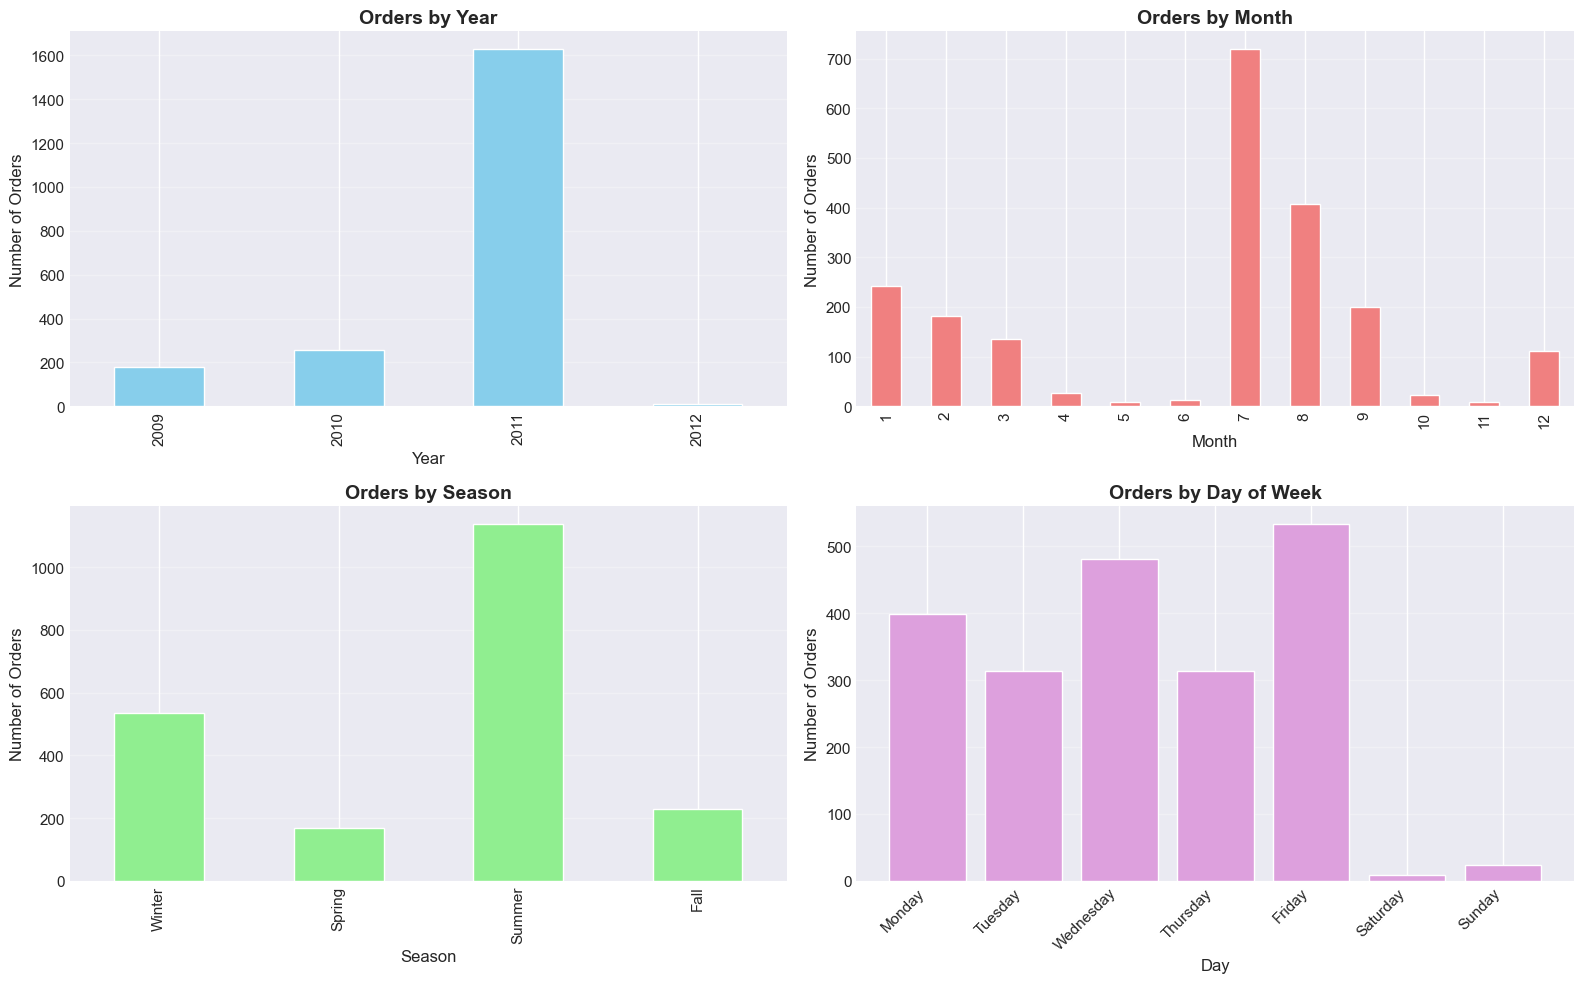

In [330]:
# Temporal Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Orders by Year
df_processed['Order_Year'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Orders by Year', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].grid(axis='y', alpha=0.3)

# Orders by Month
df_processed['Order_Month'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Orders by Month', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Orders')
axes[0, 1].grid(axis='y', alpha=0.3)

# Orders by Season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
df_processed['Order_Season'].value_counts()[season_order].plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Orders by Season', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Season')
axes[1, 0].set_ylabel('Number of Orders')
axes[1, 0].grid(axis='y', alpha=0.3)

# Orders by Day of Week
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_processed['Order_DayOfWeek'].value_counts().sort_index()
axes[1, 1].bar(range(7), day_counts.values, color='plum')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(days, rotation=45, ha='right')
axes[1, 1].set_title('Orders by Day of Week', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Number of Orders')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

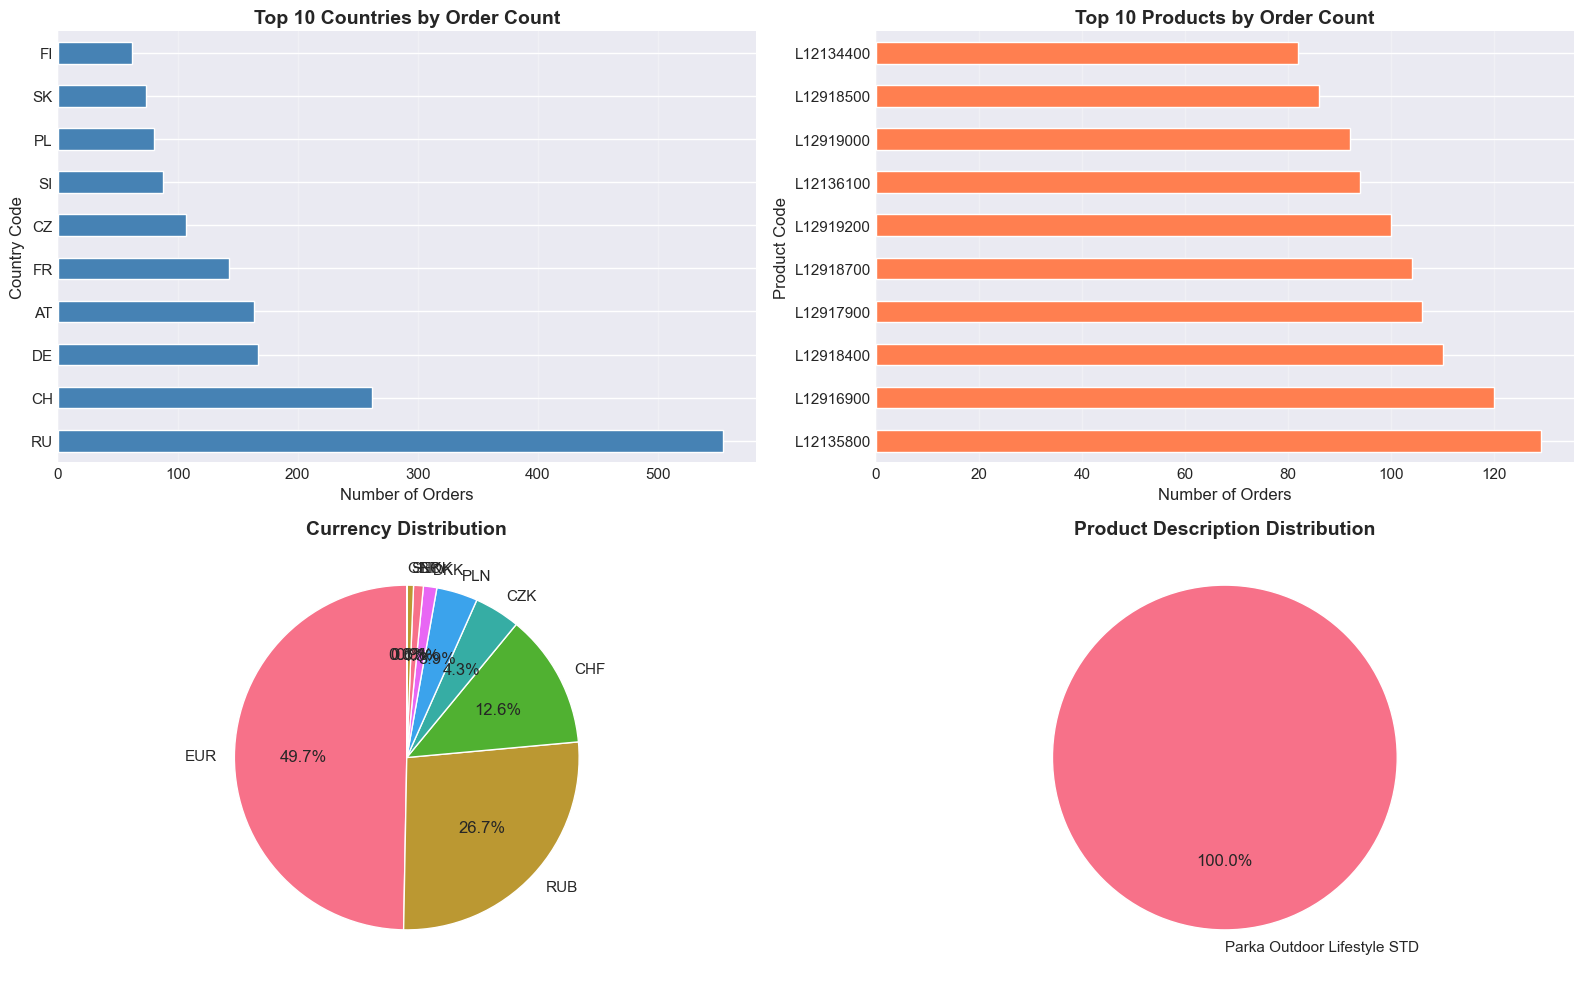

In [331]:
# Geographic and Product Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top 10 Countries by Order Count
top_countries = df_processed['Customer Country Code'].value_counts().head(10)
top_countries.plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Top 10 Countries by Order Count', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Orders')
axes[0, 0].set_ylabel('Country Code')
axes[0, 0].grid(axis='x', alpha=0.3)

# Top 10 Products
top_products = df_processed['Product Code'].value_counts().head(10)
top_products.plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Top 10 Products by Order Count', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Orders')
axes[0, 1].set_ylabel('Product Code')
axes[0, 1].grid(axis='x', alpha=0.3)

# Currency Distribution
df_processed['Currency'].value_counts().plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Currency Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('')

# Product Description Distribution
desc_counts = df_processed['Description'].value_counts()
axes[1, 1].pie(desc_counts.values, labels=desc_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Product Description Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

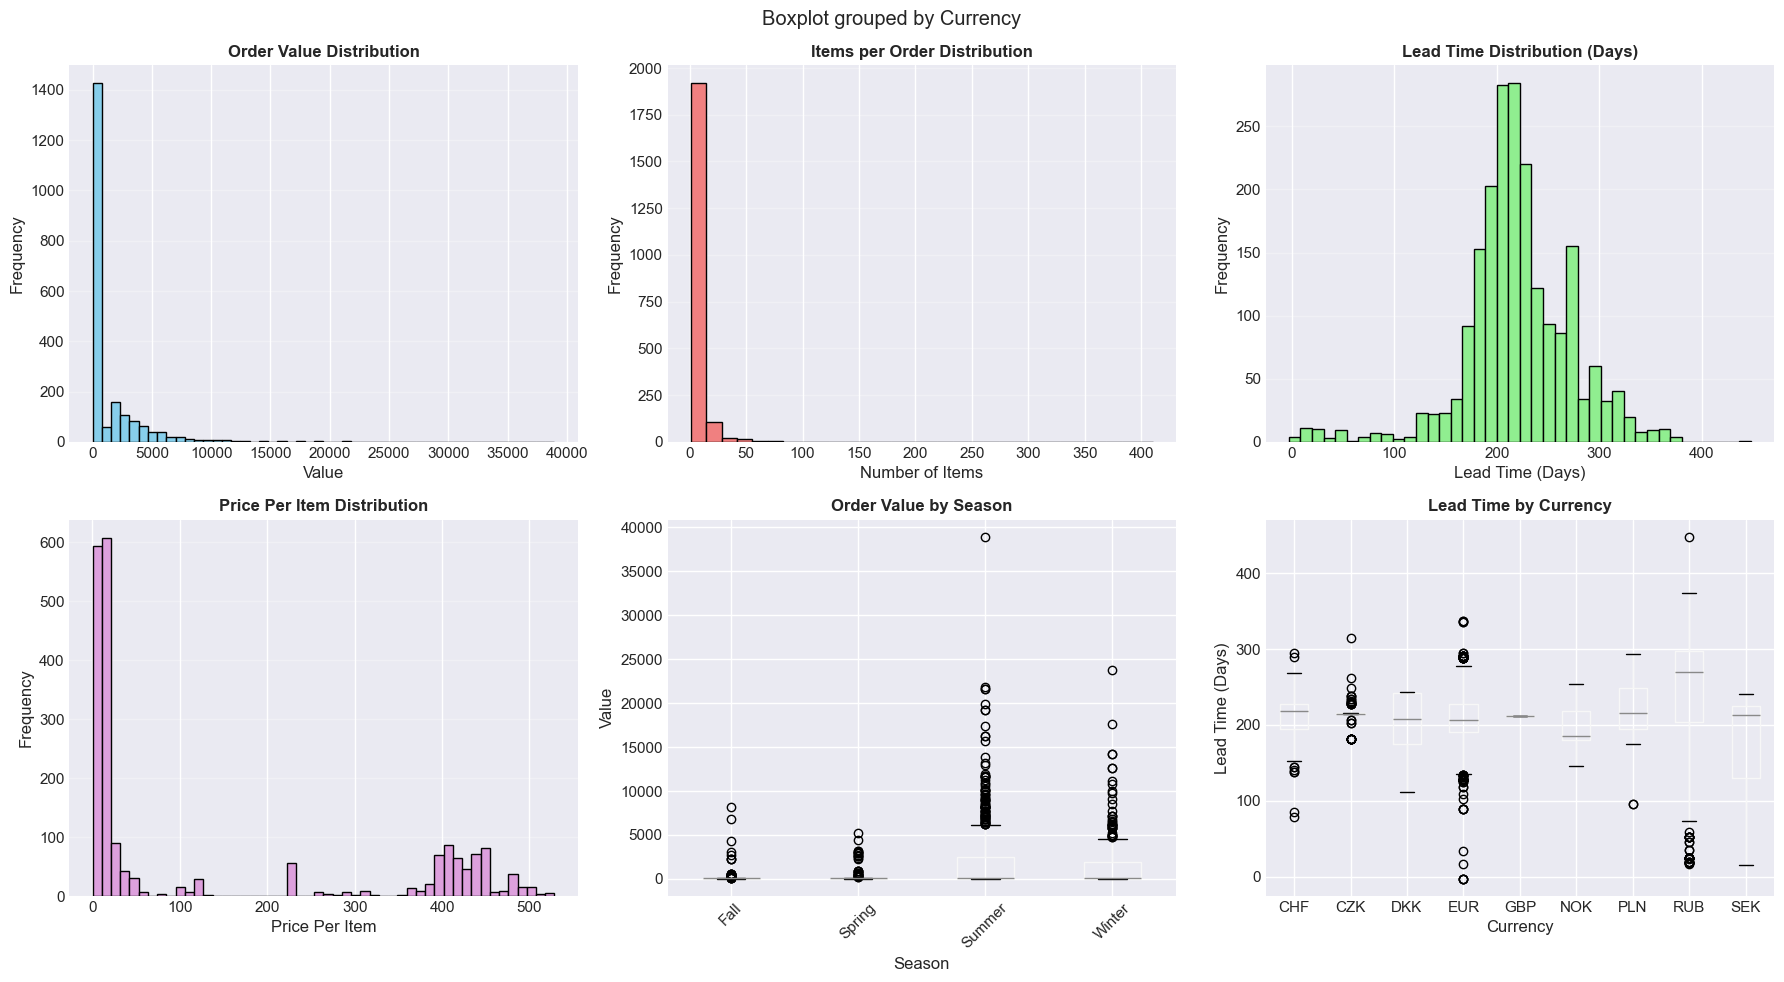


Summary Statistics for Key Variables:
              Value      Items  Lead_Time_Days  Price_Per_Item
count   2072.000000     2072.0     2072.000000          2072.0
mean    1357.375898   8.294884      220.269305      138.273219
std     2719.297649  19.645885       52.464560      184.586966
min        0.230000        1.0       -3.000000           0.115
25%       52.800000        4.0      195.000000       10.242964
50%       83.395000        6.0      217.000000           14.28
75%     2027.530000        8.0      251.000000      389.371167
max    38937.500000      410.0      448.000000          528.65


In [332]:
# Numerical Variables Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Value Distribution
axes[0, 0].hist(df_processed['Value'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Order Value Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

# Items Distribution
axes[0, 1].hist(df_processed['Items'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Items per Order Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Items')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(axis='y', alpha=0.3)

# Lead Time Distribution
axes[0, 2].hist(df_processed['Lead_Time_Days'], bins=40, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Lead Time Distribution (Days)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Lead Time (Days)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(axis='y', alpha=0.3)

# Price Per Item Distribution
axes[1, 0].hist(df_processed['Price_Per_Item'], bins=50, color='plum', edgecolor='black')
axes[1, 0].set_title('Price Per Item Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Price Per Item')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot for Value by Season
df_processed.boxplot(column='Value', by='Order_Season', ax=axes[1, 1])
axes[1, 1].set_title('Order Value by Season', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Value')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

# Box plot for Lead Time by Currency
df_processed.boxplot(column='Lead_Time_Days', by='Currency', ax=axes[1, 2])
axes[1, 2].set_title('Lead Time by Currency', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Currency')
axes[1, 2].set_ylabel('Lead Time (Days)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics for Key Variables:")
print("="*60)
print(df_processed[['Value', 'Items', 'Lead_Time_Days', 'Price_Per_Item']].describe())

In [333]:
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2009-07-08 00:00:00'), Timestamp('2012-11-19 00:00:00'))

In [334]:
sorted(df['Order Date'].dt.to_period('M').unique())

[Period('2009-07', 'M'),
 Period('2009-08', 'M'),
 Period('2009-09', 'M'),
 Period('2009-10', 'M'),
 Period('2009-11', 'M'),
 Period('2009-12', 'M'),
 Period('2010-01', 'M'),
 Period('2010-02', 'M'),
 Period('2010-03', 'M'),
 Period('2010-04', 'M'),
 Period('2010-05', 'M'),
 Period('2010-06', 'M'),
 Period('2010-12', 'M'),
 Period('2011-01', 'M'),
 Period('2011-02', 'M'),
 Period('2011-03', 'M'),
 Period('2011-04', 'M'),
 Period('2011-05', 'M'),
 Period('2011-06', 'M'),
 Period('2011-07', 'M'),
 Period('2011-08', 'M'),
 Period('2011-09', 'M'),
 Period('2011-10', 'M'),
 Period('2011-11', 'M'),
 Period('2012-01', 'M'),
 Period('2012-04', 'M'),
 Period('2012-11', 'M')]


--- NUMERICAL SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Customer Order Code,2072.0,3200666526.448359,105354.653978,3200435283.0,3200613594.25,3200710711.0,3200729692.5,3201061588.0
Value,2072.0,1357.375898,2719.297649,0.23,52.8,83.395,2027.53,38937.5
Items,2072.0,8.294884,19.645885,1.0,4.0,6.0,8.0,410.0
Lead_Time_Days,2072.0,220.269305,52.46456,-3.0,195.0,217.0,251.0,448.0
Order_Year,2072.0,2010.708977,0.623658,2009.0,2011.0,2011.0,2011.0,2012.0
Order_Month,2072.0,6.251448,3.016452,1.0,3.0,7.0,8.0,12.0
Order_Quarter,2072.0,2.505792,0.962335,1.0,1.0,3.0,3.0,4.0
Order_DayOfWeek,2072.0,2.188224,1.512956,0.0,1.0,2.0,4.0,6.0
Order_DayOfYear,2072.0,173.215734,93.88659,5.0,69.0,196.0,229.0,364.0
Order_WeekOfYear,2072.0,25.048745,13.508337,1.0,10.0,29.0,33.0,53.0



--- TOP CATEGORIES ---

Customer Country Code - Unique: 30


Customer Country Code
RU    554
CH    262
DE    167
AT    164
FR    143
Name: count, dtype: int64


Product Code - Unique: 40


...

Prev_Product
L12135800    128
L12916900    119
L12918400    110
L12917900    104
L12918700    102
Name: count, dtype: int64


Customer_Season - Unique: 82


Customer_Season
RU_Summer    403
RU_Winter    138
DE_Summer    129
AT_Winter    124
CH_Winter    114
Name: count, dtype: int64


Route_Season - Unique: 83


Route_Season
RU0001_Summer    403
RU0001_Winter    138
FR01DE_Summer    129
AT0003_Winter    124
1_Summer         118
Name: count, dtype: int64

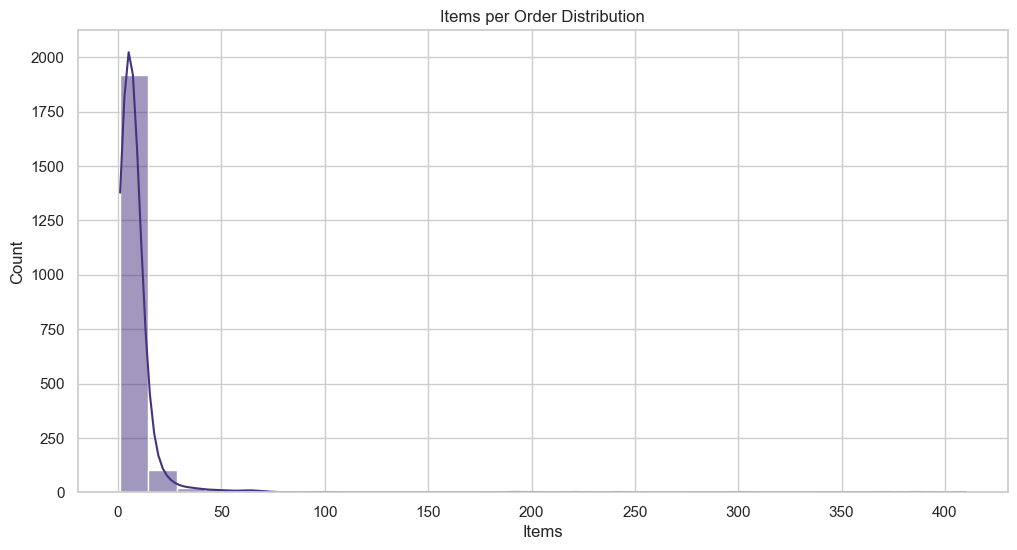

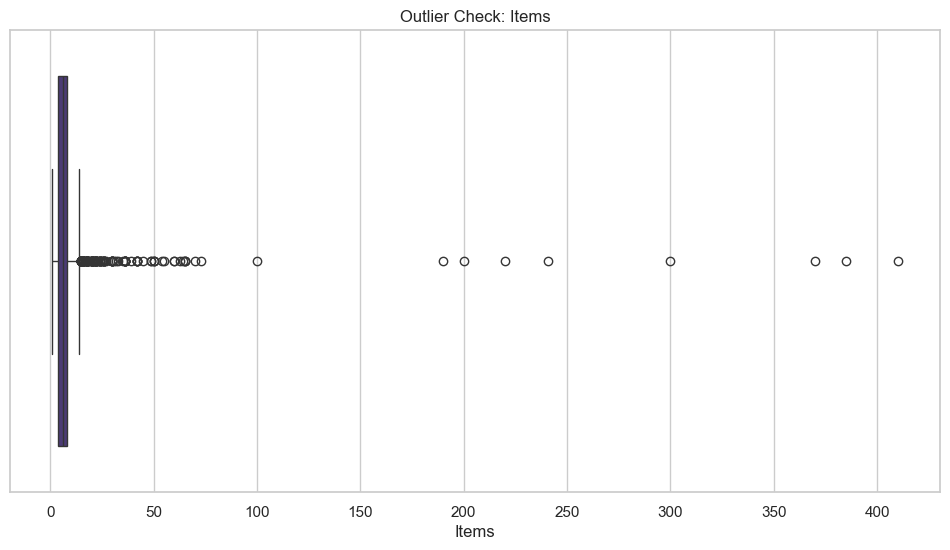

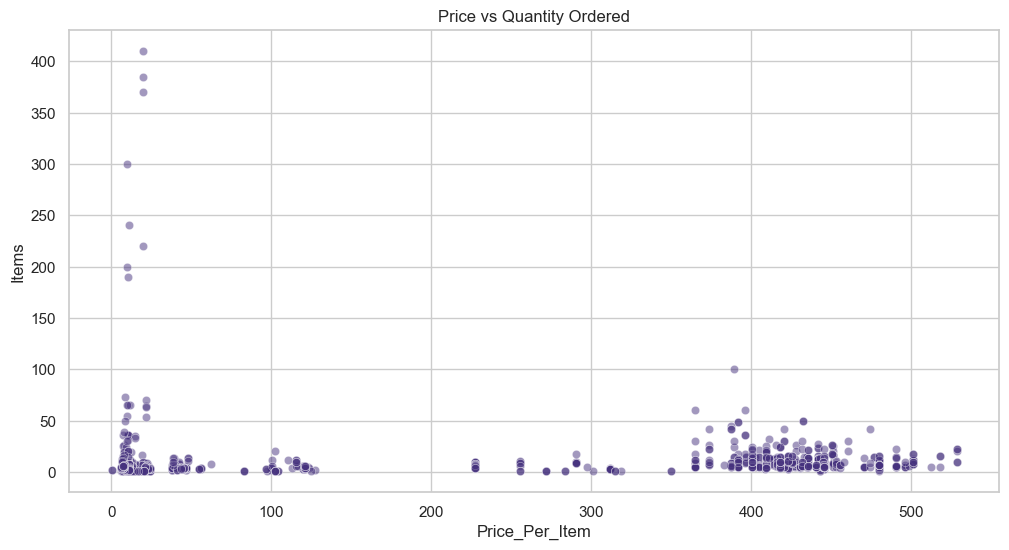

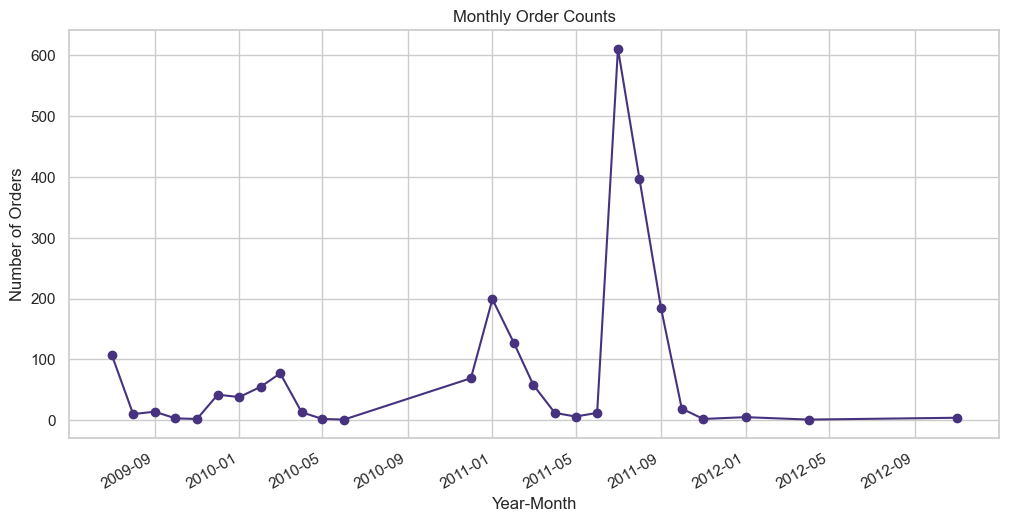

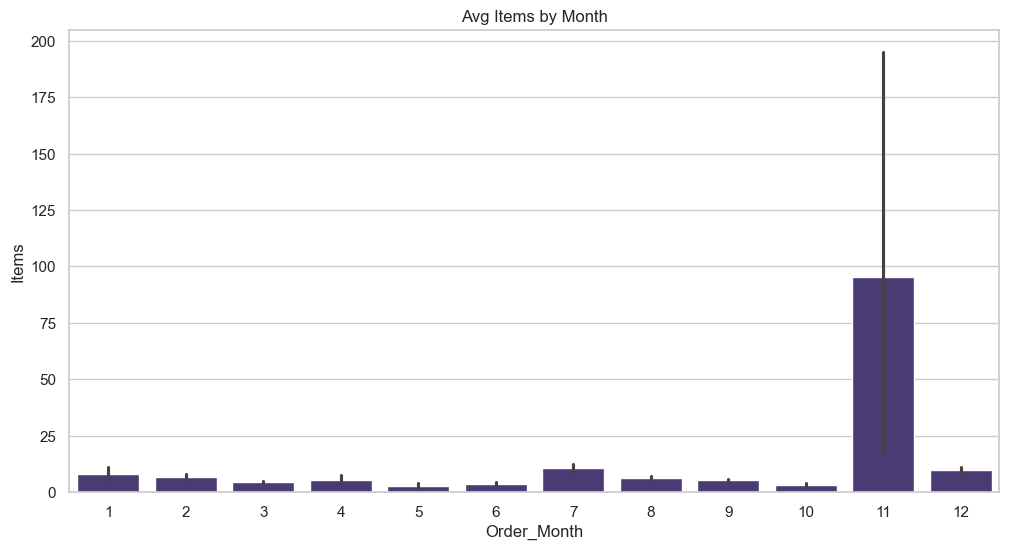

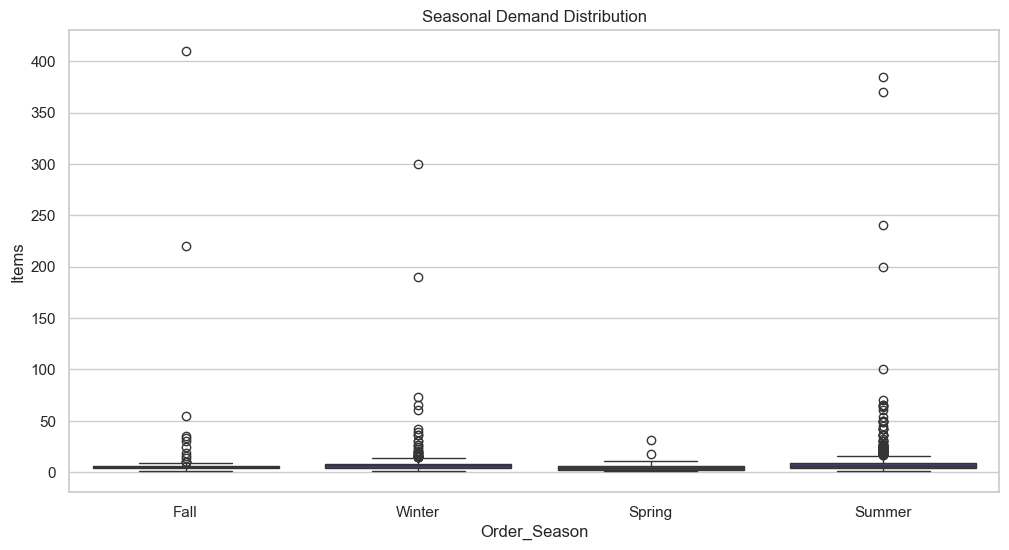

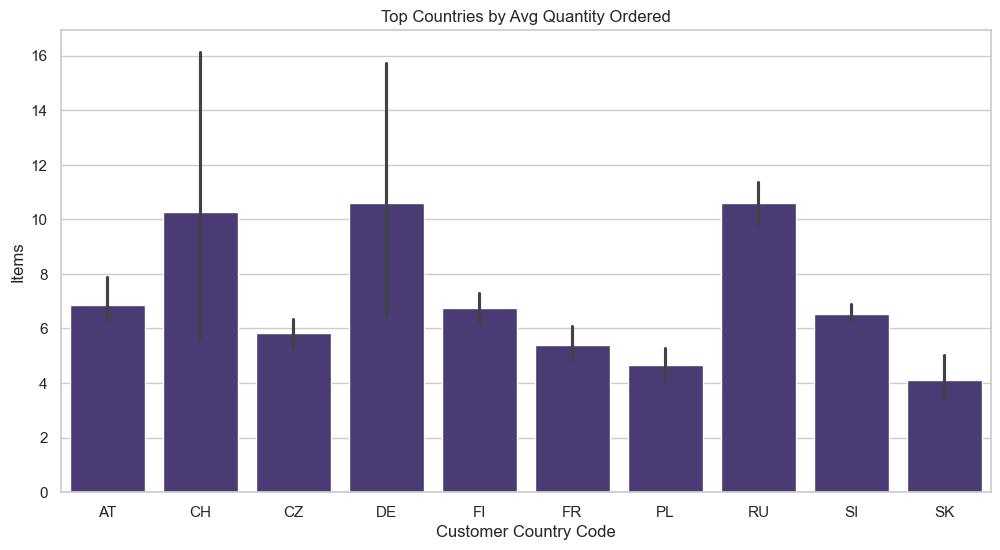

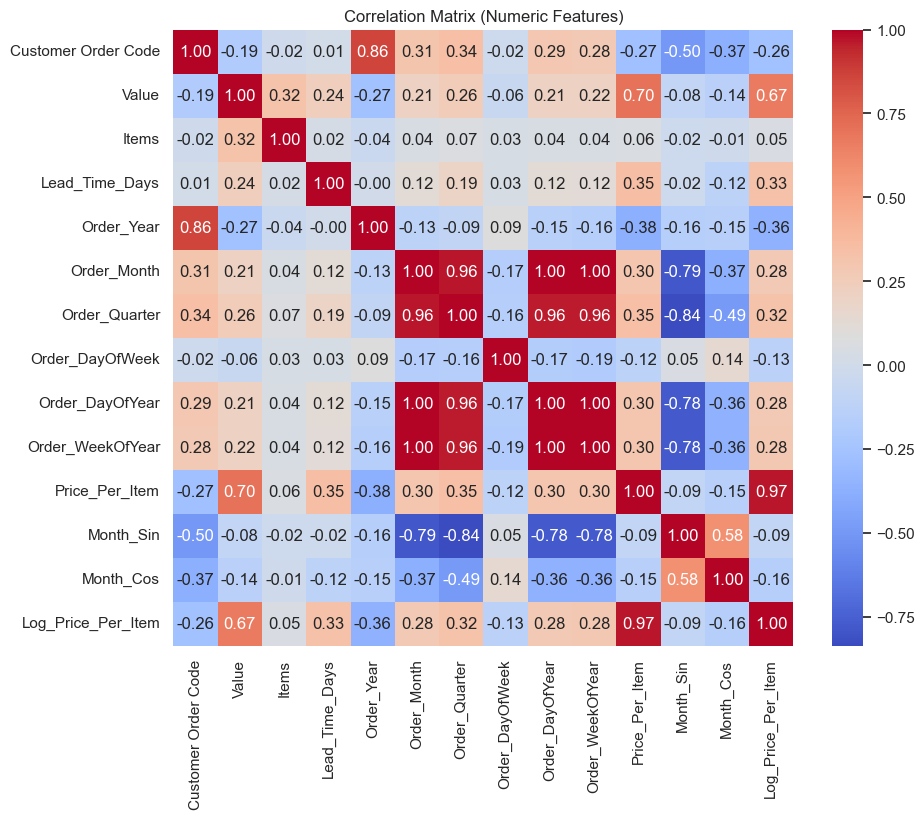

In [335]:
sns.set(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

# NUMERICAL STATS
num_cols = df_processed.select_dtypes(include=np.number).columns
print("\n--- NUMERICAL SUMMARY ---")
display(df_processed[num_cols].describe().T)

# CATEGORICAL DISTRIBUTIONS
cat_cols = df_processed.select_dtypes(include="object").columns
print("\n--- TOP CATEGORIES ---")
for col in cat_cols:
    print(f"\n{col} - Unique: {df_processed[col].nunique()}")
    display(df_processed[col].value_counts().head(5))

# ITEMS DISTRIBUTION
plt.figure()
sns.histplot(df_processed['Items'], bins=30, kde=True)
plt.title("Items per Order Distribution")
plt.show()

plt.figure()
sns.boxplot(x=df_processed['Items'])
plt.title("Outlier Check: Items")
plt.show()

# PRICE PER ITEM VS ITEMS
plt.figure()
sns.scatterplot(data=df_processed, x="Price_Per_Item", y="Items", alpha=0.5)
plt.title("Price vs Quantity Ordered")
plt.show()

# TIME SERIES ANALYSIS
orders_monthly = df_processed.groupby(['Order_Year', 'Order_Month']).size()
orders_monthly.index = pd.to_datetime(orders_monthly.index.map(lambda x: f'{x[0]}-{x[1]}-01'))
orders_monthly = orders_monthly.sort_index()

plt.figure()
orders_monthly.plot(marker="o")
plt.title("Monthly Order Counts")
plt.ylabel("Number of Orders")
plt.xlabel("Year-Month")
plt.show()

# SEASONALITY ANALYSIS
plt.figure()
sns.barplot(data=df_processed, x="Order_Month", y="Items", estimator="mean")
plt.title("Avg Items by Month")
plt.show()

plt.figure()
sns.boxplot(data=df_processed, x="Order_Season", y="Items")
plt.title("Seasonal Demand Distribution")
plt.show()

#COUNTRY DEMAND
top_countries = df_processed['Customer Country Code'].value_counts().head(10).index
plt.figure()
sns.barplot(data=df_processed[df_processed['Customer Country Code'].isin(top_countries)],
            x="Customer Country Code", y="Items")
plt.title("Top Countries by Avg Quantity Ordered")
plt.show()

#CORRELATION HEATMAP
plt.figure(figsize=(10,8))
sns.heatmap(df_processed[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


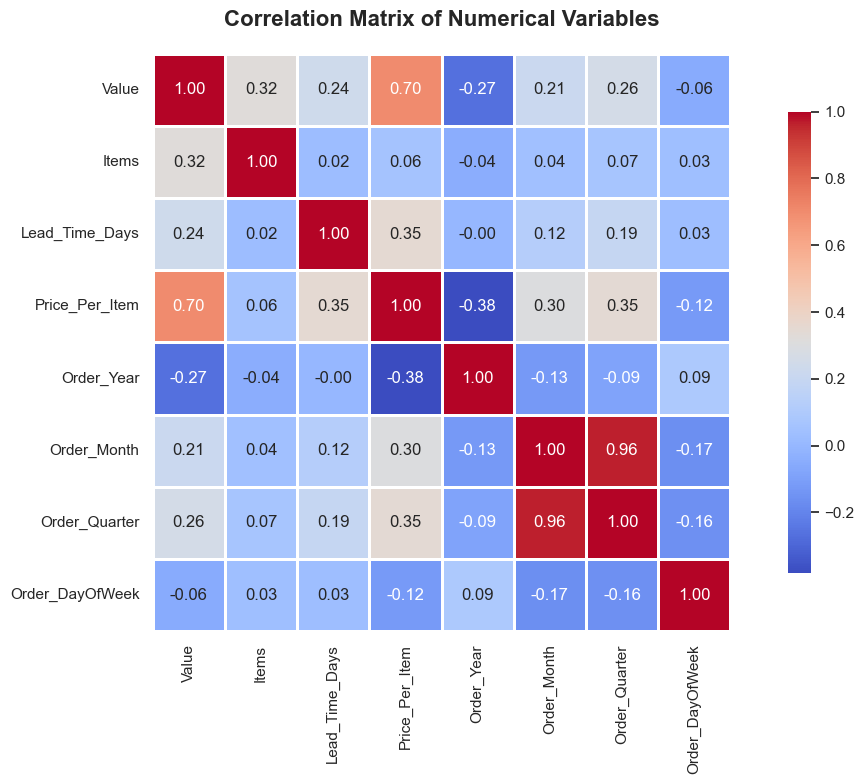


Key Correlations with Order Value:
Value              1.000000
Price_Per_Item     0.699507
Items              0.323219
Order_Quarter      0.259352
Lead_Time_Days     0.235494
Order_Month        0.214918
Order_DayOfWeek   -0.056632
Order_Year        -0.268311
Name: Value, dtype: float64


In [336]:
# Correlation Analysis
# Select numerical columns for correlation
numerical_cols = ['Value', 'Items', 'Lead_Time_Days', 'Price_Per_Item', 
                  'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_DayOfWeek']

correlation_matrix = df_processed[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey Correlations with Order Value:")
print("="*60)
value_corr = correlation_matrix['Value'].sort_values(ascending=False)
print(value_corr)

DISTRIBUTION ANALYSIS

Value:
  Skewness: 4.2286
  Kurtosis: 30.7822
  Shapiro-Wilk test p-value: 0.000000
  Distribution: Not Normal

Items:
  Skewness: 14.6051
  Kurtosis: 250.9680
  Shapiro-Wilk test p-value: 0.000000
  Distribution: Not Normal

Lead_Time_Days:
  Skewness: -0.5385
  Kurtosis: 2.8628
  Shapiro-Wilk test p-value: 0.000000
  Distribution: Not Normal

Price_Per_Item:
  Skewness: 0.9144
  Kurtosis: -1.0270
  Shapiro-Wilk test p-value: 0.000000
  Distribution: Not Normal


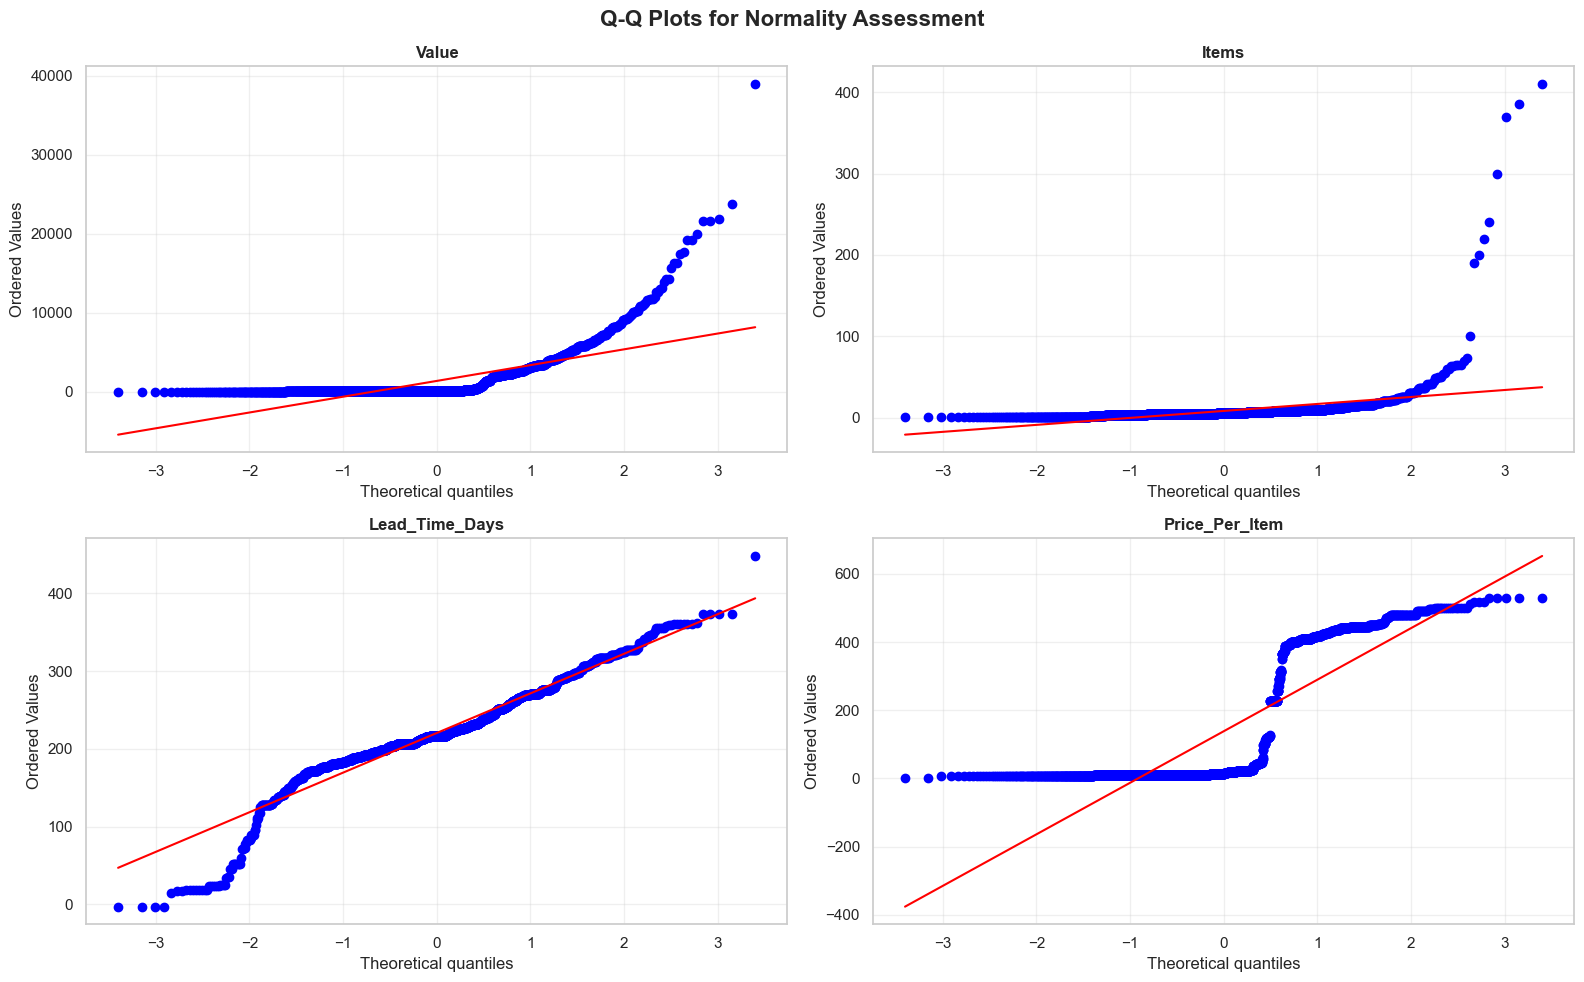

In [337]:
# 2. DISTRIBUTION ANALYSIS - Normality Tests and Skewness
print("="*80)
print("DISTRIBUTION ANALYSIS")
print("="*80)

from scipy import stats

# Test for normality and check skewness/kurtosis
for col in ['Value', 'Items', 'Lead_Time_Days', 'Price_Per_Item']:
    print(f"\n{col}:")
    print(f"  Skewness: {df_processed[col].skew():.4f}")
    print(f"  Kurtosis: {df_processed[col].kurtosis():.4f}")
    
    # Shapiro-Wilk test (sample for large datasets)
    sample = df_processed[col].dropna().sample(min(5000, len(df_processed[col])))
    stat, p_value = stats.shapiro(sample)
    print(f"  Shapiro-Wilk test p-value: {p_value:.6f}")
    print(f"  Distribution: {'Normal' if p_value > 0.05 else 'Not Normal'}")

# Visualize distributions with Q-Q plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Q-Q Plots for Normality Assessment', fontsize=16, fontweight='bold')

for idx, col in enumerate(['Value', 'Items', 'Lead_Time_Days', 'Price_Per_Item']):
    ax = axes[idx//2, idx%2]
    stats.probplot(df_processed[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


MULTIVARIATE ANALYSIS


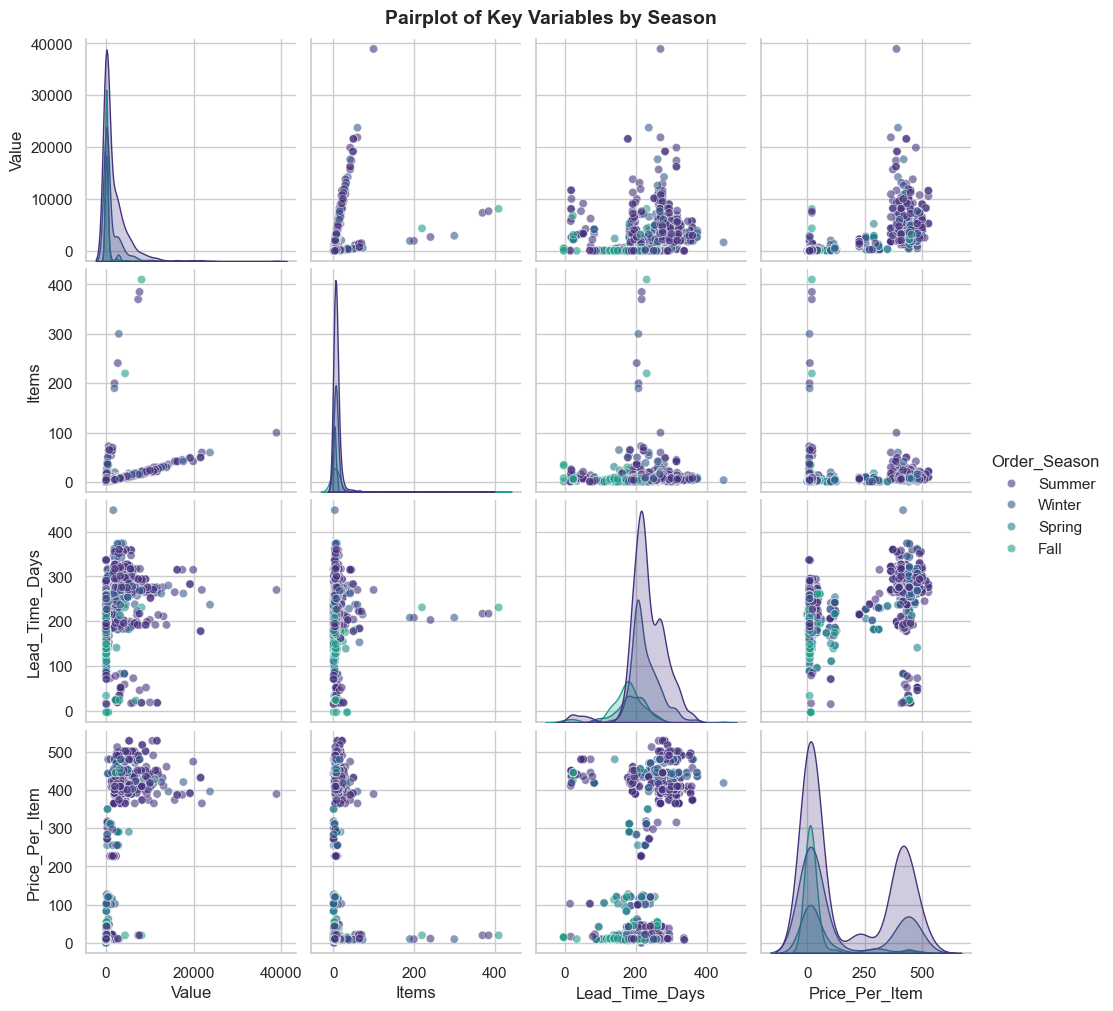

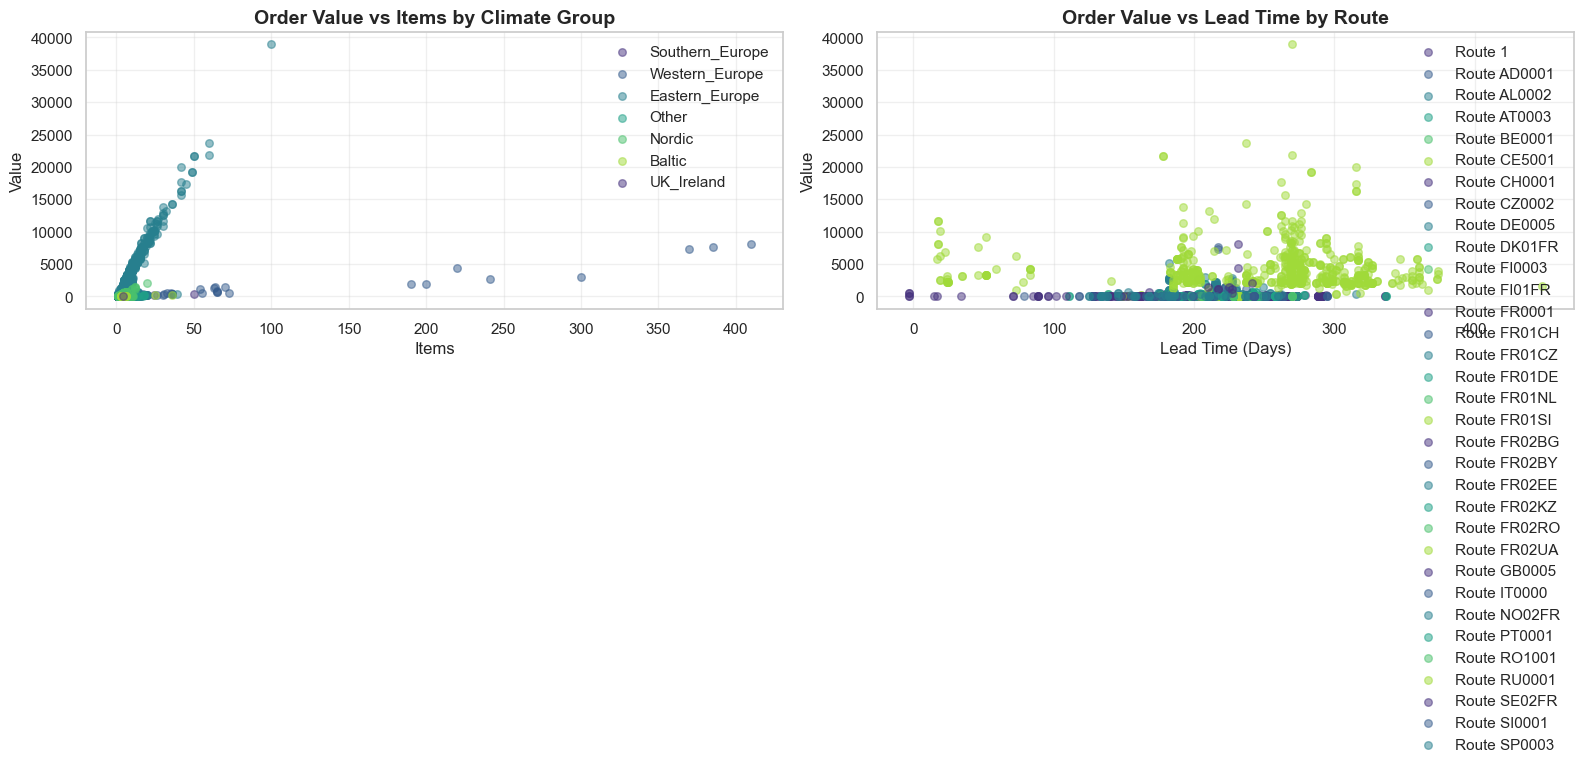

In [338]:
# 3. MULTIVARIATE ANALYSIS - Relationships between Variables
print("="*80)
print("MULTIVARIATE ANALYSIS")
print("="*80)

# Pairplot for key variables (sample for performance)
sample_size = min(2000, len(df_processed))
sample_df = df_processed.sample(n=sample_size, random_state=42)

# Create pairplot with hue by Season
fig = sns.pairplot(sample_df[['Value', 'Items', 'Lead_Time_Days', 'Price_Per_Item', 'Order_Season']], 
                   hue='Order_Season', diag_kind='kde', plot_kws={'alpha': 0.6}, height=2.5)
fig.fig.suptitle('Pairplot of Key Variables by Season', y=1.01, fontsize=14, fontweight='bold')
plt.show()

# Value vs Items colored by Climate Group
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Value vs Items by Climate Group
for climate in df_processed['Climate_Group'].unique():
    data = df_processed[df_processed['Climate_Group'] == climate]
    axes[0].scatter(data['Items'], data['Value'], alpha=0.5, label=climate, s=30)
axes[0].set_xlabel('Items', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Order Value vs Items by Climate Group', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Lead Time vs Value by Route
for route in sorted(df_processed['Route'].unique()):
    data = df_processed[df_processed['Route'] == route]
    axes[1].scatter(data['Lead_Time_Days'], data['Value'], alpha=0.5, label=f'Route {route}', s=30)
axes[1].set_xlabel('Lead Time (Days)', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Order Value vs Lead Time by Route', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


TEMPORAL PATTERNS ANALYSIS


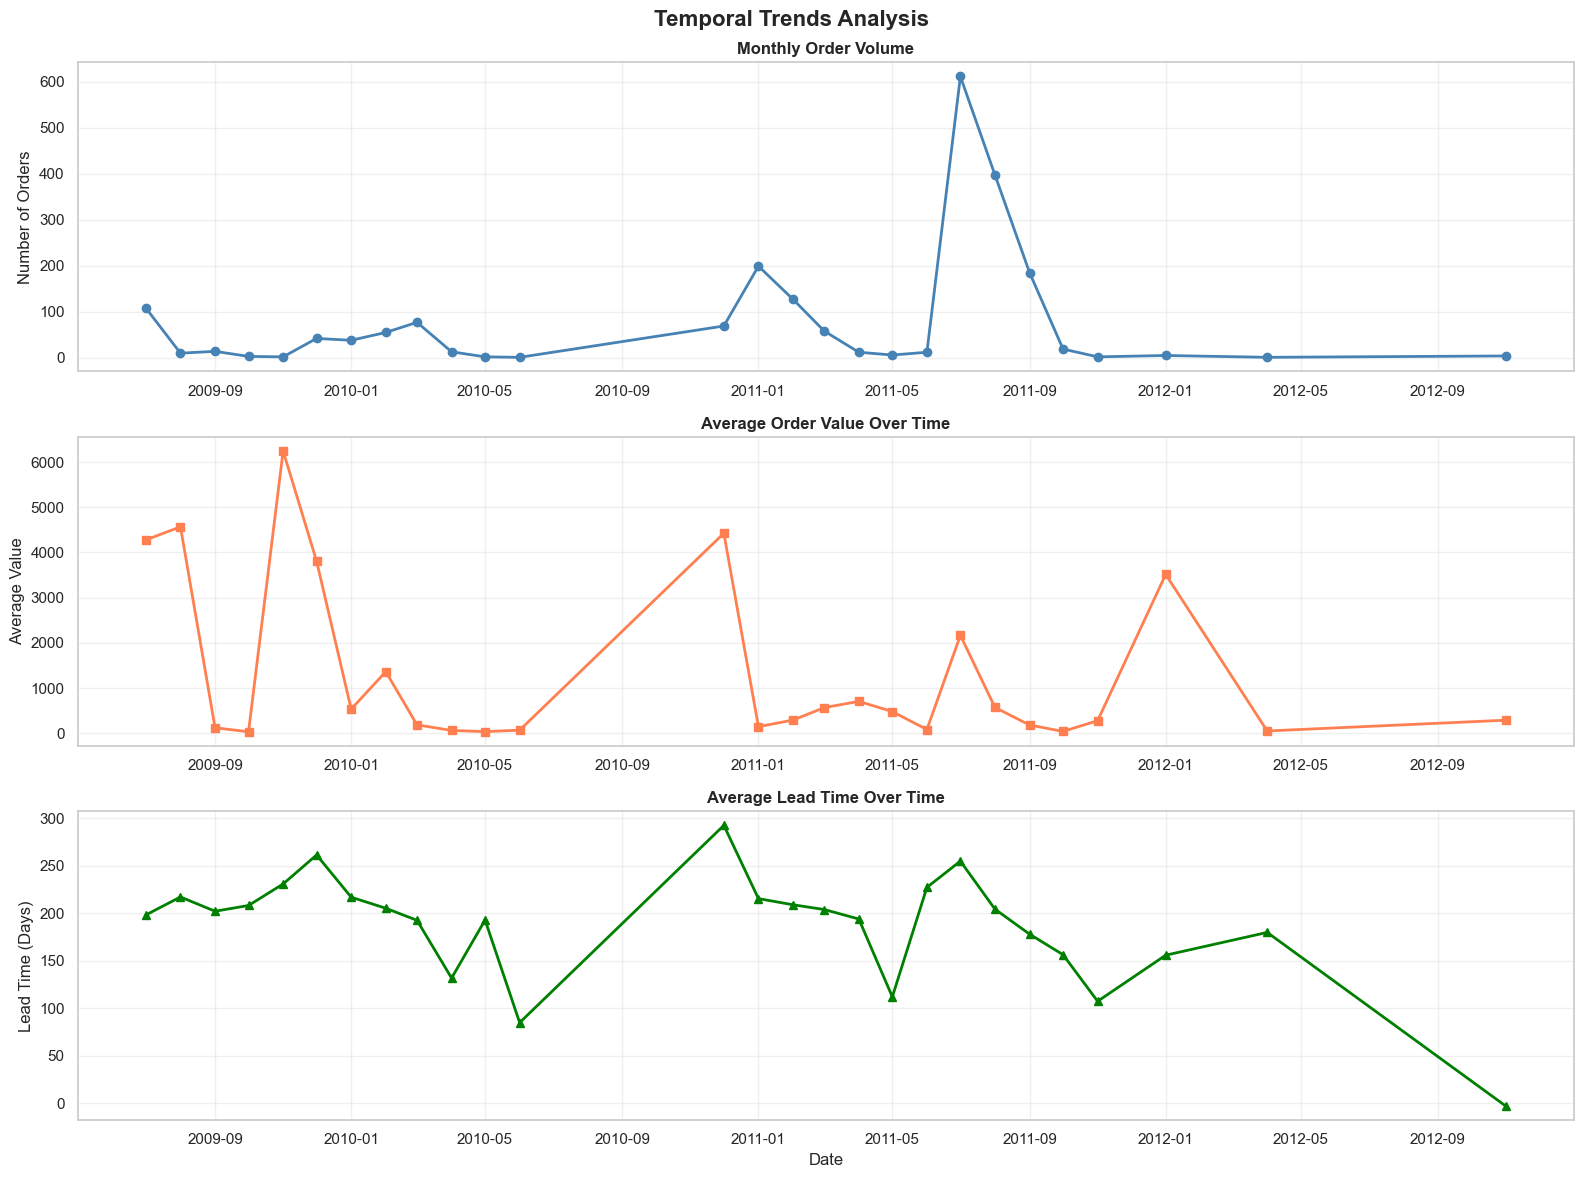


Trend Statistics:
Order Count - Min: 1, Max: 611
Average Value - Min: $32.47, Max: $6246.44
Average Lead Time - Min: -3.0 days, Max: 292.7 days


In [339]:
# 4. TEMPORAL PATTERNS - Trend and Cyclical Analysis
print("="*80)
print("TEMPORAL PATTERNS ANALYSIS")
print("="*80)

# Create time-based aggregations
df_processed['YearMonth'] = df_processed['Order Date'].dt.to_period('M')

# Monthly aggregations
monthly_stats = df_processed.groupby('YearMonth').agg({
    'Value': ['sum', 'mean', 'count'],
    'Items': ['sum', 'mean'],
    'Lead_Time_Days': 'mean'
}).reset_index()

monthly_stats.columns = ['YearMonth', 'Total_Value', 'Avg_Value', 'Order_Count', 
                         'Total_Items', 'Avg_Items', 'Avg_Lead_Time']
monthly_stats['YearMonth'] = monthly_stats['YearMonth'].dt.to_timestamp()

# Plot temporal trends
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Temporal Trends Analysis', fontsize=16, fontweight='bold')

# Total Orders over time
axes[0].plot(monthly_stats['YearMonth'], monthly_stats['Order_Count'], 
             marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0].set_title('Monthly Order Volume', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].grid(alpha=0.3)

# Average Value over time
axes[1].plot(monthly_stats['YearMonth'], monthly_stats['Avg_Value'], 
             marker='s', linewidth=2, markersize=6, color='coral')
axes[1].set_title('Average Order Value Over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Value')
axes[1].grid(alpha=0.3)

# Average Lead Time over time
axes[2].plot(monthly_stats['YearMonth'], monthly_stats['Avg_Lead_Time'], 
             marker='^', linewidth=2, markersize=6, color='green')
axes[2].set_title('Average Lead Time Over Time', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Lead Time (Days)')
axes[2].set_xlabel('Date')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print trend statistics
print("\nTrend Statistics:")
print(f"Order Count - Min: {monthly_stats['Order_Count'].min():.0f}, Max: {monthly_stats['Order_Count'].max():.0f}")
print(f"Average Value - Min: ${monthly_stats['Avg_Value'].min():.2f}, Max: ${monthly_stats['Avg_Value'].max():.2f}")
print(f"Average Lead Time - Min: {monthly_stats['Avg_Lead_Time'].min():.1f} days, Max: {monthly_stats['Avg_Lead_Time'].max():.1f} days")


CUSTOMER BEHAVIOR BY COUNTRY

Top 15 Countries - Key Metrics:
                       Avg_Value  Total_Value  Std_Value  Avg_Items  \
Customer Country Code                                                 
RU                       4528.73   2508915.07    3622.83      10.61   
CZ                       1217.56    130279.20     890.74       5.84   
CH                        199.55     52280.92     883.85      10.28   
DE                        106.88     17849.45     311.82      10.61   
PL                        200.00     15999.96     125.12       4.65   
AT                         71.47     11720.44      46.10       6.87   
FR                         59.12      8454.77      59.63       5.38   
SI                         69.39      6106.24      16.70       6.55   
HR                        118.28      5440.84      22.91      10.96   
FI                         64.74      4013.70      24.20       6.76   
NL                        149.83      3745.65     186.65      13.52   
SK             

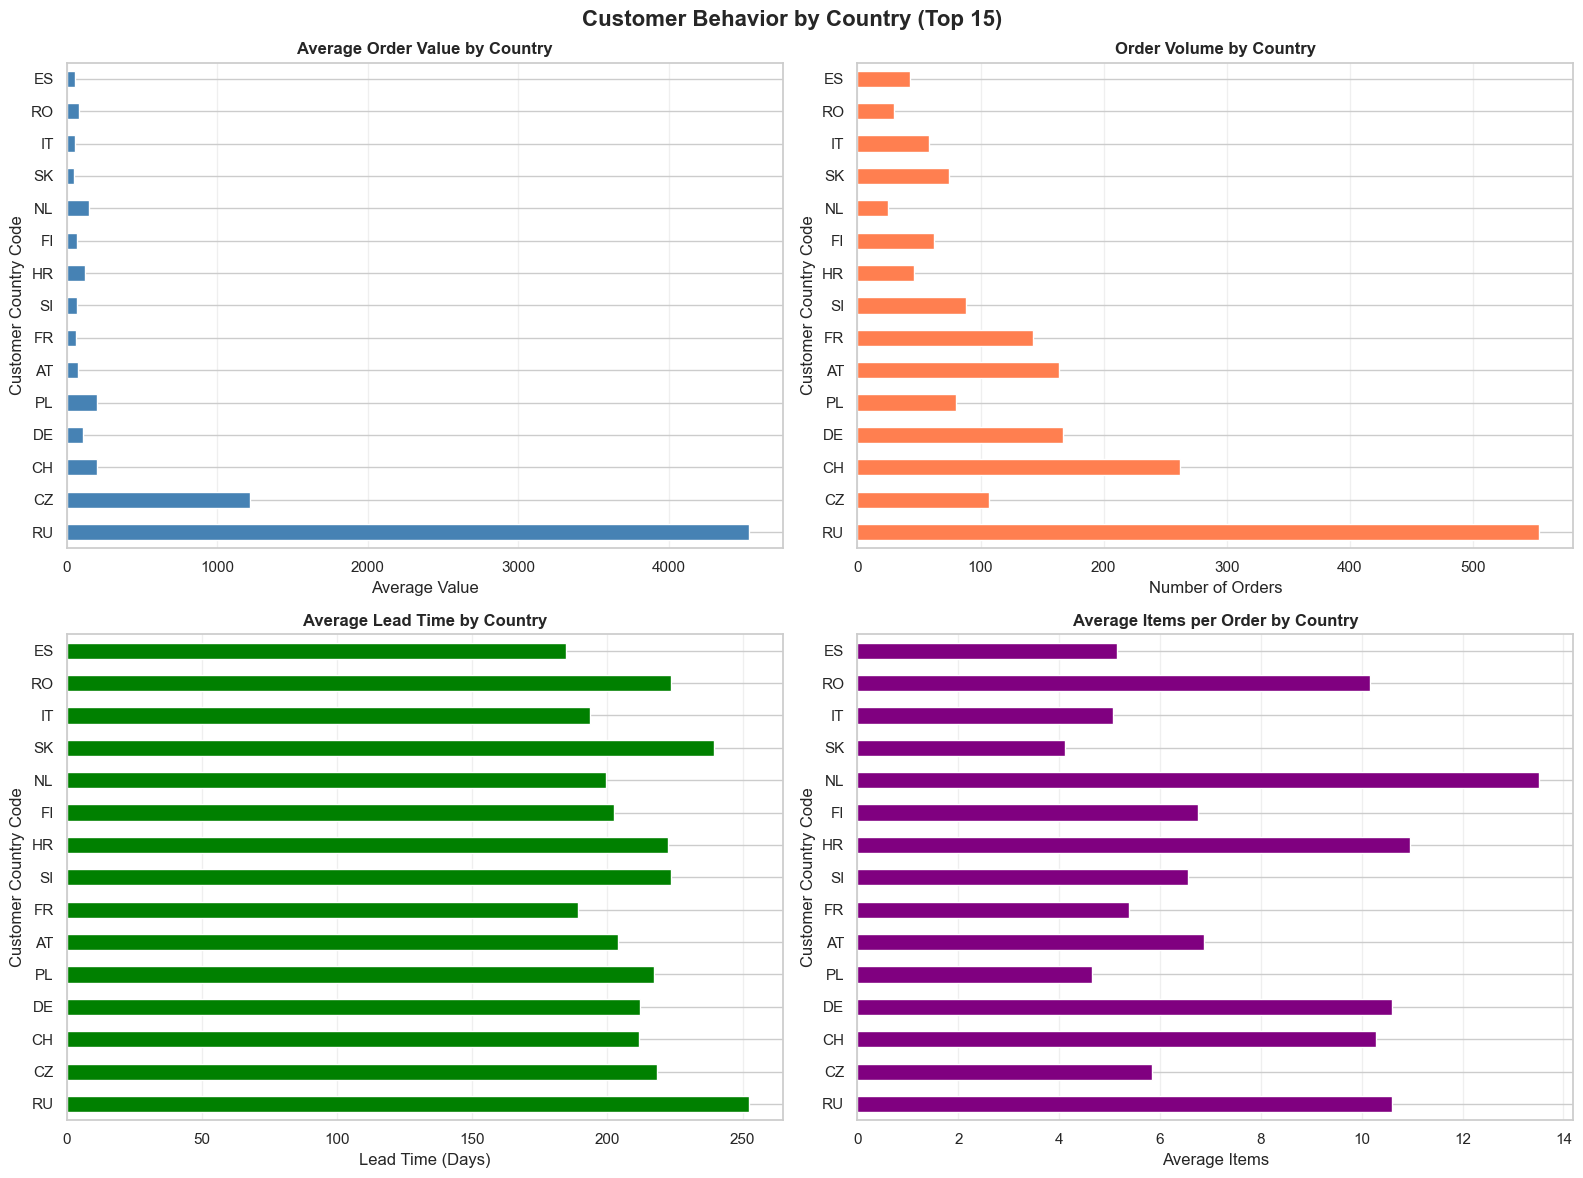

In [340]:
# 5. CUSTOMER BEHAVIOR ANALYSIS - Country Patterns
print("="*80)
print("CUSTOMER BEHAVIOR BY COUNTRY")
print("="*80)

# Analyze top 15 countries
top_15_countries = df_processed['Customer Country Code'].value_counts().head(15).index
country_stats = df_processed[df_processed['Customer Country Code'].isin(top_15_countries)].groupby('Customer Country Code').agg({
    'Value': ['mean', 'sum', 'std'],
    'Items': ['mean', 'sum', 'std'],
    'Lead_Time_Days': ['mean', 'std'],
    'Price_Per_Item': 'mean',
    'Order Date': 'count'
}).round(2)

country_stats.columns = ['Avg_Value', 'Total_Value', 'Std_Value', 
                         'Avg_Items', 'Total_Items', 'Std_Items',
                         'Avg_Lead_Time', 'Std_Lead_Time', 
                         'Avg_Price_Per_Item', 'Order_Count']

# Sort by total value
country_stats = country_stats.sort_values('Total_Value', ascending=False)

print("\nTop 15 Countries - Key Metrics:")
print(country_stats)

# Visualize country patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Behavior by Country (Top 15)', fontsize=16, fontweight='bold')

# Average Order Value by Country
country_stats['Avg_Value'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average Order Value by Country', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Average Value')
axes[0, 0].grid(axis='x', alpha=0.3)

# Total Order Volume by Country
country_stats['Order_Count'].plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Order Volume by Country', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Orders')
axes[0, 1].grid(axis='x', alpha=0.3)

# Average Lead Time by Country
country_stats['Avg_Lead_Time'].plot(kind='barh', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Average Lead Time by Country', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lead Time (Days)')
axes[1, 0].grid(axis='x', alpha=0.3)

# Average Items per Order by Country
country_stats['Avg_Items'].plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Average Items per Order by Country', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Items')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


PRODUCT ANALYSIS

Top 20 Products - Key Metrics:
              Avg_Value  Total_Value  Std_Value  Avg_Items  Total_Items  \
Product Code                                                              
L12918400       2677.32    294505.42    5250.30       9.87         1086   
L12134400       2883.01    236406.77    3706.32       9.65          791   
L12918700       1850.78    192481.39    2473.90       7.78          809   
L12918500       2229.43    191730.64    2883.53       8.16          702   
L12918600       2788.88    170121.82    3762.94        8.7          531   
L12917800       2563.69    153821.40    3982.96      11.42          685   
L12917900       1177.89    124856.47    2276.98       9.78         1037   
L10850600       1532.66     99622.78    3496.01       8.35          543   
L12134600       1755.20     91270.55    2347.06      12.56          653   
L12919200        833.13     83312.96    1708.35      10.84         1084   
L12919000        797.07     73330.19    1302.89    

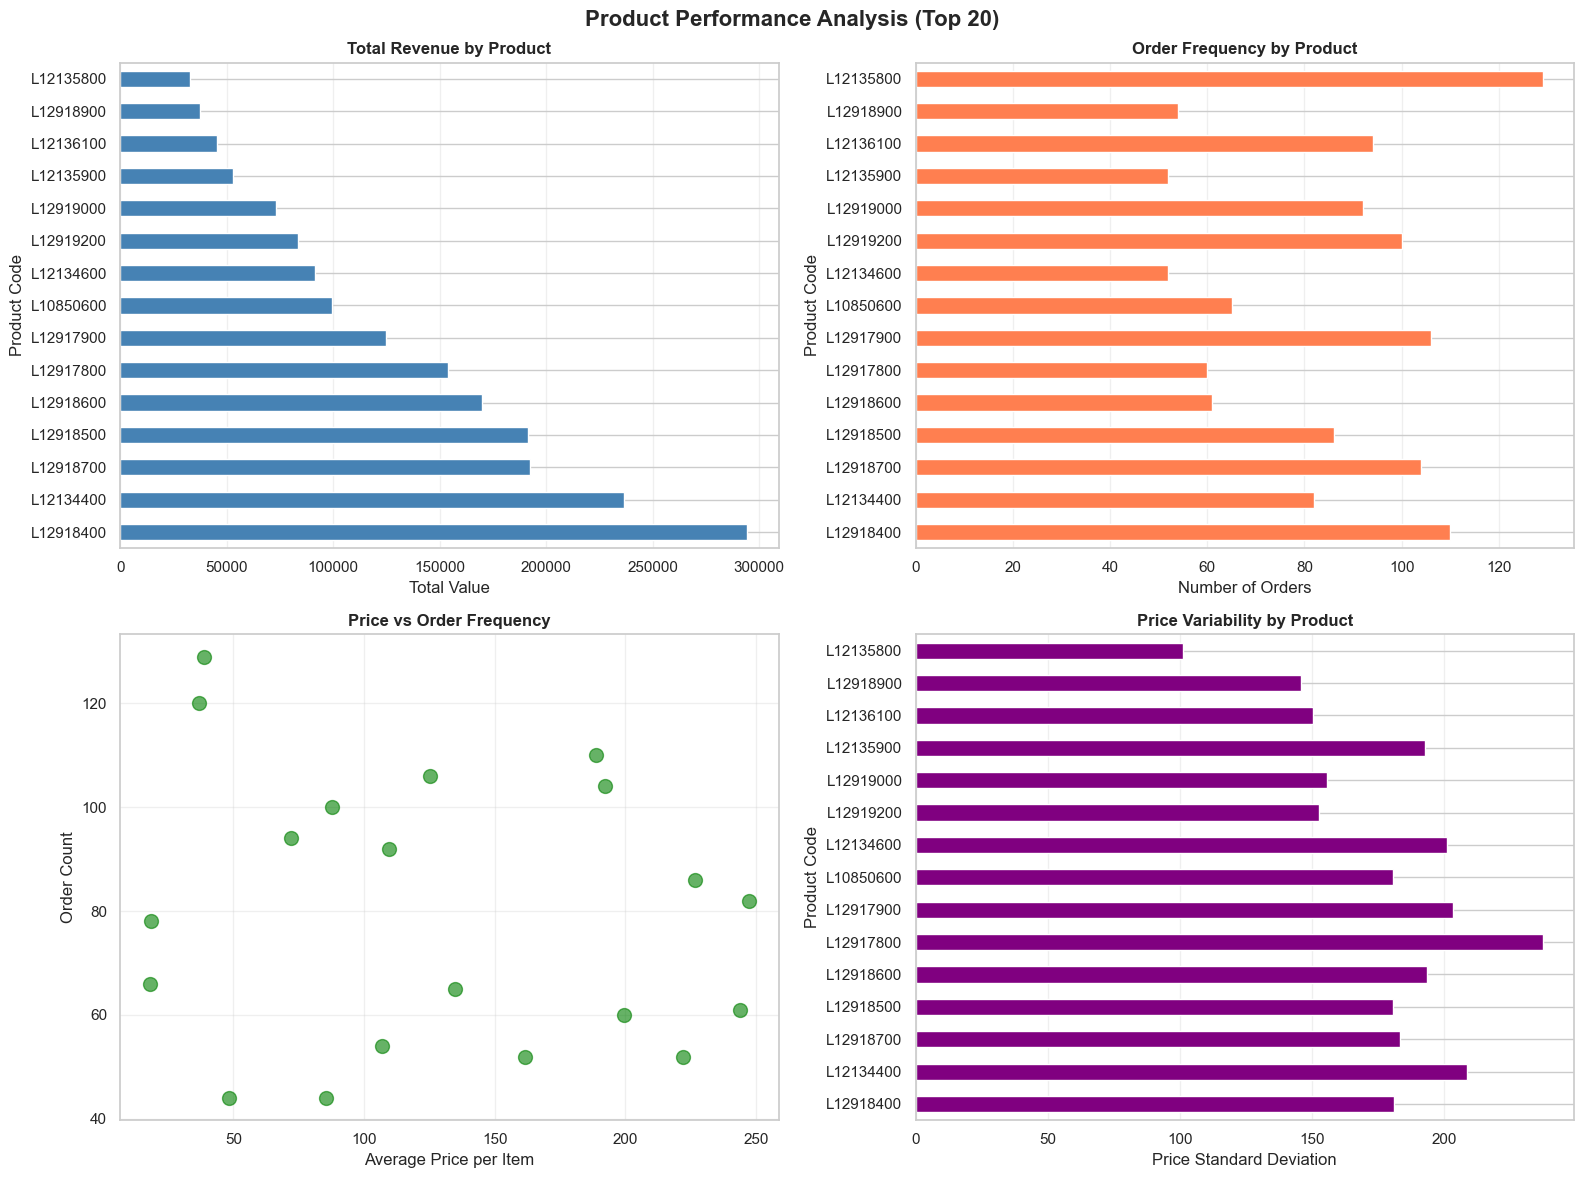

In [341]:
# 6. PRODUCT ANALYSIS - Product Performance and Patterns
print("="*80)
print("PRODUCT ANALYSIS")
print("="*80)

# Analyze top 20 products
top_20_products = df_processed['Product Code'].value_counts().head(20).index
product_stats = df_processed[df_processed['Product Code'].isin(top_20_products)].groupby('Product Code').agg({
    'Value': ['mean', 'sum', 'std'],
    'Items': ['mean', 'sum'],
    'Lead_Time_Days': 'mean',
    'Price_Per_Item': ['mean', 'std'],
    'Order Date': 'count'
}).round(2)

product_stats.columns = ['Avg_Value', 'Total_Value', 'Std_Value', 
                         'Avg_Items', 'Total_Items',
                         'Avg_Lead_Time', 
                         'Avg_Price', 'Std_Price',
                         'Order_Count']

product_stats = product_stats.sort_values('Total_Value', ascending=False)

print("\nTop 20 Products - Key Metrics:")
print(product_stats.head(20))

# Product concentration analysis
print("\n\nProduct Concentration:")
total_orders = len(df_processed)
top_10_pct = df_processed['Product Code'].value_counts().head(10).sum() / total_orders * 100
top_20_pct = df_processed['Product Code'].value_counts().head(20).sum() / total_orders * 100
print(f"Top 10 products account for: {top_10_pct:.2f}% of all orders")
print(f"Top 20 products account for: {top_20_pct:.2f}% of all orders")

# Visualize product patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Product Performance Analysis (Top 20)', fontsize=16, fontweight='bold')

# Top 15 Products by Total Value
product_stats.head(15)['Total_Value'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Total Revenue by Product', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Total Value')
axes[0, 0].grid(axis='x', alpha=0.3)

# Top 15 Products by Order Count
product_stats.head(15)['Order_Count'].plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Order Frequency by Product', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Orders')
axes[0, 1].grid(axis='x', alpha=0.3)

# Average Price vs Order Volume
axes[1, 0].scatter(product_stats['Avg_Price'], product_stats['Order_Count'], 
                   s=100, alpha=0.6, color='green')
axes[1, 0].set_title('Price vs Order Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Average Price per Item')
axes[1, 0].set_ylabel('Order Count')
axes[1, 0].grid(alpha=0.3)

# Price Variability (Std) by Product
product_stats.head(15)['Std_Price'].plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Price Variability by Product', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price Standard Deviation')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


CLIMATE GROUP ANALYSIS

Climate Group Statistics:
                 Avg_Value  Total_Value  Std_Value  Avg_Items  Total_Items  \
Climate_Group                                                                
Eastern_Europe     3049.58   2662285.80    3510.99       8.76         7648   
Western_Europe      122.56     94369.96     540.20       8.75         6734   
Nordic              304.05     34661.93     367.44       6.06          691   
Southern_Europe      68.43     18819.41      39.87       6.57         1806   
Other                64.33      1350.96      47.89       8.38          176   
Baltic               52.74       949.40      66.14       7.11          128   
UK_Ireland           45.40        45.40        NaN        4.0            4   

                 Std_Items  Avg_Lead_Time  Std_Lead_Time  Avg_Price_Per_Item  \
Climate_Group                                                                  
Eastern_Europe        7.84         242.12          63.23              304.57   
Western

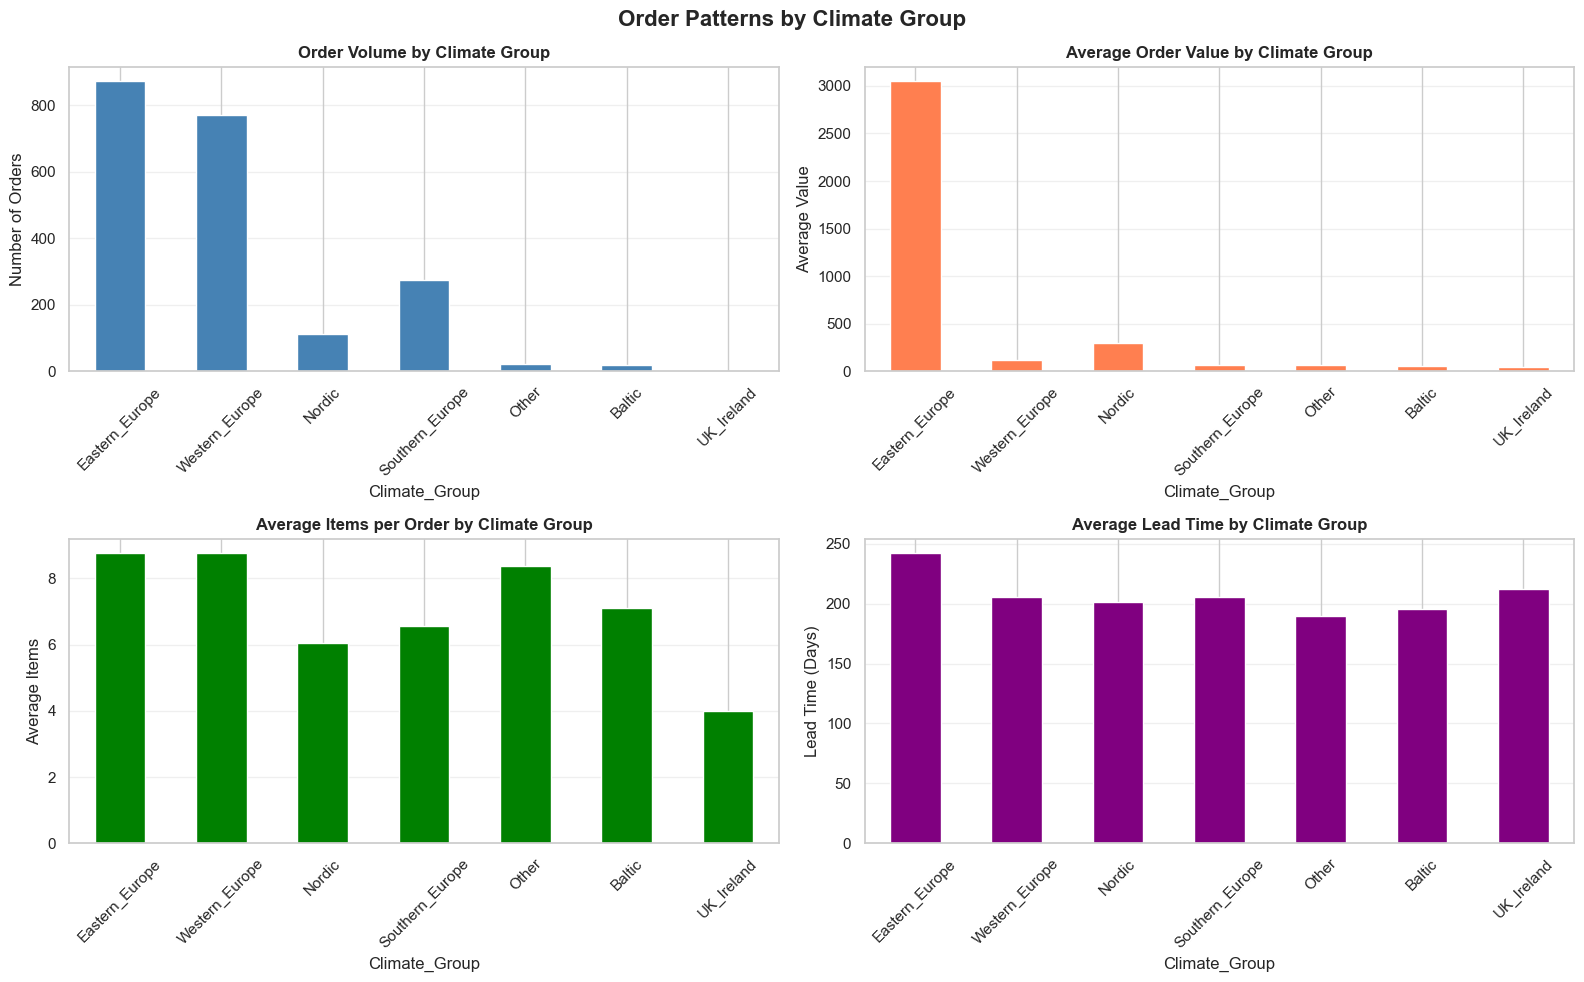



Seasonality by Climate Group:
Order_Season      Fall  Spring  Summer  Winter
Climate_Group                                 
Baltic           33.33    0.00   61.11    5.56
Eastern_Europe    3.78    5.38   67.70   23.14
Nordic           29.82    9.65   39.47   21.05
Other             0.00    0.00   80.95   19.05
Southern_Europe  28.36    8.36   56.36    6.91
UK_Ireland        0.00    0.00  100.00    0.00
Western_Europe   10.13   11.43   41.43   37.01
Order_Season      Fall  Spring  Summer  Winter
Climate_Group                                 
Baltic           33.33    0.00   61.11    5.56
Eastern_Europe    3.78    5.38   67.70   23.14
Nordic           29.82    9.65   39.47   21.05
Other             0.00    0.00   80.95   19.05
Southern_Europe  28.36    8.36   56.36    6.91
UK_Ireland        0.00    0.00  100.00    0.00
Western_Europe   10.13   11.43   41.43   37.01


In [342]:
# 7. CLIMATE GROUP ANALYSIS
print("="*80)
print("CLIMATE GROUP ANALYSIS")
print("="*80)

# Aggregate by Climate Group
climate_stats = df_processed.groupby('Climate_Group').agg({
    'Value': ['mean', 'sum', 'std'],
    'Items': ['mean', 'sum', 'std'],
    'Lead_Time_Days': ['mean', 'std'],
    'Price_Per_Item': 'mean',
    'Order Date': 'count'
}).round(2)

climate_stats.columns = ['Avg_Value', 'Total_Value', 'Std_Value',
                         'Avg_Items', 'Total_Items', 'Std_Items',
                         'Avg_Lead_Time', 'Std_Lead_Time',
                         'Avg_Price_Per_Item', 'Order_Count']

climate_stats = climate_stats.sort_values('Total_Value', ascending=False)

print("\nClimate Group Statistics:")
print(climate_stats)

# Visualize climate patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Order Patterns by Climate Group', fontsize=16, fontweight='bold')

# Total Orders by Climate
climate_stats['Order_Count'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Order Volume by Climate Group', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Average Value by Climate
climate_stats['Avg_Value'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Average Order Value by Climate Group', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Value')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Average Items by Climate
climate_stats['Avg_Items'].plot(kind='bar', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Average Items per Order by Climate Group', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Items')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Lead Time by Climate
climate_stats['Avg_Lead_Time'].plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Average Lead Time by Climate Group', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Lead Time (Days)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Climate group seasonality
print("\n\nSeasonality by Climate Group:")
climate_season = pd.crosstab(df_processed['Climate_Group'], df_processed['Order_Season'], normalize='index') * 100
print(climate_season.round(2))


ROUTE AND ORDER TYPE ANALYSIS

Route Statistics:
        Avg_Value  Total_Value  Std_Value  Avg_Items  Total_Items  \
Route                                                               
1          173.18     27535.74     291.69       4.48          712   
AD0001      61.44       860.09       7.91       5.86           82   
AL0002      49.00       343.00       4.97       6.29           44   
AT0003      71.47     11720.44      46.10       6.87         1127   
BE0001      66.89       869.63      80.76       6.85           89   
CE5001     172.33       344.66       0.00       18.0           36   
CH0001     141.70     19979.80     769.82       7.25         1022   
CZ0002      65.84       855.95       5.23       6.54           85   
DE0005     206.33      7015.34     589.54      20.76          706   
DK01FR     538.70     11312.78     230.96       4.86          102   
FI0003     118.28      5440.84      22.91      10.96          504   
FI01FR      64.74      4013.70      24.20       6.76  

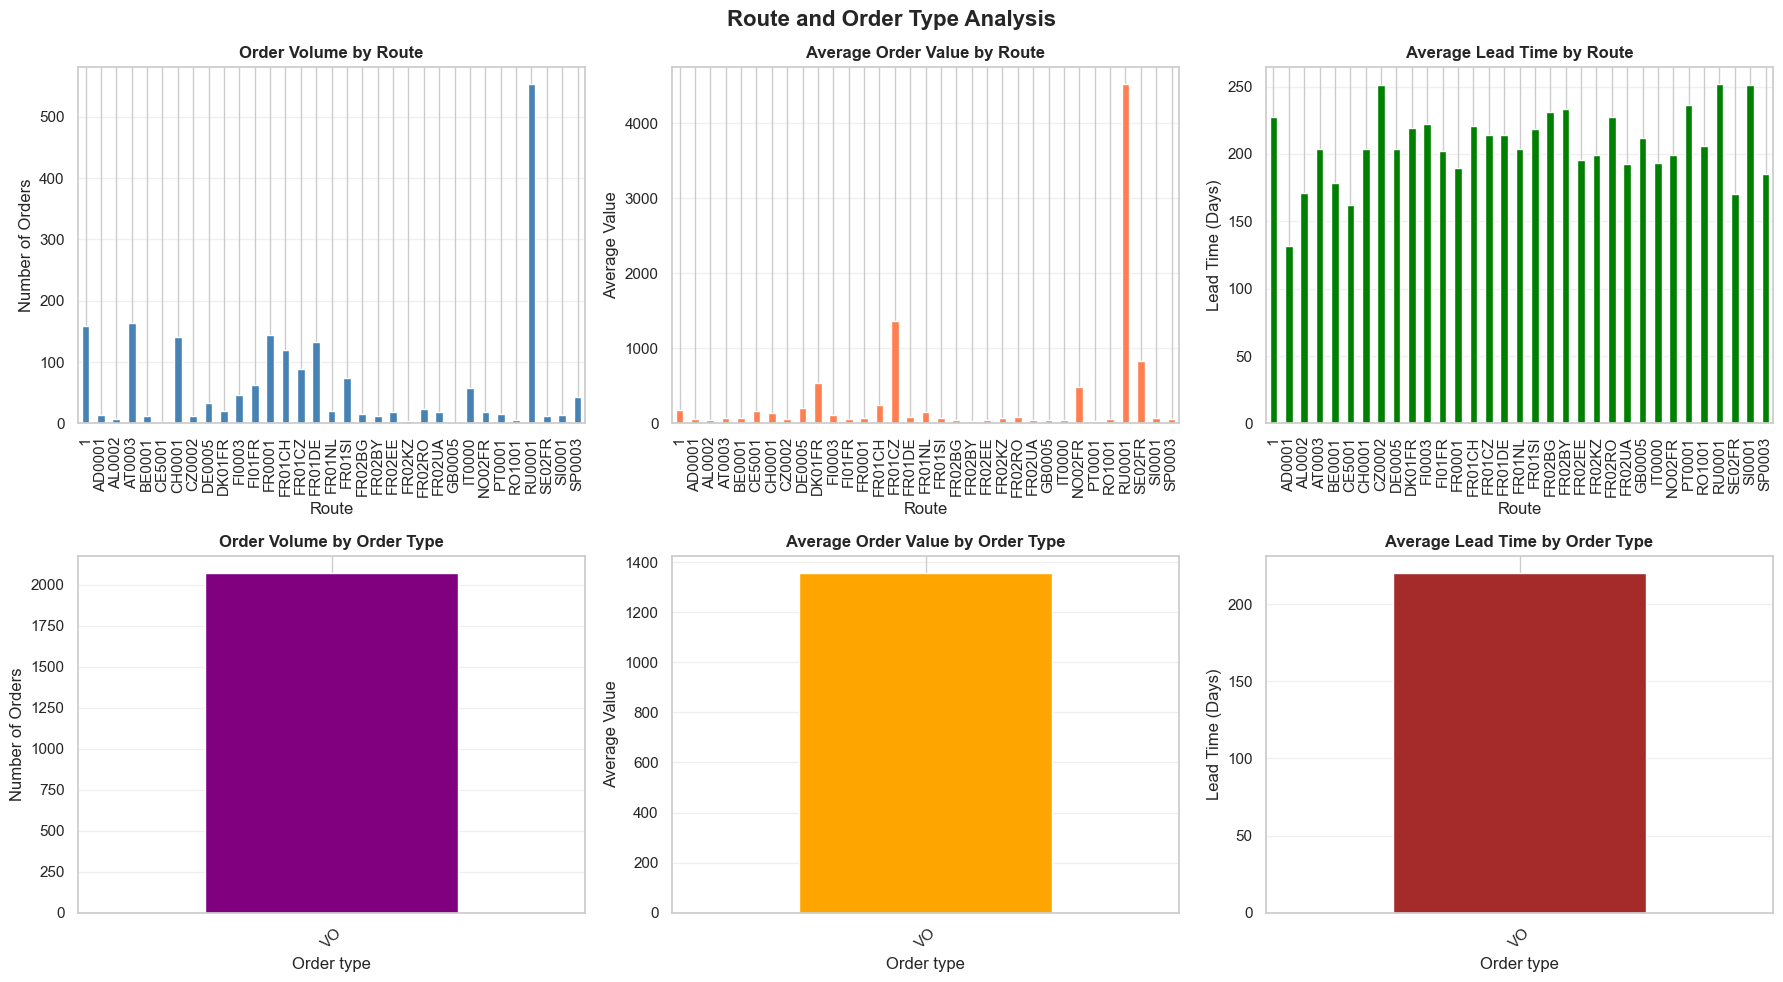



Route × Order Type Distribution:
Order type    VO   All
Route                 
1            159   159
AD0001        14    14
AL0002         7     7
AT0003       164   164
BE0001        13    13
CE5001         2     2
CH0001       141   141
CZ0002        13    13
DE0005        34    34
DK01FR        21    21
FI0003        46    46
FI01FR        62    62
FR0001       144   144
FR01CH       120   120
FR01CZ        89    89
FR01DE       133   133
FR01NL        21    21
FR01SI        74    74
FR02BG        16    16
FR02BY        12    12
FR02EE        18    18
FR02KZ         4     4
FR02RO        24    24
FR02UA        19    19
GB0005         1     1
IT0000        58    58
NO02FR        19    19
PT0001        15    15
RO1001         6     6
RU0001       554   554
SE02FR        12    12
SI0001        14    14
SP0003        43    43
All         2072  2072


In [343]:
# 8. ROUTE AND ORDER TYPE ANALYSIS
print("="*80)
print("ROUTE AND ORDER TYPE ANALYSIS")
print("="*80)

# Route analysis
route_stats = df_processed.groupby('Route').agg({
    'Value': ['mean', 'sum', 'std'],
    'Items': ['mean', 'sum'],
    'Lead_Time_Days': ['mean', 'std'],
    'Order Date': 'count'
}).round(2)

route_stats.columns = ['Avg_Value', 'Total_Value', 'Std_Value',
                       'Avg_Items', 'Total_Items',
                       'Avg_Lead_Time', 'Std_Lead_Time',
                       'Order_Count']

print("\nRoute Statistics:")
print(route_stats)

# Order Type analysis
order_type_stats = df_processed.groupby('Order type').agg({
    'Value': ['mean', 'sum', 'std'],
    'Items': ['mean', 'sum'],
    'Lead_Time_Days': ['mean', 'std'],
    'Order Date': 'count'
}).round(2)

order_type_stats.columns = ['Avg_Value', 'Total_Value', 'Std_Value',
                             'Avg_Items', 'Total_Items',
                             'Avg_Lead_Time', 'Std_Lead_Time',
                             'Order_Count']

print("\n\nOrder Type Statistics:")
print(order_type_stats)

# Visualize Route and Order Type patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Route and Order Type Analysis', fontsize=16, fontweight='bold')

# Route - Order Count
route_stats['Order_Count'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Order Volume by Route', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].grid(axis='y', alpha=0.3)

# Route - Avg Value
route_stats['Avg_Value'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Average Order Value by Route', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Value')
axes[0, 1].grid(axis='y', alpha=0.3)

# Route - Avg Lead Time
route_stats['Avg_Lead_Time'].plot(kind='bar', ax=axes[0, 2], color='green')
axes[0, 2].set_title('Average Lead Time by Route', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Lead Time (Days)')
axes[0, 2].grid(axis='y', alpha=0.3)

# Order Type - Order Count
order_type_stats['Order_Count'].plot(kind='bar', ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Order Volume by Order Type', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Orders')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Order Type - Avg Value
order_type_stats['Avg_Value'].plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Average Order Value by Order Type', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Value')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

# Order Type - Avg Lead Time
order_type_stats['Avg_Lead_Time'].plot(kind='bar', ax=axes[1, 2], color='brown')
axes[1, 2].set_title('Average Lead Time by Order Type', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Lead Time (Days)')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Cross-tabulation: Route vs Order Type
print("\n\nRoute × Order Type Distribution:")
route_order_crosstab = pd.crosstab(df_processed['Route'], df_processed['Order type'], margins=True)
print(route_order_crosstab)


MISSING VALUES AND DATA GAPS ANALYSIS

Missing Values Count:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []


Temporal Gaps Analysis:
Missing months in data: [Period('2010-07', 'M'), Period('2010-08', 'M'), Period('2010-09', 'M'), Period('2010-10', 'M'), Period('2010-11', 'M'), Period('2011-12', 'M'), Period('2012-02', 'M'), Period('2012-03', 'M'), Period('2012-05', 'M'), Period('2012-06', 'M'), Period('2012-07', 'M'), Period('2012-08', 'M'), Period('2012-09', 'M'), Period('2012-10', 'M')]

Monthly order count statistics:
Mean: 77
Median: 14
Min: 1 (in 2010-06)
Max: 611 (in 2011-07)


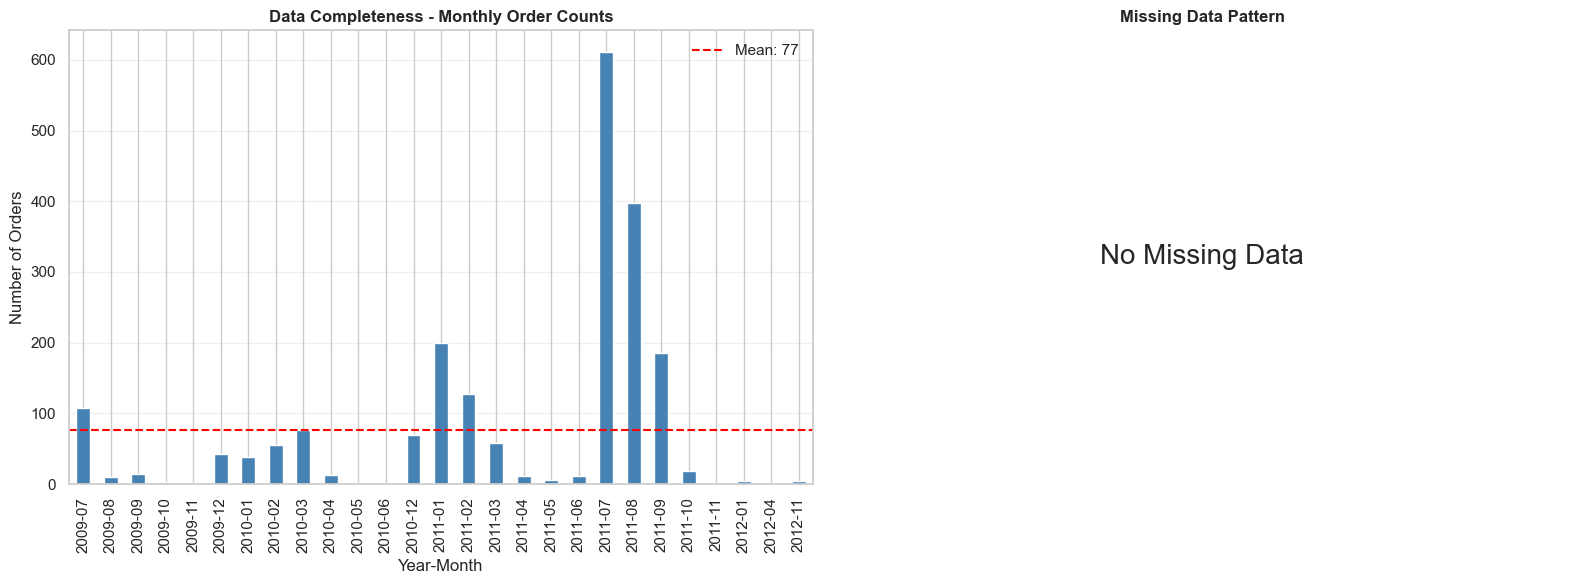

In [344]:
# 9. MISSING VALUES AND DATA GAPS ANALYSIS
print("="*80)
print("MISSING VALUES AND DATA GAPS ANALYSIS")
print("="*80)

# Check for any missing values in processed data
print("\nMissing Values Count:")
missing_data = df_processed.isnull().sum()
missing_pct = (missing_data / len(df_processed)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0])

# Check for temporal gaps (missing months)
print("\n\nTemporal Gaps Analysis:")
date_range = pd.date_range(start=df_processed['Order Date'].min(), 
                           end=df_processed['Order Date'].max(), 
                           freq='MS')
actual_months = df_processed['YearMonth'].unique()
expected_months = pd.Series([d.to_period('M') for d in date_range]).unique()

missing_months = set(expected_months) - set(actual_months)
if len(missing_months) > 0:
    print(f"Missing months in data: {sorted(missing_months)}")
else:
    print("No missing months detected - data is continuous")

# Check data sparsity by year-month
monthly_counts = df_processed.groupby('YearMonth').size()
print(f"\nMonthly order count statistics:")
print(f"Mean: {monthly_counts.mean():.0f}")
print(f"Median: {monthly_counts.median():.0f}")
print(f"Min: {monthly_counts.min():.0f} (in {monthly_counts.idxmin()})")
print(f"Max: {monthly_counts.max():.0f} (in {monthly_counts.idxmax()})")

# Visualize data completeness
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly data completeness
monthly_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(monthly_counts.mean(), color='red', linestyle='--', label=f'Mean: {monthly_counts.mean():.0f}')
axes[0].set_title('Data Completeness - Monthly Order Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xlabel('Year-Month')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=90)

# Missing data heatmap (if any)
missing_matrix = df_processed.isnull().astype(int)
if missing_matrix.sum().sum() > 0:
    sns.heatmap(missing_matrix.T, cmap='RdYlGn_r', cbar=True, ax=axes[1])
    axes[1].set_title('Missing Data Pattern', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No Missing Data', ha='center', va='center', fontsize=20)
    axes[1].set_title('Missing Data Pattern', fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()


ROW COUNTS BY ROUTE

Route Distribution:
        Count
Route        
1         159
AD0001     14
AL0002      7
AT0003    164
BE0001     13
CE5001      2
CH0001    141
CZ0002     13
DE0005     34
DK01FR     21
FI0003     46
FI01FR     62
FR0001    144
FR01CH    120
FR01CZ     89
FR01DE    133
FR01NL     21
FR01SI     74
FR02BG     16
FR02BY     12
FR02EE     18
FR02KZ      4
FR02RO     24
FR02UA     19
GB0005      1
IT0000     58
NO02FR     19
PT0001     15
RO1001      6
RU0001    554
SE02FR     12
SI0001     14
SP0003     43


Total Routes: 33
Total Orders: 2,072


Route Distribution (with percentages):
  Route 1: 159 orders (7.67%)
  Route AD0001: 14 orders (0.68%)
  Route AL0002: 7 orders (0.34%)
  Route AT0003: 164 orders (7.92%)
  Route BE0001: 13 orders (0.63%)
  Route CE5001: 2 orders (0.10%)
  Route CH0001: 141 orders (6.81%)
  Route CZ0002: 13 orders (0.63%)
  Route DE0005: 34 orders (1.64%)
  Route DK01FR: 21 orders (1.01%)
  Route FI0003: 46 orders (2.22%)
  Route FI01FR: 62 

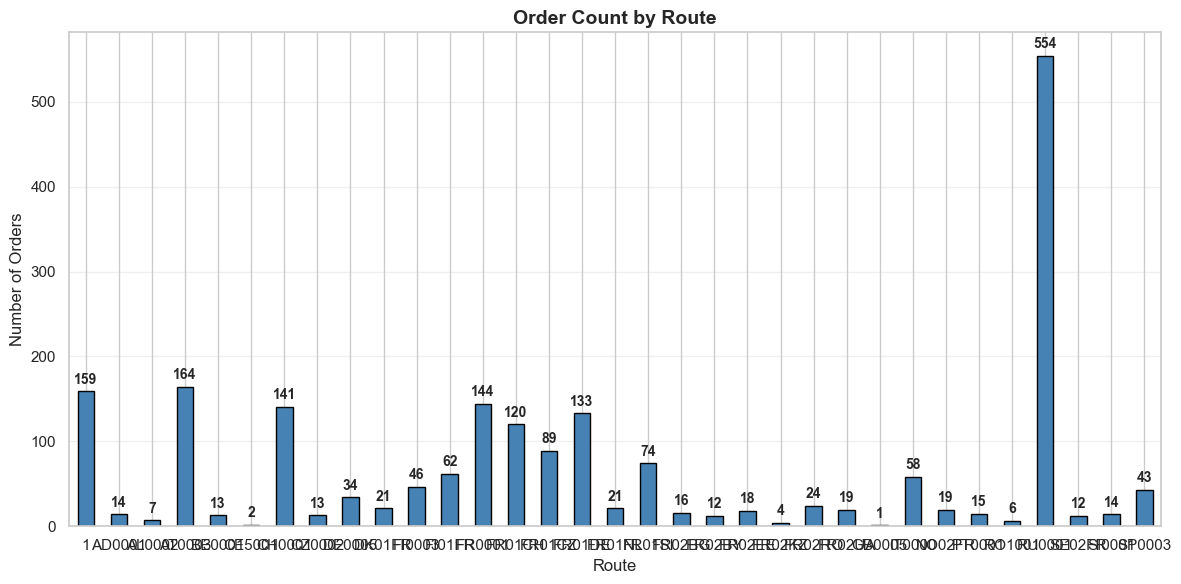

In [345]:
# Count rows/orders for each unique Route
print("="*80)
print("ROW COUNTS BY ROUTE")
print("="*80)

route_counts = df_processed['Route'].value_counts().sort_index()

print("\nRoute Distribution:")
print(route_counts.to_frame(name='Count'))

print(f"\n\nTotal Routes: {df_processed['Route'].nunique()}")
print(f"Total Orders: {len(df_processed):,}")

# Show percentages
print("\n\nRoute Distribution (with percentages):")
for route, count in route_counts.items():
    pct = (count / len(df_processed)) * 100
    print(f"  Route {route}: {count:,} orders ({pct:.2f}%)")

# Visualize
plt.figure(figsize=(12, 6))
route_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Order Count by Route', fontsize=14, fontweight='bold')
plt.xlabel('Route', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(route_counts.values):
    plt.text(i, v + max(route_counts.values) * 0.01, f'{v:,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


VALUE SEGMENTATION AND CUSTOMER BEHAVIOR

Value Segmentation (Quartiles):
               Avg_Value  Total_Value  Order_Count  Avg_Items  Avg_Lead_Time
Value_Segment                                                               
Low                31.80     16535.79          520        3.0         206.83
Medium             67.51     34837.27          516       6.12         207.12
High              536.50    277906.43          518       9.15         220.96
Premium          4793.83   2483203.37          518      14.92         246.16


Top 15 Countries - Ordering Pattern:
                       Total_Orders  Total_Value  Time_Span_Days  \
Customer Country Code                                              
RU                              554   2508915.07             929   
CZ                              107    130279.20             259   
CH                              262     52280.92             692   
DE                              167     17849.45             643   
PL               

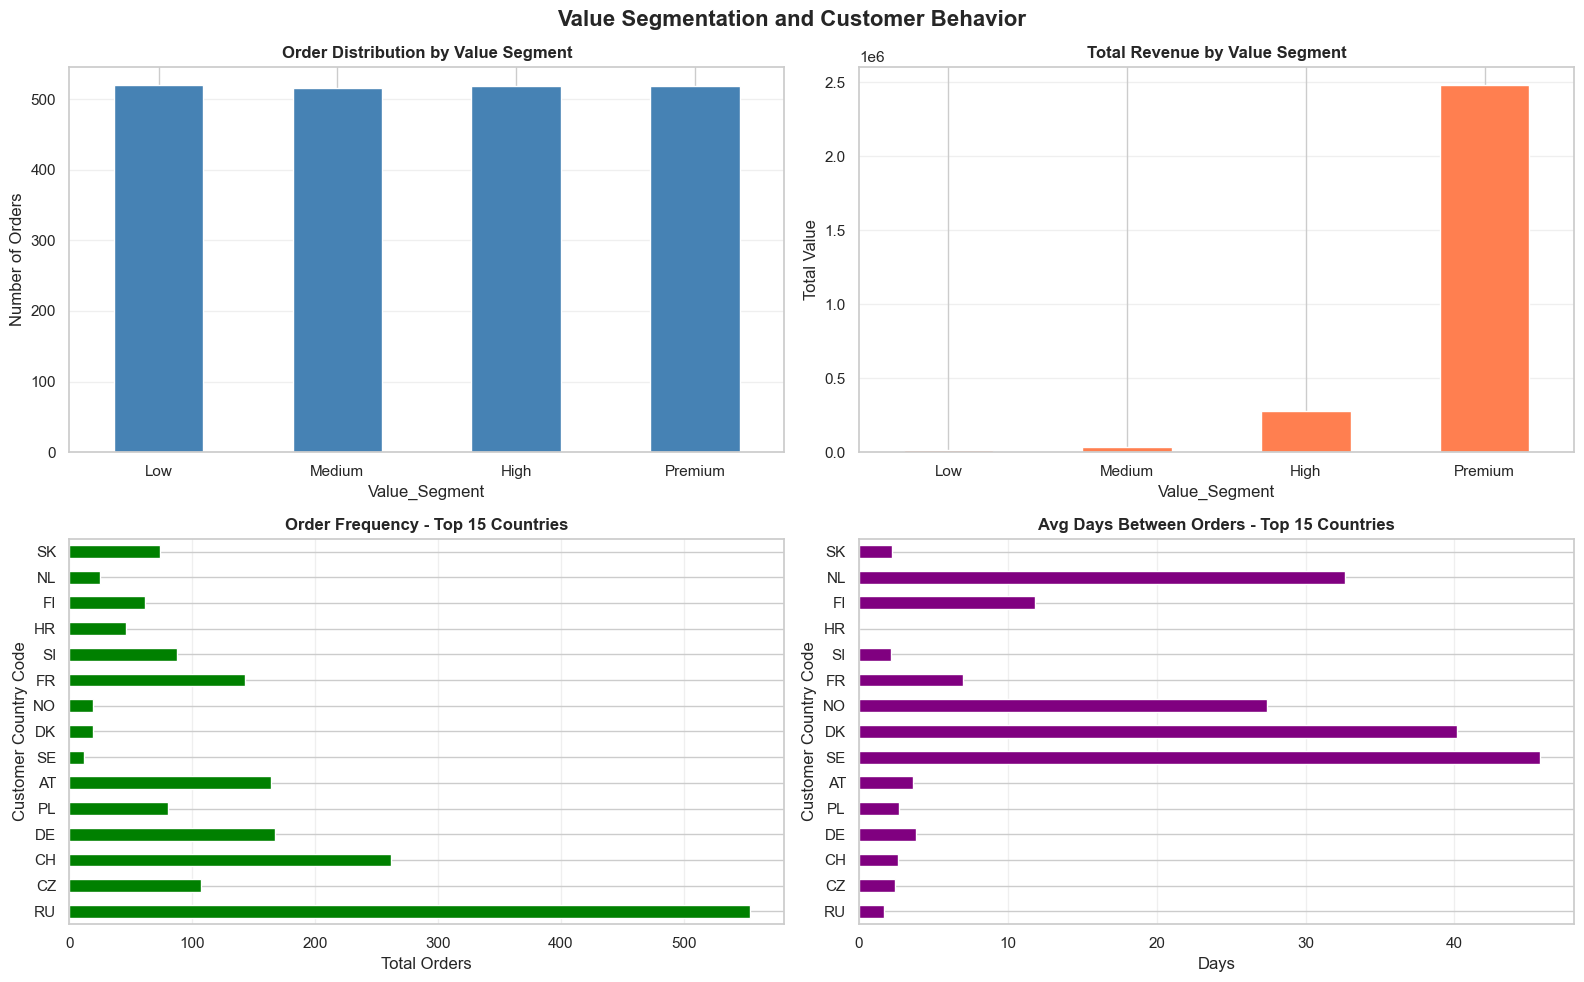



Pareto Analysis:
Number of countries contributing to 80% of revenue: 0 (out of 30)
Number of countries contributing to 90% of revenue: 1 (out of 30)


In [346]:
# 10. BUSINESS INSIGHTS - Value Segments and Customer Lifetime Analysis
print("="*80)
print("VALUE SEGMENTATION AND CUSTOMER BEHAVIOR")
print("="*80)

# Value segmentation - RFM-like analysis
print("\nValue Segmentation (Quartiles):")
df_processed['Value_Segment'] = pd.qcut(df_processed['Value'], q=4, 
                                         labels=['Low', 'Medium', 'High', 'Premium'])

segment_stats = df_processed.groupby('Value_Segment').agg({
    'Value': ['mean', 'sum', 'count'],
    'Items': 'mean',
    'Lead_Time_Days': 'mean'
}).round(2)

segment_stats.columns = ['Avg_Value', 'Total_Value', 'Order_Count', 'Avg_Items', 'Avg_Lead_Time']
print(segment_stats)

# Customer Country Order Frequency
country_order_freq = df_processed.groupby('Customer Country Code').agg({
    'Customer Order Code': 'count',
    'Value': 'sum',
    'Order Date': lambda x: (x.max() - x.min()).days
}).rename(columns={
    'Customer Order Code': 'Total_Orders',
    'Value': 'Total_Value',
    'Order Date': 'Time_Span_Days'
})

country_order_freq['Avg_Days_Between_Orders'] = country_order_freq['Time_Span_Days'] / country_order_freq['Total_Orders']
country_order_freq = country_order_freq.sort_values('Total_Value', ascending=False).head(15)

print("\n\nTop 15 Countries - Ordering Pattern:")
print(country_order_freq.round(2))

# Visualize segments
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Value Segmentation and Customer Behavior', fontsize=16, fontweight='bold')

# Orders by Segment
segment_stats['Order_Count'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Order Distribution by Value Segment', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].grid(axis='y', alpha=0.3)

# Revenue by Segment
segment_stats['Total_Value'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Total Revenue by Value Segment', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Value')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].grid(axis='y', alpha=0.3)

# Top Countries by Order Frequency
country_order_freq['Total_Orders'].plot(kind='barh', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Order Frequency - Top 15 Countries', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Orders')
axes[1, 0].grid(axis='x', alpha=0.3)

# Average Days Between Orders
country_order_freq['Avg_Days_Between_Orders'].plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Avg Days Between Orders - Top 15 Countries', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Days')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Pareto Analysis (80/20 rule)
print("\n\nPareto Analysis:")
country_revenue = df_processed.groupby('Customer Country Code')['Value'].sum().sort_values(ascending=False)
cumulative_pct = (country_revenue.cumsum() / country_revenue.sum()) * 100

countries_for_80 = (cumulative_pct <= 80).sum()
countries_for_90 = (cumulative_pct <= 90).sum()

print(f"Number of countries contributing to 80% of revenue: {countries_for_80} (out of {df_processed['Customer Country Code'].nunique()})")
print(f"Number of countries contributing to 90% of revenue: {countries_for_90} (out of {df_processed['Customer Country Code'].nunique()})")


ADVANCED CORRELATION AND FEATURE INTERACTION ANALYSIS


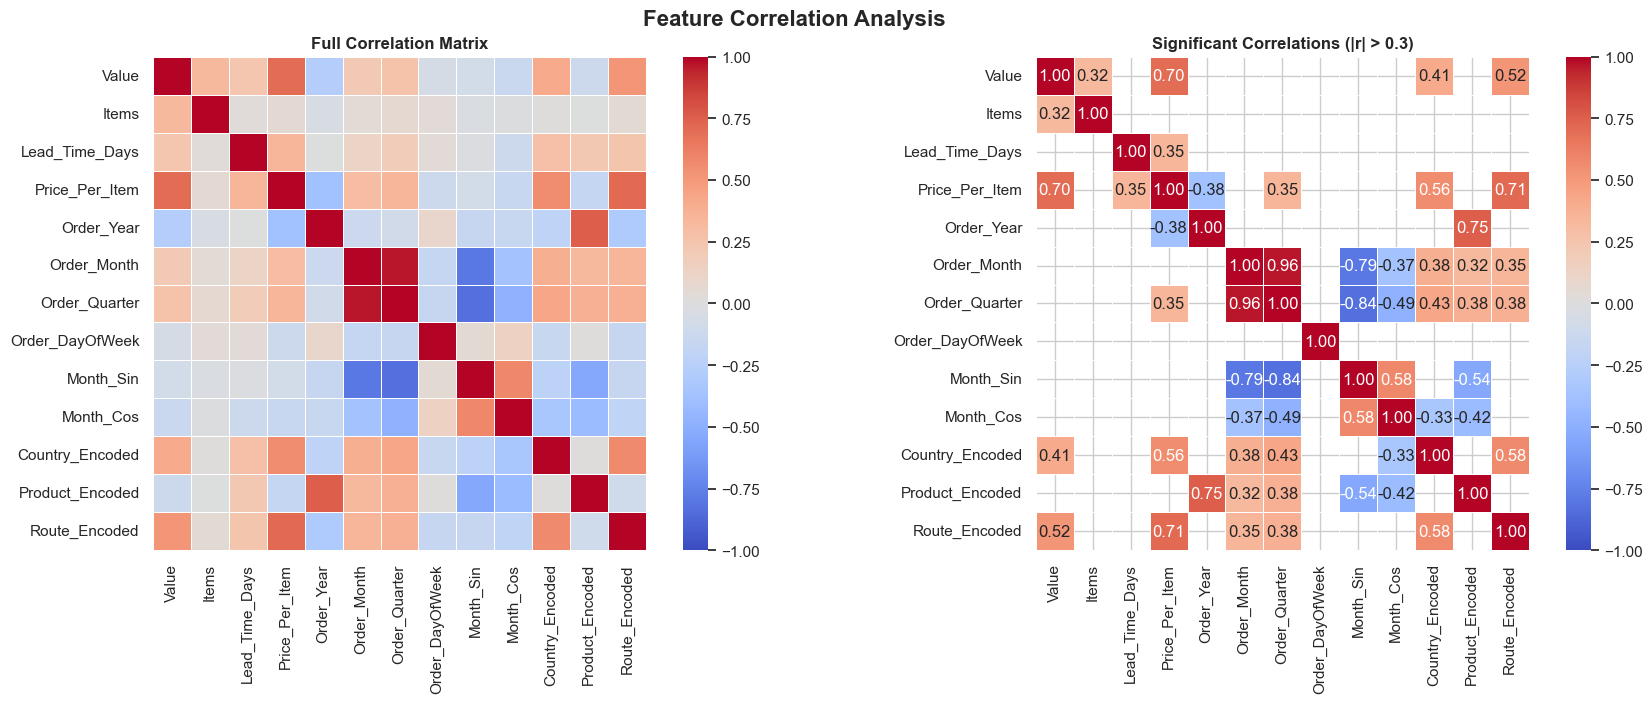


Strongest Correlations with Value:
Value              1.000000
Price_Per_Item     0.699507
Route_Encoded      0.522718
Country_Encoded    0.411915
Items              0.323219
Order_Year         0.268311
Order_Quarter      0.259352
Lead_Time_Days     0.235494
Order_Month        0.214918
Month_Cos          0.136962
Name: Value, dtype: float64

Strongest Correlations with Items:
Items              1.000000
Value              0.323219
Order_Quarter      0.065995
Price_Per_Item     0.058052
Route_Encoded      0.053277
Order_Year         0.042924
Order_Month        0.042438
Order_DayOfWeek    0.034245
Lead_Time_Days     0.024912
Month_Sin          0.024409
Name: Items, dtype: float64

Strongest Correlations with Lead_Time_Days:
Lead_Time_Days     1.000000
Price_Per_Item     0.348144
Country_Encoded    0.274983
Route_Encoded      0.248278
Value              0.235494
Product_Encoded    0.225915
Order_Quarter      0.191100
Order_Month        0.124380
Month_Cos          0.123032
Order_DayOfWeek

In [347]:
# 11. ADVANCED CORRELATION ANALYSIS - Feature Relationships
print("="*80)
print("ADVANCED CORRELATION AND FEATURE INTERACTION ANALYSIS")
print("="*80)

# Create additional interaction features for analysis
df_analysis = df_processed.copy()

# Encode categorical variables for correlation
from sklearn.preprocessing import LabelEncoder
le_country = LabelEncoder()
le_product = LabelEncoder()
le_route = LabelEncoder()

df_analysis['Country_Encoded'] = le_country.fit_transform(df_analysis['Customer Country Code'])
df_analysis['Product_Encoded'] = le_product.fit_transform(df_analysis['Product Code'])
df_analysis['Route_Encoded'] = le_route.fit_transform(df_analysis['Route'])

# Select features for correlation analysis
correlation_features = ['Value', 'Items', 'Lead_Time_Days', 'Price_Per_Item', 
                        'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_DayOfWeek',
                        'Month_Sin', 'Month_Cos', 'Country_Encoded', 'Product_Encoded', 
                        'Route_Encoded']

# Calculate correlation matrix
corr_matrix = df_analysis[correlation_features].corr()

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Correlation Analysis', fontsize=16, fontweight='bold')

# Full correlation heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Full Correlation Matrix', fontsize=12, fontweight='bold')

# High correlations only (|r| > 0.3)
mask = np.abs(corr_matrix) < 0.3
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Significant Correlations (|r| > 0.3)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Identify strongest correlations with target variables
print("\nStrongest Correlations with Value:")
value_corr = corr_matrix['Value'].abs().sort_values(ascending=False)
print(value_corr.head(10))

print("\nStrongest Correlations with Items:")
items_corr = corr_matrix['Items'].abs().sort_values(ascending=False)
print(items_corr.head(10))

print("\nStrongest Correlations with Lead_Time_Days:")
lead_corr = corr_matrix['Lead_Time_Days'].abs().sort_values(ascending=False)
print(lead_corr.head(10))

# Detect multicollinearity
print("\n\nMulticollinearity Check (VIF would be computed in modeling phase)")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("High correlations between features (|r| > 0.7):")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  {feat1} <-> {feat2}: {corr_val:.3f}")
else:
    print("No strong multicollinearity detected (all |r| < 0.7)")


SEASONAL DECOMPOSITION ANALYSIS


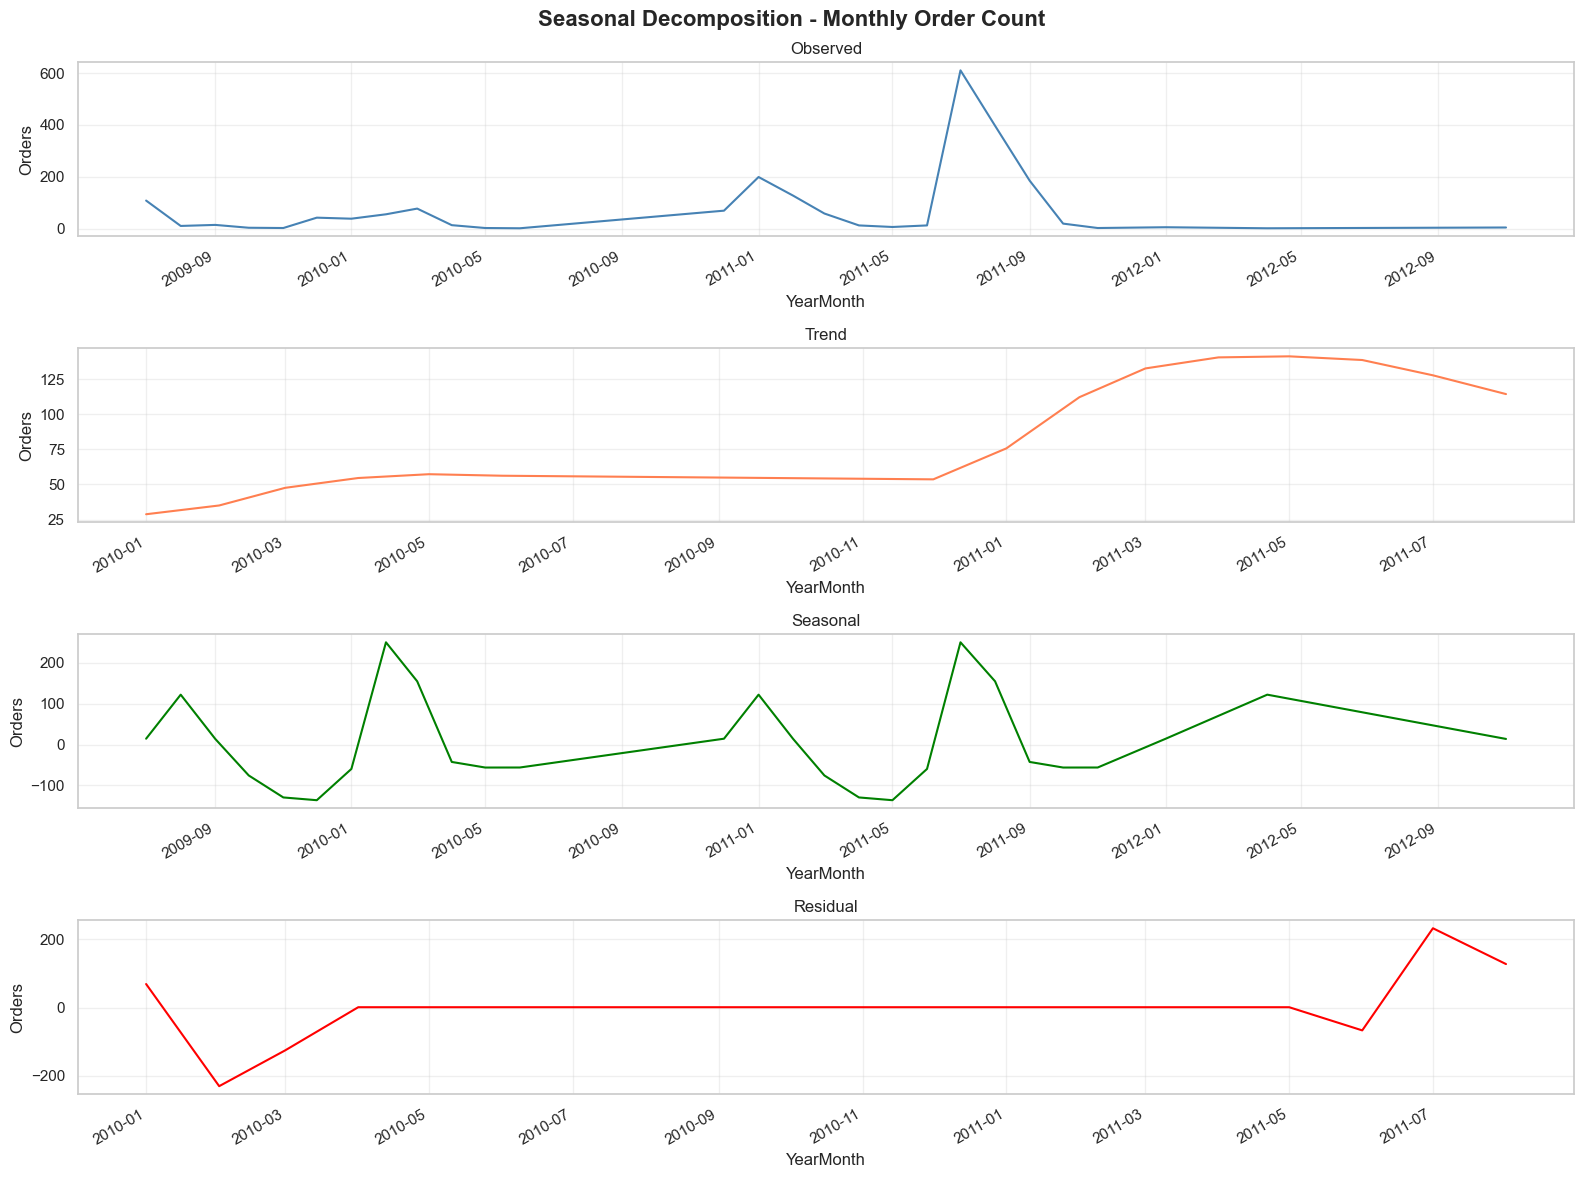


Seasonal Strength: 0.615
Trend Strength: 0.321

Monthly Seasonal Pattern (Average Effect):
  May: -96.28
  Oct: -65.97
  Dec: -60.95
  Jun: -57.94
  Nov: -57.30
  Apr: -16.59
  Sep: -14.36
  Jan: +25.68
  Mar: +39.68
  Feb: +132.23
  Jul: +132.52
  Aug: +138.68


In [348]:
# 12. SEASONAL DECOMPOSITION AND TREND ANALYSIS
print("="*80)
print("SEASONAL DECOMPOSITION ANALYSIS")
print("="*80)

# Prepare monthly time series
monthly_ts = df_processed.groupby('YearMonth').agg({
    'Value': 'sum',
    'Items': 'sum',
    'Order Date': 'count'
})
monthly_ts.columns = ['Total_Value', 'Total_Items', 'Order_Count']
monthly_ts.index = monthly_ts.index.to_timestamp()

# Perform seasonal decomposition for Order Count
if len(monthly_ts) >= 24:  # Need at least 2 years for seasonal decomposition
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    # Decompose Order Count
    decomp_orders = seasonal_decompose(monthly_ts['Order_Count'], model='additive', period=12)
    
    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    fig.suptitle('Seasonal Decomposition - Monthly Order Count', fontsize=16, fontweight='bold')
    
    decomp_orders.observed.plot(ax=axes[0], color='steelblue')
    axes[0].set_title('Observed', fontsize=12)
    axes[0].set_ylabel('Orders')
    axes[0].grid(alpha=0.3)
    
    decomp_orders.trend.plot(ax=axes[1], color='coral')
    axes[1].set_title('Trend', fontsize=12)
    axes[1].set_ylabel('Orders')
    axes[1].grid(alpha=0.3)
    
    decomp_orders.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_title('Seasonal', fontsize=12)
    axes[2].set_ylabel('Orders')
    axes[2].grid(alpha=0.3)
    
    decomp_orders.resid.plot(ax=axes[3], color='red')
    axes[3].set_title('Residual', fontsize=12)
    axes[3].set_ylabel('Orders')
    axes[3].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Analyze seasonal strength
    seasonal_strength = 1 - (decomp_orders.resid.var() / (decomp_orders.seasonal + decomp_orders.resid).var())
    trend_strength = 1 - (decomp_orders.resid.var() / (decomp_orders.trend + decomp_orders.resid).var())
    
    print(f"\nSeasonal Strength: {seasonal_strength:.3f}")
    print(f"Trend Strength: {trend_strength:.3f}")
    
    # Identify peak and trough months
    seasonal_pattern = decomp_orders.seasonal.groupby(decomp_orders.seasonal.index.month).mean().sort_values()
    print("\nMonthly Seasonal Pattern (Average Effect):")
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    for month, value in seasonal_pattern.items():
        print(f"  {month_names[month-1]}: {value:+.2f}")
    
else:
    print("Insufficient data for seasonal decomposition (need at least 24 months)")
    
    # Alternative: Simple moving average
    monthly_ts['MA_3'] = monthly_ts['Order_Count'].rolling(window=3).mean()
    monthly_ts['MA_6'] = monthly_ts['Order_Count'].rolling(window=6).mean()
    
    fig, ax = plt.subplots(figsize=(16, 6))
    monthly_ts['Order_Count'].plot(ax=ax, label='Actual', marker='o', linewidth=2)
    monthly_ts['MA_3'].plot(ax=ax, label='3-Month MA', linestyle='--', linewidth=2)
    monthly_ts['MA_6'].plot(ax=ax, label='6-Month MA', linestyle='--', linewidth=2)
    ax.set_title('Order Count with Moving Averages', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Orders')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()


COHORT ANALYSIS - PERFORMANCE EVOLUTION


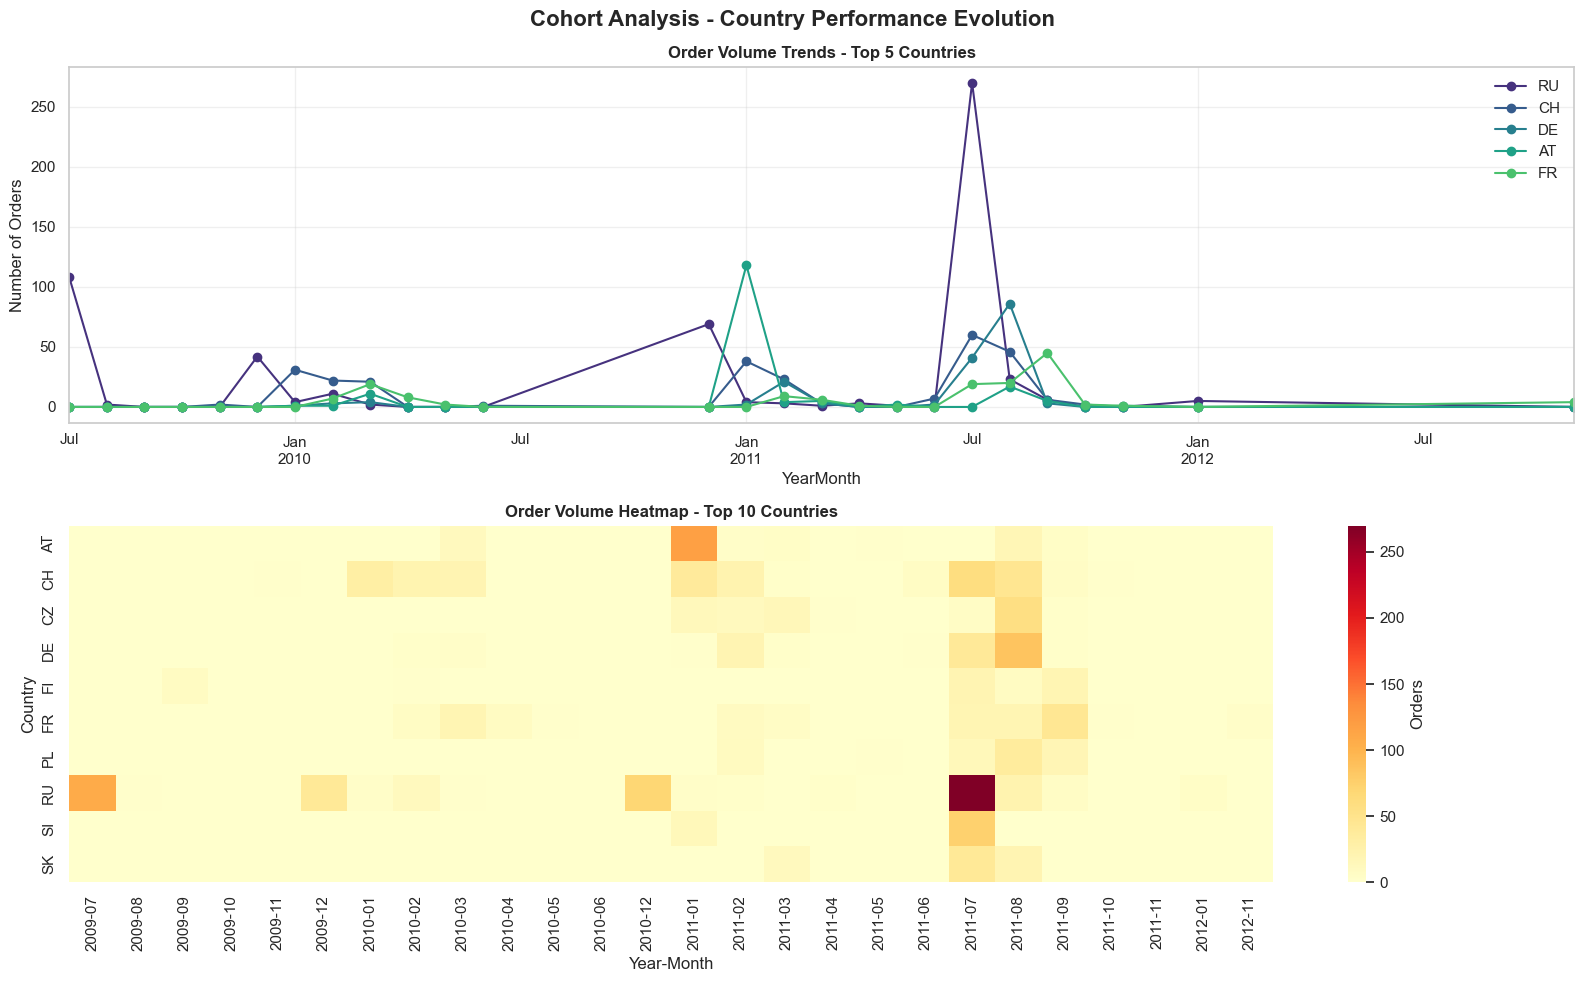

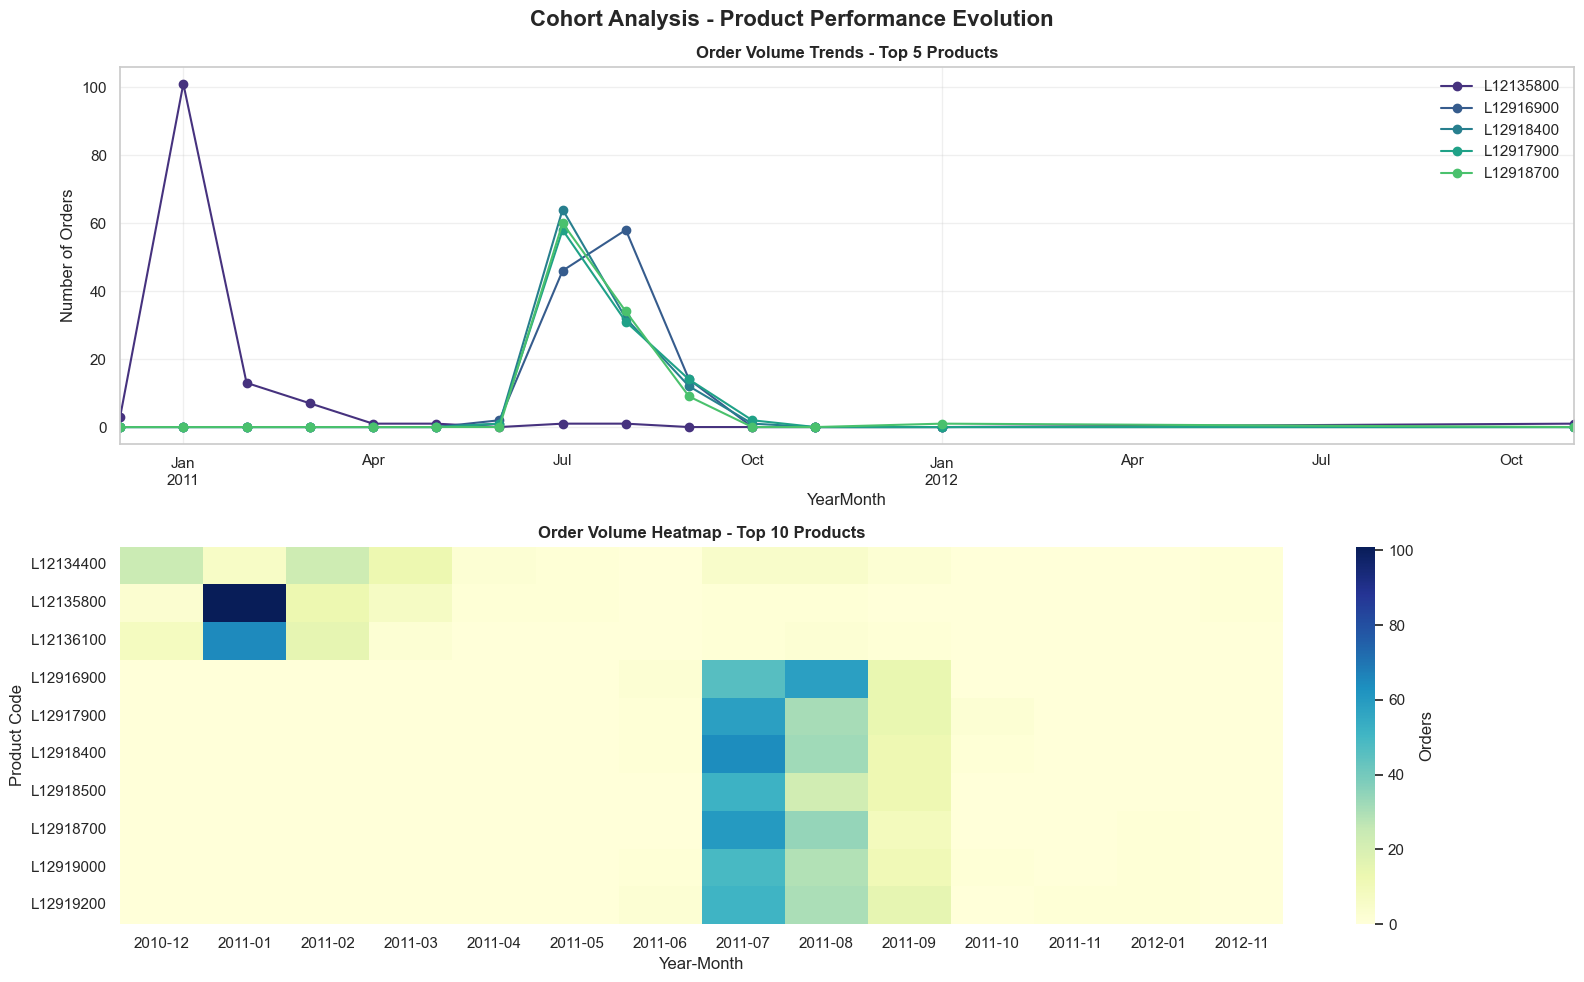


Cohort Insights:
Countries with consistent high volume: ['RU', 'CH', 'DE']
Products with consistent high volume: ['L12135800', 'L12916900', 'L12918400']


In [349]:
# 13. COHORT ANALYSIS - Product and Country Performance Over Time
print("="*80)
print("COHORT ANALYSIS - PERFORMANCE EVOLUTION")
print("="*80)

# Country cohort analysis - order volume trends
top_10_countries = df_processed['Customer Country Code'].value_counts().head(10).index
country_monthly = df_processed[df_processed['Customer Country Code'].isin(top_10_countries)].groupby(
    ['YearMonth', 'Customer Country Code']
).size().reset_index(name='Orders')

country_pivot = country_monthly.pivot(index='YearMonth', columns='Customer Country Code', values='Orders').fillna(0)

# Plot country trends
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Cohort Analysis - Country Performance Evolution', fontsize=16, fontweight='bold')

# Line plot for top countries
for country in top_10_countries[:5]:  # Top 5 for clarity
    if country in country_pivot.columns:
        country_pivot[country].plot(ax=axes[0], marker='o', label=country)
axes[0].set_title('Order Volume Trends - Top 5 Countries', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Heatmap of country performance
sns.heatmap(country_pivot.T, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Orders'})
axes[1].set_title('Order Volume Heatmap - Top 10 Countries', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Country')
axes[1].set_xlabel('Year-Month')

plt.tight_layout()
plt.show()

# Product cohort analysis
top_10_products = df_processed['Product Code'].value_counts().head(10).index
product_monthly = df_processed[df_processed['Product Code'].isin(top_10_products)].groupby(
    ['YearMonth', 'Product Code']
).size().reset_index(name='Orders')

product_pivot = product_monthly.pivot(index='YearMonth', columns='Product Code', values='Orders').fillna(0)

# Plot product trends
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Cohort Analysis - Product Performance Evolution', fontsize=16, fontweight='bold')

# Line plot for top products
for product in top_10_products[:5]:  # Top 5 for clarity
    if product in product_pivot.columns:
        product_pivot[product].plot(ax=axes[0], marker='o', label=product)
axes[0].set_title('Order Volume Trends - Top 5 Products', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Heatmap of product performance
sns.heatmap(product_pivot.T, cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Orders'})
axes[1].set_title('Order Volume Heatmap - Top 10 Products', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Product Code')
axes[1].set_xlabel('Year-Month')

plt.tight_layout()
plt.show()

print("\nCohort Insights:")
print(f"Countries with consistent high volume: {country_pivot.mean().sort_values(ascending=False).head(3).index.tolist()}")
print(f"Products with consistent high volume: {product_pivot.mean().sort_values(ascending=False).head(3).index.tolist()}")


In [350]:
# 14. COMPREHENSIVE EDA SUMMARY REPORT
print("="*80)
print("COMPREHENSIVE EDA SUMMARY REPORT")
print("="*80)

# Dataset Overview
print("\n" + "="*80)
print("1. DATASET OVERVIEW")
print("="*80)
print(f"Total Records: {len(df_processed):,}")
print(f"Date Range: {df_processed['Order Date'].min().date()} to {df_processed['Order Date'].max().date()}")
print(f"Time Span: {(df_processed['Order Date'].max() - df_processed['Order Date'].min()).days} days")
print(f"Number of Countries: {df_processed['Customer Country Code'].nunique()}")
print(f"Number of Products: {df_processed['Product Code'].nunique()}")
print(f"Number of Routes: {df_processed['Route'].nunique()}")
print(f"Number of Order Types: {df_processed['Order type'].nunique()}")

# Key Statistics
print("\n" + "="*80)
print("2. KEY STATISTICAL MEASURES")
print("="*80)
print(f"\nOrder Value:")
print(f"  Mean: ${df_processed['Value'].mean():.2f}")
print(f"  Median: ${df_processed['Value'].median():.2f}")
print(f"  Std Dev: ${df_processed['Value'].std():.2f}")
print(f"  Range: ${df_processed['Value'].min():.2f} - ${df_processed['Value'].max():.2f}")

print(f"\nItems per Order:")
print(f"  Mean: {df_processed['Items'].mean():.2f}")
print(f"  Median: {df_processed['Items'].median():.0f}")
print(f"  Std Dev: {df_processed['Items'].std():.2f}")
print(f"  Range: {df_processed['Items'].min()} - {df_processed['Items'].max()}")

print(f"\nLead Time (Days):")
print(f"  Mean: {df_processed['Lead_Time_Days'].mean():.1f}")
print(f"  Median: {df_processed['Lead_Time_Days'].median():.0f}")
print(f"  Std Dev: {df_processed['Lead_Time_Days'].std():.1f}")
print(f"  Range: {df_processed['Lead_Time_Days'].min()} - {df_processed['Lead_Time_Days'].max()}")

print(f"\nPrice per Item:")
print(f"  Mean: ${df_processed['Price_Per_Item'].mean():.2f}")
print(f"  Median: ${df_processed['Price_Per_Item'].median():.2f}")
print(f"  Std Dev: ${df_processed['Price_Per_Item'].std():.2f}")

# Data Quality
print("\n" + "="*80)
print("3. DATA QUALITY ASSESSMENT")
print("="*80)
print(f"Missing Values: {df_processed.isnull().sum().sum()}")
print(f"Duplicate Rows: 0 (already removed)")
outlier_pct = sum([(detect_outliers_iqr(df_processed, col)[0].shape[0] / len(df_processed) * 100) 
                   for col in ['Value', 'Items', 'Lead_Time_Days']]) / 3
print(f"Average Outlier Percentage: {outlier_pct:.2f}%")

# Distribution Insights
print("\n" + "="*80)
print("4. DISTRIBUTION INSIGHTS")
print("="*80)
print(f"Value Skewness: {df_processed['Value'].skew():.3f} ({'Right-skewed' if df_processed['Value'].skew() > 0 else 'Left-skewed'})")
print(f"Items Skewness: {df_processed['Items'].skew():.3f} ({'Right-skewed' if df_processed['Items'].skew() > 0 else 'Left-skewed'})")
print(f"Lead Time Skewness: {df_processed['Lead_Time_Days'].skew():.3f} ({'Right-skewed' if df_processed['Lead_Time_Days'].skew() > 0 else 'Left-skewed'})")

# Temporal Patterns
print("\n" + "="*80)
print("5. TEMPORAL PATTERNS")
print("="*80)
yearly_orders = df_processed.groupby('Order_Year').size()
print(f"Order Volume by Year:")
for year, count in yearly_orders.items():
    print(f"  {year}: {count:,} orders")

season_orders = df_processed['Order_Season'].value_counts()
print(f"\nSeasonal Distribution:")
for season, count in season_orders.items():
    print(f"  {season}: {count:,} orders ({count/len(df_processed)*100:.1f}%)")

# Top Performers
print("\n" + "="*80)
print("6. TOP PERFORMERS")
print("="*80)
print(f"Top 5 Countries by Volume:")
for idx, (country, count) in enumerate(df_processed['Customer Country Code'].value_counts().head(5).items(), 1):
    print(f"  {idx}. {country}: {count:,} orders ({count/len(df_processed)*100:.1f}%)")

print(f"\nTop 5 Products by Volume:")
for idx, (product, count) in enumerate(df_processed['Product Code'].value_counts().head(5).items(), 1):
    print(f"  {idx}. {product}: {count:,} orders ({count/len(df_processed)*100:.1f}%)")

# Business Insights
print("\n" + "="*80)
print("7. KEY BUSINESS INSIGHTS")
print("="*80)
print(f"• Average order value: ${df_processed['Value'].mean():.2f}")
print(f"• Total revenue: ${df_processed['Value'].sum():,.2f}")
print(f"• Average items per order: {df_processed['Items'].mean():.1f}")
print(f"• Total items sold: {df_processed['Items'].sum():,}")
print(f"• Average lead time: {df_processed['Lead_Time_Days'].mean():.1f} days")

# Calculate monthly average
monthly_orders = df_processed.groupby('YearMonth').size()
print(f"• Average monthly orders: {monthly_orders.mean():.0f}")
print(f"• Peak month orders: {monthly_orders.max():.0f}")
print(f"• Lowest month orders: {monthly_orders.min():.0f}")

print("\n" + "="*80)
print("EDA COMPLETE - Ready for Modeling")
print("="*80)


COMPREHENSIVE EDA SUMMARY REPORT

1. DATASET OVERVIEW
Total Records: 2,072
Date Range: 2009-07-08 to 2012-11-19
Time Span: 1230 days
Number of Countries: 30
Number of Products: 40
Number of Routes: 33
Number of Order Types: 1

2. KEY STATISTICAL MEASURES

Order Value:
  Mean: $1357.38
  Median: $83.39
  Std Dev: $2719.30
  Range: $0.23 - $38937.50

Items per Order:
  Mean: 8.29
  Median: 6
  Std Dev: 19.65
  Range: 1 - 410

Lead Time (Days):
  Mean: 220.3
  Median: 217
  Std Dev: 52.5
  Range: -3 - 448

Price per Item:
  Mean: $138.27
  Median: $14.28
  Std Dev: $184.59

3. DATA QUALITY ASSESSMENT
Missing Values: 0
Duplicate Rows: 0 (already removed)
Average Outlier Percentage: 6.47%

4. DISTRIBUTION INSIGHTS
Value Skewness: 4.229 (Right-skewed)
Items Skewness: 14.605 (Right-skewed)
Lead Time Skewness: -0.538 (Left-skewed)

5. TEMPORAL PATTERNS
Order Volume by Year:
  2009: 179 orders
  2010: 255 orders
  2011: 1,628 orders
  2012: 10 orders

Seasonal Distribution:
  Summer: 1,139 orde

ORDER COUNTS BY YEAR-MONTH (July 2009 - December 2011)
Year-Month  Order_Count
2009-07-01          108
2009-08-01           10
2009-09-01           14
2009-10-01            3
2009-11-01            2
2009-12-01           42
2010-01-01           38
2010-02-01           55
2010-03-01           77
2010-04-01           13
2010-05-01            2
2010-06-01            1
2010-07-01            0
2010-08-01            0
2010-09-01            0
2010-10-01            0
2010-11-01            0
2010-12-01           69
2011-01-01          199
2011-02-01          127
2011-03-01           58
2011-04-01           12
2011-05-01            6
2011-06-01           12
2011-07-01          611
2011-08-01          397
2011-09-01          185
2011-10-01           19
2011-11-01            2
2011-12-01            0


Total Months in Period: 30
Months with Orders: 24
Months with NO Orders: 6
Percentage of Months with NO Orders: 20.0%

Total Orders in Period: 2,062
Average Orders per Month: 68.7
Max Orders in a Mon

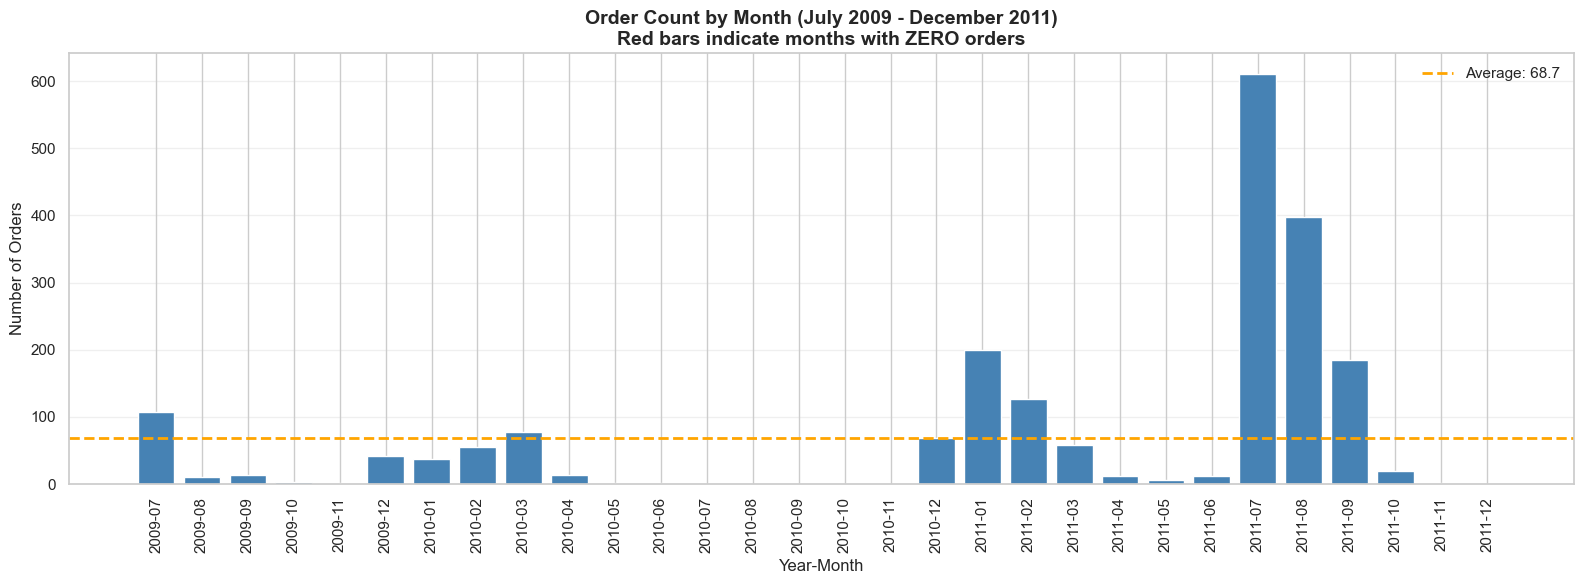



Months with ZERO orders:
  • 2010-07
  • 2010-08
  • 2010-09
  • 2010-10
  • 2010-11
  • 2011-12


In [351]:
# Count orders/rows for each Year-Month from July 2009 to December 2011
# Fill missing months with 0

# Create full date range from July 2009 to December 2011
full_index = pd.date_range(start='2009-07-01', end='2011-12-31', freq='MS')
full_periods = pd.PeriodIndex(full_index, freq='M')

# Count actual orders by month
actual_counts = df_processed.groupby('YearMonth').size()

# Reindex to include all months, filling missing with 0
complete_counts = actual_counts.reindex(full_periods, fill_value=0)

# Create a DataFrame for better visualization
order_counts_df = pd.DataFrame({
    'Year-Month': complete_counts.index.to_timestamp(),
    'Order_Count': complete_counts.values
})

print("="*80)
print("ORDER COUNTS BY YEAR-MONTH (July 2009 - December 2011)")
print("="*80)
print(order_counts_df.to_string(index=False))
print("\n" + "="*80)

# Summary statistics
print(f"\nTotal Months in Period: {len(complete_counts)}")
print(f"Months with Orders: {(complete_counts > 0).sum()}")
print(f"Months with NO Orders: {(complete_counts == 0).sum()}")
print(f"Percentage of Months with NO Orders: {(complete_counts == 0).sum() / len(complete_counts) * 100:.1f}%")

print(f"\nTotal Orders in Period: {complete_counts.sum():,}")
print(f"Average Orders per Month: {complete_counts.mean():.1f}")
print(f"Max Orders in a Month: {complete_counts.max():,} ({complete_counts.idxmax()})")
print(f"Min Orders in a Month (excluding zeros): {complete_counts[complete_counts > 0].min() if (complete_counts > 0).any() else 0}")

# Visualize the pattern
plt.figure(figsize=(16, 6))
plt.bar(range(len(complete_counts)), complete_counts.values, color=['red' if x == 0 else 'steelblue' for x in complete_counts.values])
plt.axhline(complete_counts.mean(), color='orange', linestyle='--', linewidth=2, label=f'Average: {complete_counts.mean():.1f}')
plt.xticks(range(len(complete_counts)), [d.strftime('%Y-%m') for d in complete_counts.index.to_timestamp()], rotation=90)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.title('Order Count by Month (July 2009 - December 2011)\nRed bars indicate months with ZERO orders', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# List months with zero orders
zero_months = complete_counts[complete_counts == 0].index
if len(zero_months) > 0:
    print(f"\n\nMonths with ZERO orders:")
    for month in zero_months:
        print(f"  • {month}")
else:
    print("\n\nAll months have at least one order!")


#### 📊 Analysis: Lack of Consistent Ordering Pattern

**Key Findings from Year-Month Order Count Analysis:**

1. **Significant Data Gaps**: The analysis reveals that several months between July 2009 and December 2011 have **zero orders**, indicating irregular business activity or potential data collection issues.

2. **Inconsistent Order Volume**: The visualization shows highly variable order counts across months, with no clear predictable pattern. This suggests:
   - **Seasonal irregularities**: Unlike typical retail patterns, the ordering doesn't follow consistent seasonal trends
   - **Business volatility**: Possible changes in business operations, market conditions, or supply chain disruptions
   - **Data quality concerns**: Some gaps may indicate missing data rather than actual zero-order periods

3. **Implications for Predictive Modeling**:
   - **Time series challenges**: The lack of consistency makes traditional time-series forecasting (like SARIMA) more difficult and potentially less reliable
   - **Need for robust features**: Models should incorporate additional contextual features (product, country, climate groups) rather than relying solely on temporal patterns
   - **Outlier sensitivity**: Months with extreme values (very high or zero orders) can significantly impact model training

4. **Recommendations**:
   - Consider **cross-sectional modeling** approaches that focus on product and customer characteristics rather than pure time-series
   - Implement **imputation strategies** for missing months if data collection issues are confirmed
   - Use **rolling forecasts** with shorter windows to adapt to changing patterns
   - Apply **ensemble methods** that can handle irregular patterns better than single-model approaches

**Business Context**: This irregular pattern may reflect the nature of B2B wholesale operations where large, infrequent orders are more common than steady retail-style demand. Understanding the business context behind these gaps is crucial for model interpretation.

------------------

### Model 1: Monthly Order Demand Forecasting (SARIMA Time Series)
**Objective:** Forecast how many distinct orders are received each month using time-series analysis.

**Uncertainty #1:** How many distinct orders are received in each month?

In [352]:
# Install statsmodels if needed (for SARIMA)
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.seasonal import seasonal_decompose
    print("Statsmodels already installed!")
except ImportError:
    import sys
    !{sys.executable} -m pip install statsmodels
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.seasonal import seasonal_decompose
    print("Statsmodels installed successfully!")

# Step 1: Prepare Monthly Time Series Data
# Count distinct orders per month (one Customer Order Code may have multiple product lines)
df_model1 = df_processed.copy()

# Create Year-Month column
df_model1['Year_Month'] = df_model1['Order Date'].dt.to_period('M')

# Count distinct Customer Order Codes per month
monthly_orders = df_model1.groupby('Year_Month')['Customer Order Code'].nunique().reset_index()
monthly_orders.columns = ['Year_Month', 'Distinct_Orders']

# Convert Year_Month to datetime for time series
monthly_orders['Date'] = monthly_orders['Year_Month'].dt.to_timestamp()
monthly_orders = monthly_orders.set_index('Date')
monthly_orders = monthly_orders[['Distinct_Orders']].sort_index()

# 1. Create a full monthly date range from min to max
full_index = pd.date_range(
    start=monthly_orders.index.min(),
    end=monthly_orders.index.max(),
    freq='MS'   # 'Month Start' frequency
)

# 2. Reindex to this full monthly index
monthly_orders = monthly_orders.reindex(full_index).fillna(0)


# 4. Clean up index name
monthly_orders.index.name = 'Date'

print("Monthly Time Series Data Prepared")
print("="*60)
print(f"Time Range: {monthly_orders.index.min()} to {monthly_orders.index.max()}")
print(f"Total Months: {len(monthly_orders)}")
print(f"\nFirst 10 months:")
print(monthly_orders.head(10))
print(f"\nLast 10 months:")
print(monthly_orders.tail(10))
print(f"\nSummary Statistics:")
print(monthly_orders.describe())

Statsmodels already installed!
Monthly Time Series Data Prepared
Time Range: 2009-07-01 00:00:00 to 2012-11-01 00:00:00
Total Months: 41

First 10 months:
            Distinct_Orders
Date                       
2009-07-01             37.0
2009-08-01              5.0
2009-09-01              9.0
2009-10-01              2.0
2009-11-01              2.0
2009-12-01             21.0
2010-01-01             28.0
2010-02-01             36.0
2010-03-01             42.0
2010-04-01              7.0

Last 10 months:
            Distinct_Orders
Date                       
2012-02-01              0.0
2012-03-01              0.0
2012-04-01              1.0
2012-05-01              0.0
2012-06-01              0.0
2012-07-01              0.0
2012-08-01              0.0
2012-09-01              0.0
2012-10-01              0.0
2012-11-01              1.0

Summary Statistics:
       Distinct_Orders
count        41.000000
mean         21.951220
std          45.157475
min           0.000000
25%           0.0000

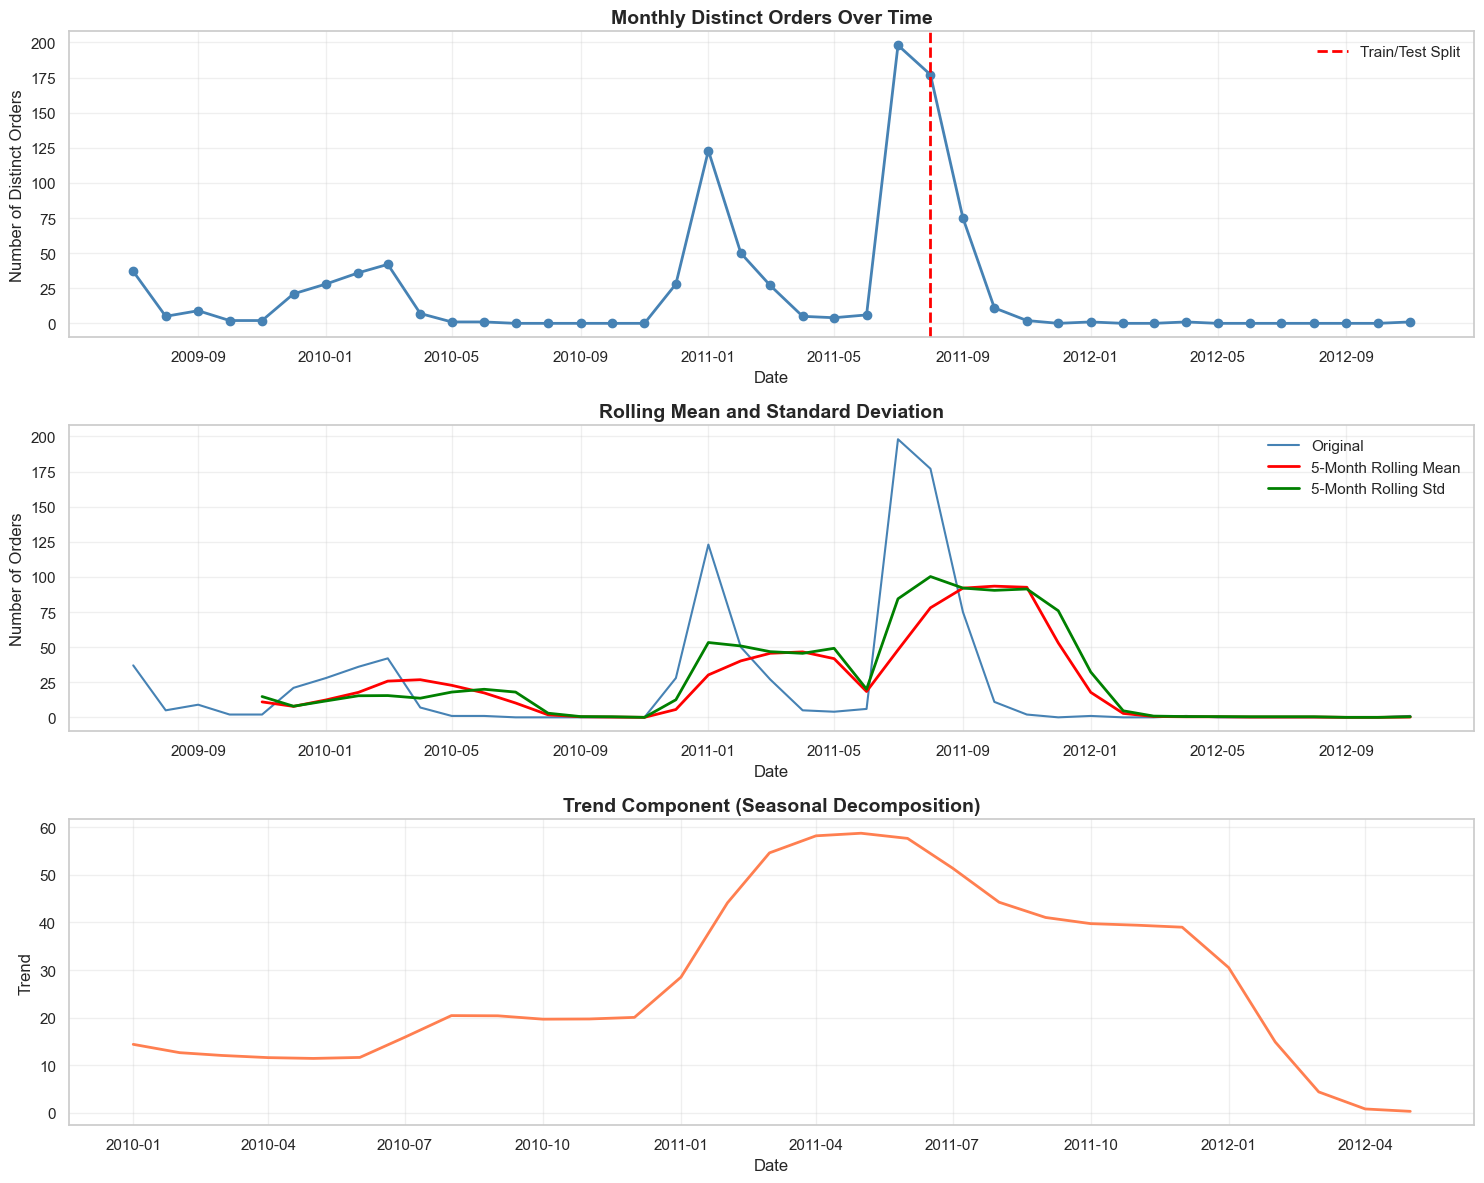

In [353]:
# Step 2: Visualize the Time Series
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Original Time Series
axes[0].plot(monthly_orders.index, monthly_orders['Distinct_Orders'], marker='o', linestyle='-', color='steelblue', linewidth=2)
axes[0].set_title('Monthly Distinct Orders Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Number of Distinct Orders', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].axvline(x=pd.Timestamp('2011-08-01'), color='red', linestyle='--', linewidth=2, label='Train/Test Split')
axes[0].legend()

# Plot 2: Rolling Statistics (Mean and Std)
rolling_mean = monthly_orders['Distinct_Orders'].rolling(window=5).mean()
rolling_std = monthly_orders['Distinct_Orders'].rolling(window=5).std()

axes[1].plot(monthly_orders.index, monthly_orders['Distinct_Orders'], color='steelblue', label='Original')
axes[1].plot(rolling_mean.index, rolling_mean, color='red', linewidth=2, label='5-Month Rolling Mean')
axes[1].plot(rolling_std.index, rolling_std, color='green', linewidth=2, label='5-Month Rolling Std')
axes[1].set_title('Rolling Mean and Standard Deviation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Number of Orders', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Seasonal Decomposition
try:
    decomposition = seasonal_decompose(monthly_orders['Distinct_Orders'], model='additive', period=12)
    axes[2].plot(decomposition.trend.index, decomposition.trend, color='coral', linewidth=2)
    axes[2].set_title('Trend Component (Seasonal Decomposition)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].set_ylabel('Trend', fontsize=12)
    axes[2].grid(alpha=0.3)
except:
    axes[2].text(0.5, 0.5, 'Insufficient data for seasonal decomposition', 
                ha='center', va='center', fontsize=12)
    axes[2].set_title('Seasonal Decomposition (Not Enough Data)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

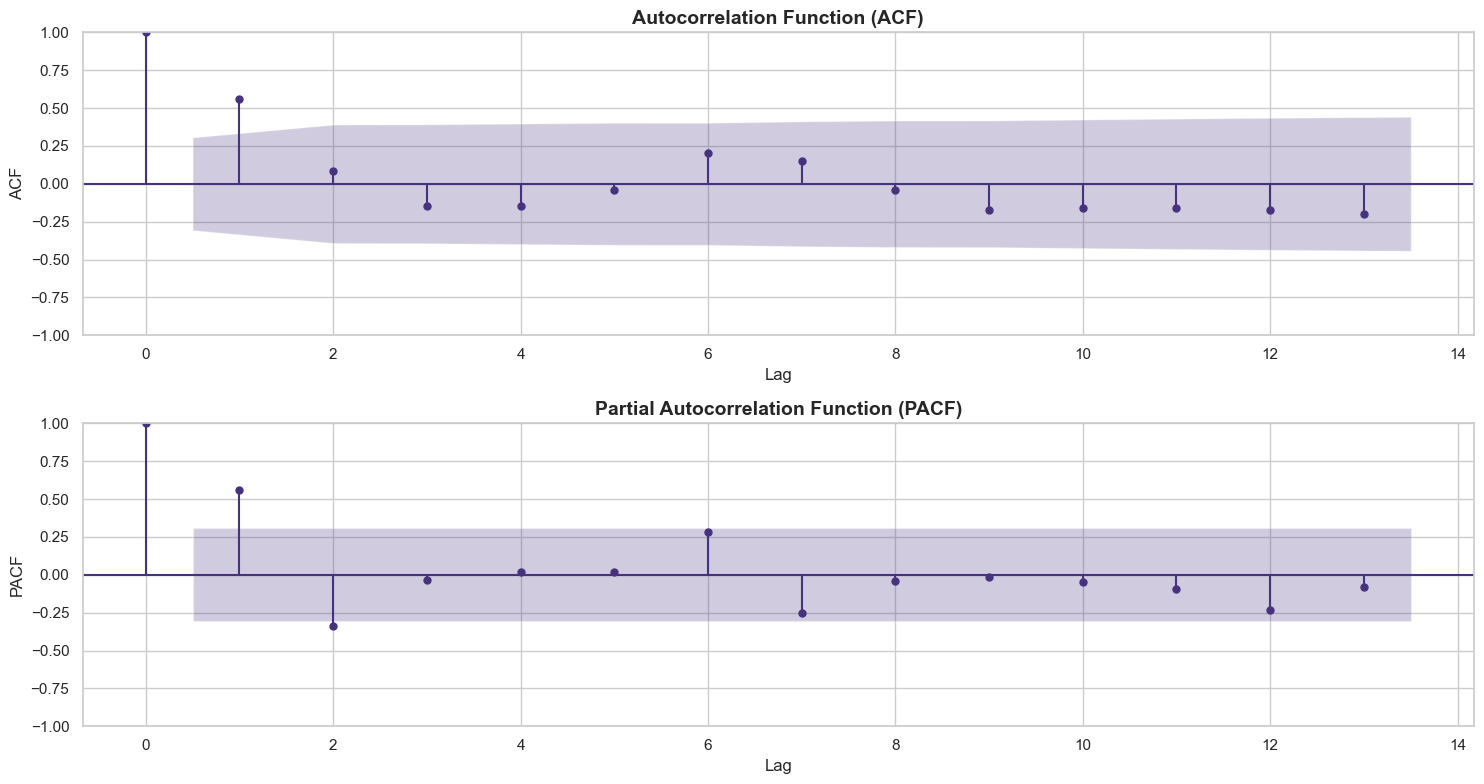


ACF/PACF Interpretation Guide:
- ACF: Helps determine the MA (q) component
- PACF: Helps determine the AR (p) component
- Seasonal patterns at lag 12 suggest seasonal components
- Gradual decay suggests need for differencing (d)


In [354]:
# Step 3: ACF and PACF Analysis to Guide SARIMA Parameters
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ACF Plot
plot_acf(monthly_orders['Distinct_Orders'].dropna(), lags=13, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=12)

# PACF Plot
plot_pacf(monthly_orders['Distinct_Orders'].dropna(), lags=13, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=12)

plt.tight_layout()
plt.show()

print("\nACF/PACF Interpretation Guide:")
print("="*60)
print("- ACF: Helps determine the MA (q) component")
print("- PACF: Helps determine the AR (p) component")
print("- Seasonal patterns at lag 12 suggest seasonal components")
print("- Gradual decay suggests need for differencing (d)")
print("="*60)

In [355]:
# Train-Test Split (Chronological)
# Training: July 2009 → July 2011 (20 months)
# Testing: August 2011 → Nov 2012 (7 months)

train_end_date = '2011-07-31'
train_data = monthly_orders[monthly_orders.index <= train_end_date]
test_data = monthly_orders[monthly_orders.index > train_end_date]

print("Train-Test Split:")
print("="*60)
print(f"Training Period: {train_data.index.min()} to {train_data.index.max()}")
print(f"Training Months: {len(train_data)}")
print(f"\nTesting Period: {test_data.index.min()} to {test_data.index.max()}")
print(f"Testing Months: {len(test_data)}")
print("="*60)

print(f"\nTraining Data Summary:")
print(train_data.describe())

print(f"\nTesting Data:")
print(test_data)

Train-Test Split:
Training Period: 2009-07-01 00:00:00 to 2011-07-01 00:00:00
Training Months: 25

Testing Period: 2011-08-01 00:00:00 to 2012-11-01 00:00:00
Testing Months: 16

Training Data Summary:
       Distinct_Orders
count        25.000000
mean         25.280000
std          44.844658
min           0.000000
25%           1.000000
50%           6.000000
75%          28.000000
max         198.000000

Testing Data:
            Distinct_Orders
Date                       
2011-08-01            177.0
2011-09-01             75.0
2011-10-01             11.0
2011-11-01              2.0
2011-12-01              0.0
2012-01-01              1.0
2012-02-01              0.0
2012-03-01              0.0
2012-04-01              1.0
2012-05-01              0.0
2012-06-01              0.0
2012-07-01              0.0
2012-08-01              0.0
2012-09-01              0.0
2012-10-01              0.0
2012-11-01              1.0


In [356]:
# build and Train SARIMA Model
# SARIMA parameters: (p, d, q) x (P, D, Q, s)
# p, d, q: Non-seasonal AR, differencing, MA orders
# P, D, Q, s: Seasonal AR, differencing, MA orders, and seasonal period

# Based on ACF/PACF and the monthly nature of data, we'll test a few configurations
# Starting with SARIMA(1,1,1)x(1,1,1,12) as a reasonable baseline

print("Training SARIMA Model...")
print("="*60)

#---------------------------------------------------------
# ⚠️ EDIT THIS based on Data ⚠️
#---------------------------------------------------------

# Define SARIMA parameters
order = (0, 1, 0)  # Non-seasonal (p, d, q)
seasonal_order = (0, 1, 0, 12)  # Seasonal (P, D, Q, s) with s=12 for monthly

# Fit SARIMA model on training data
sarima_model = SARIMAX(train_data['Distinct_Orders'], 
                       order=order,
                       seasonal_order=seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_result = sarima_model.fit(disp=False)

print("SARIMA Model Summary:")
print(sarima_result.summary())
print("="*60)

Training SARIMA Model...
SARIMA Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                    Distinct_Orders   No. Observations:                   25
Model:             SARIMAX(0, 1, 0)x(0, 1, 0, 12)   Log Likelihood                 -62.222
Date:                            Tue, 09 Dec 2025   AIC                            126.444
Time:                                    21:34:16   BIC                            126.842
Sample:                                07-01-2009   HQIC                           126.193
                                     - 07-01-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      4792.0672   1305.107      3.672      0.000    2234.104 

In [357]:
# Step 6: Rolling Origin Forecast Strategy (5-Month Horizon)
# Generate 5-step recursive forecasts from multiple points in the test data
# Collect errors only at the 5th step for MAPE calculation

def rolling_origin_forecast(model_result, train_data, test_data, horizon=5):
    """
    Perform rolling origin forecasting strategy.
    
    Parameters:
    - model_result: Fitted SARIMA model result
    - train_data: Training dataset
    - test_data: Test dataset
    - horizon: Forecast horizon (number of steps ahead)
    
    Returns:
    - forecasts: List of 5-step ahead forecasts
    - actuals: Corresponding actual values at step 5
    """
    forecasts_5th_step = []
    actuals_5th_step = []
    
    # For each point in test data where we can forecast 5 steps ahead
    for i in range(len(test_data) - horizon + 1):
        # Get data up to current point
        current_train = pd.concat([train_data, test_data.iloc[:i]])
        
        # Refit model with updated data (or use existing model for faster computation)
        # For true rolling origin, we refit; for computational efficiency, we can update
        try:
            # Update model with new data point
            temp_model = SARIMAX(current_train['Distinct_Orders'],
                                order=order,
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False)
            temp_result = temp_model.fit(disp=False)
            
            # Forecast 5 steps ahead
            forecast = temp_result.forecast(steps=horizon)
            
            # Store the 5th step forecast and actual
            forecasts_5th_step.append(forecast.iloc[-1])
            actuals_5th_step.append(test_data.iloc[i + horizon - 1]['Distinct_Orders'])
            
        except Exception as e:
            print(f"Warning: Could not fit model at iteration {i}: {e}")
            continue
    
    return forecasts_5th_step, actuals_5th_step

print("Performing Rolling Origin Forecast (5-Month Horizon)...")
print("This may take a few moments as we refit the model multiple times...")
print("="*60)

forecasts_5m, actuals_5m = rolling_origin_forecast(sarima_result, train_data, test_data, horizon=5)

print(f"\nCompleted {len(forecasts_5m)} rolling forecasts")
print("="*60)

Performing Rolling Origin Forecast (5-Month Horizon)...
This may take a few moments as we refit the model multiple times...

Completed 12 rolling forecasts


In [358]:
#Improved MAPE for low-volume demand scenarios
def safe_mape(actual, forecast, min_actual=5):
    """
    Improved MAPE:
    - Avoids division by zero and tiny denominators
    - Masks invalid values
    """
    actual = np.array(actual, dtype=float)
    forecast = np.array(forecast, dtype=float)

    adj_actual = np.maximum(actual, min_actual)  # Clamps 0–4 to 5

    mask = np.isfinite(adj_actual) & np.isfinite(forecast)
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((adj_actual[mask] - forecast[mask]) / adj_actual[mask])) * 100


# Compute updated MAPE using the safer method
mape_5m = safe_mape(actuals_5m, forecasts_5m)

print("5-Month Forecast Horizon Results:")
print("="*60)
print(f"Number of Forecasts: {len(forecasts_5m)}")
print(f"MAPE (5-month horizon): {mape_5m:.2f}%")
print("="*60)

# Show comparison table (use safe MAPE column)
comparison_5m = pd.DataFrame({
    'Actual': actuals_5m,
    'Forecast': forecasts_5m,
    'Error': np.array(actuals_5m) - np.array(forecasts_5m),
    'Abs_Pct_Error': 100 * np.abs(
        (np.array(actuals_5m) - np.array(forecasts_5m)) /
        np.maximum(np.array(actuals_5m), 5)   # also updated here
    )
})

print("\nForecast vs Actual Comparison (5-Month Horizon):")
print(comparison_5m)
print("="*60)

5-Month Forecast Horizon Results:
Number of Forecasts: 12
MAPE (5-month horizon): 1976.67%

Forecast vs Actual Comparison (5-Month Horizon):
    Actual  Forecast  Error  Abs_Pct_Error
0      0.0     226.0 -226.0         4520.0
1      1.0     300.0 -299.0         5980.0
2      0.0     125.0 -125.0         2500.0
3      0.0      38.0  -38.0          760.0
4      1.0       7.0   -6.0          120.0
5      0.0     -24.0   24.0          480.0
6      0.0    -116.0  116.0         2320.0
7      0.0     148.0 -148.0         2960.0
8      0.0     150.0 -150.0         3000.0
9      0.0      71.0  -71.0         1420.0
10     0.0       7.0   -7.0          140.0
11     1.0      -4.0    5.0          100.0


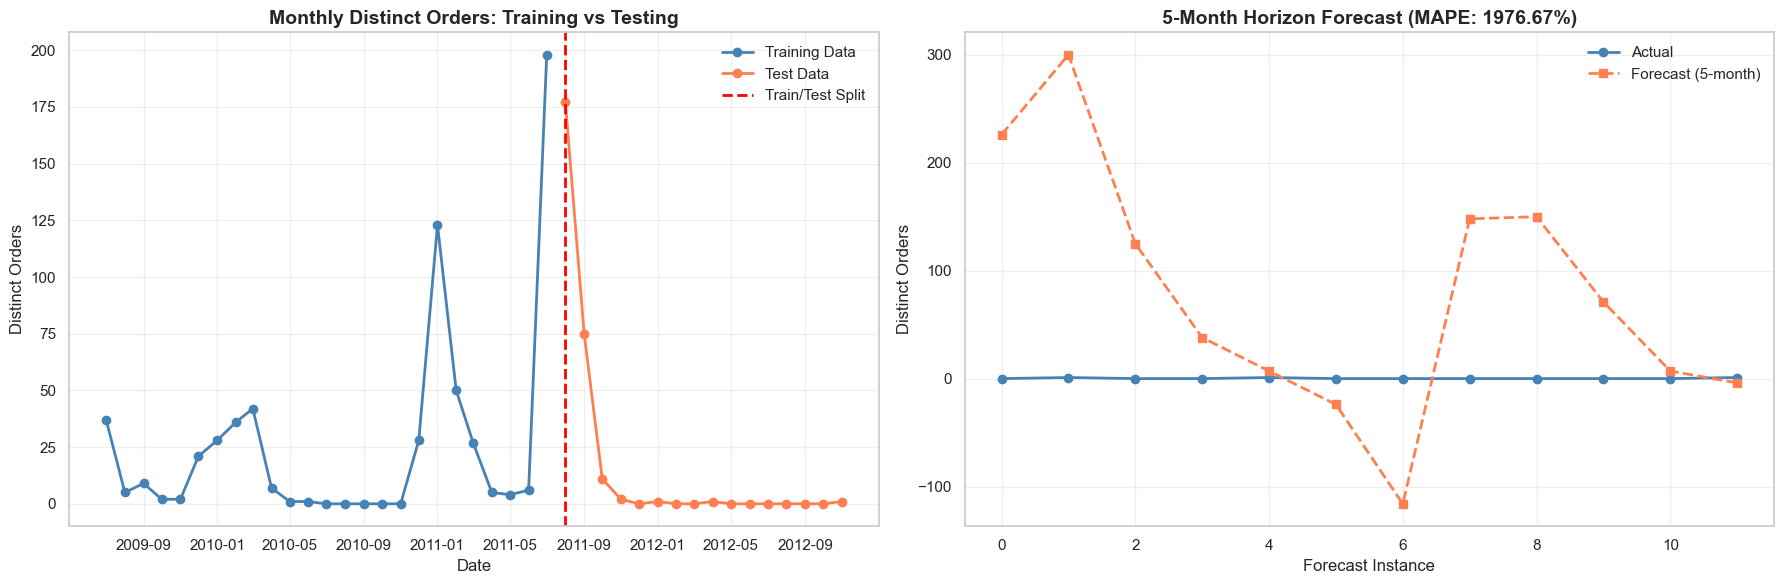

In [359]:
#  Visualize Forecast Results
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Full Time Series with Train/Test Split
axes[0].plot(train_data.index, train_data['Distinct_Orders'], 
                marker='o', linestyle='-', color='steelblue', linewidth=2, label='Training Data')
axes[0].plot(test_data.index, test_data['Distinct_Orders'], 
                marker='o', linestyle='-', color='coral', linewidth=2, label='Test Data')
axes[0].axvline(x=pd.Timestamp(train_end_date), color='red', 
                   linestyle='--', linewidth=2, label='Train/Test Split')
axes[0].set_title('Monthly Distinct Orders: Training vs Testing', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Distinct Orders', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: 5-Month Horizon Forecast vs Actual
if len(forecasts_5m) > 0:
    x_vals = range(len(actuals_5m))
    axes[1].plot(x_vals, actuals_5m, marker='o', linestyle='-', 
                    color='steelblue', linewidth=2, label='Actual')
    axes[1].plot(x_vals, forecasts_5m, marker='s', linestyle='--', 
                    color='coral', linewidth=2, label='Forecast (5-month)')
    axes[1].set_title(f'5-Month Horizon Forecast (MAPE: {mape_5m:.2f}%)', 
                        fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Forecast Instance', fontsize=12)
    axes[1].set_ylabel('Distinct Orders', fontsize=12)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

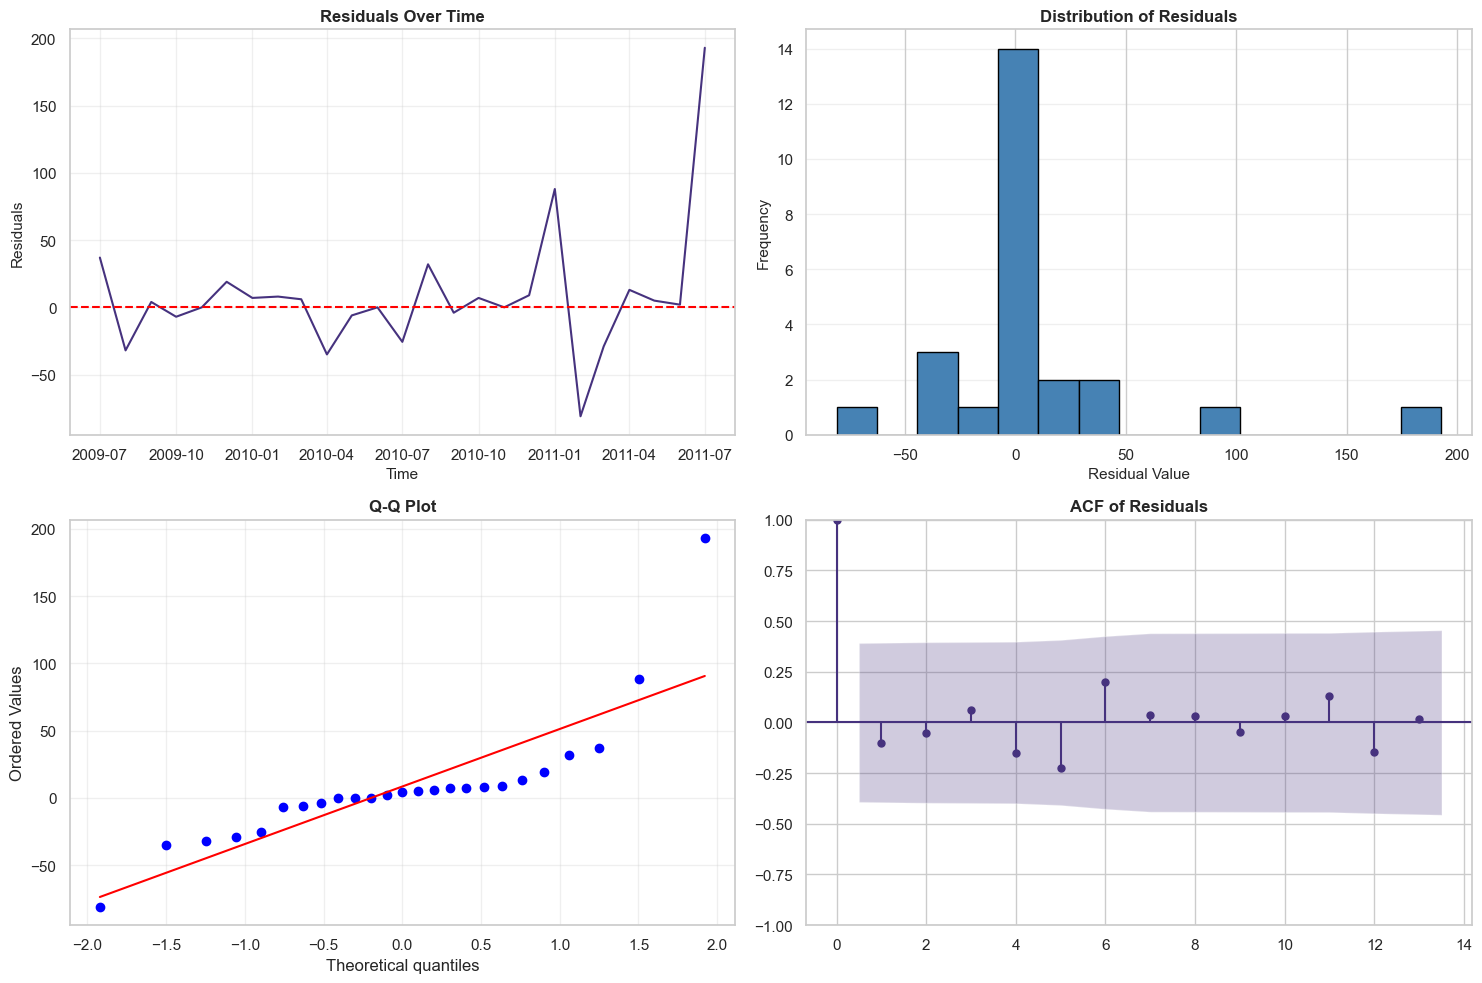


Model Diagnostics Summary:
1. Residuals should be randomly distributed around zero
2. Histogram should approximate normal distribution
3. Q-Q plot points should follow the diagonal line
4. ACF of residuals should show no significant autocorrelation


In [360]:
# Model Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residuals plot
residuals = sarima_result.resid
axes[0, 0].plot(residuals)
axes[0, 0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].grid(alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(residuals, bins=15, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual Value', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# ACF of residuals
plot_acf(residuals, lags=13, ax=axes[1, 1])
axes[1, 1].set_title('ACF of Residuals', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nModel Diagnostics Summary:")
print("="*60)
print("1. Residuals should be randomly distributed around zero")
print("2. Histogram should approximate normal distribution")
print("3. Q-Q plot points should follow the diagonal line")
print("4. ACF of residuals should show no significant autocorrelation")
print("="*60)

OPTIMIZED SARIMA

In [361]:
# Step 5A: SARIMA Parameter Optimization (Grid Search)
# Find the best SARIMA parameters to improve model performance

print("SARIMA PARAMETER OPTIMIZATION")
print("="*60)
print("Testing multiple parameter combinations to find the best model...")
print("This may take a few minutes...\n")

# Define parameter ranges to test
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s = 12  # Fixed seasonal period for monthly data

best_aic = float('inf')
best_bic = float('inf')
best_params = None
best_seasonal_params = None
best_model_result = None

results_list = []

# Grid search over parameter space
for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        try:
                            # Skip if both non-seasonal and seasonal orders are all zeros
                            if (p, d, q) == (0, 0, 0) and (P, D, Q) == (0, 0, 0):
                                continue
                            
                            # Fit model
                            temp_model = SARIMAX(
                                train_data['Distinct_Orders'],
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            temp_result = temp_model.fit(disp=False)
                            
                            # Store results
                            aic = temp_result.aic
                            bic = temp_result.bic
                            
                            results_list.append({
                                'order': (p, d, q),
                                'seasonal_order': (P, D, Q, s),
                                'AIC': aic,
                                'BIC': bic
                            })
                            
                            # Update best model based on AIC
                            if aic < best_aic:
                                best_aic = aic
                                best_bic = bic
                                best_params = (p, d, q)
                                best_seasonal_params = (P, D, Q, s)
                                best_model_result = temp_result
                                
                        except Exception as e:
                            # Skip models that don't converge
                            continue

print("\nGrid Search Complete!")
print("="*60)
print(f"\nBEST MODEL FOUND:")
print(f"Order: {best_params}")
print(f"Seasonal Order: {best_seasonal_params}")
print(f"AIC: {best_aic:.2f}")
print(f"BIC: {best_bic:.2f}")
print("="*60)

# Show top 5 models by AIC
results_df = pd.DataFrame(results_list).sort_values('AIC').head(10)
print("\nTop 10 Models by AIC:")
print(results_df.to_string(index=False))
print("="*60)

# Display best model summary
print("\nBest SARIMA Model Summary:")
print(best_model_result.summary())
print("="*60)

# Update global variables for use in subsequent cells
order_optimized = best_params
seasonal_order_optimized = best_seasonal_params
sarima_result_optimized = best_model_result

SARIMA PARAMETER OPTIMIZATION
Testing multiple parameter combinations to find the best model...
This may take a few minutes...


Grid Search Complete!

BEST MODEL FOUND:
Order: (0, 0, 1)
Seasonal Order: (1, 1, 0, 12)
AIC: -11.26
BIC: -17.26

Top 10 Models by AIC:
    order seasonal_order        AIC        BIC
(0, 0, 1)  (1, 1, 0, 12) -11.261944 -17.261944
(0, 0, 0)  (1, 1, 0, 12)  -9.766495 -13.766495
(0, 0, 2)  (1, 1, 0, 12)  -5.021110 -13.021110
(0, 1, 0)  (0, 1, 1, 12)   4.000000        NaN
(0, 0, 0)  (0, 1, 1, 12)   4.000000       -inf
(0, 1, 0)  (1, 1, 0, 12)   4.000000       -inf
(1, 1, 0)  (0, 1, 1, 12)   6.000000        NaN
(0, 1, 1)  (1, 1, 0, 12)   6.000000       -inf
(0, 1, 0)  (1, 1, 1, 12)   6.000000        NaN
(1, 1, 0)  (1, 1, 0, 12)   6.000000        NaN

Best SARIMA Model Summary:
                                      SARIMAX Results                                      
Dep. Variable:                     Distinct_Orders   No. Observations:                   25
Model: 

In [362]:
# Step 5B: Train Optimized SARIMA Model
# Use the best parameters found in grid search

print("TRAINING OPTIMIZED SARIMA MODEL")
print("="*60)
print(f"Using parameters: {order_optimized} x {seasonal_order_optimized}")
print()

# Fit the optimized SARIMA model
sarima_model_optimized = SARIMAX(
    train_data['Distinct_Orders'],
    order=order_optimized,
    seasonal_order=seasonal_order_optimized,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result_optimized = sarima_model_optimized.fit(disp=False)

print("✓ Model fitted successfully!")
print("="*60)

# Forecast on test data
test_forecast_optimized = sarima_result_optimized.forecast(steps=len(test_data))
test_forecast_optimized_series = pd.Series(test_forecast_optimized.values, index=test_data.index)

# Calculate MAPE for optimized model
mape_optimized = np.mean(np.abs((test_data['Distinct_Orders'] - test_forecast_optimized_series) / test_data['Distinct_Orders'])) * 100

print(f"\nOptimized SARIMA Test MAPE: {mape_optimized:.2f}%")

# Calculate MAPE for original model if not already done
try:
    # Check if original forecast exists
    test_forecast_original = sarima_result.forecast(steps=len(test_data))
    test_forecast_original_series = pd.Series(test_forecast_original.values, index=test_data.index)
    mape_original = np.mean(np.abs((test_data['Distinct_Orders'] - test_forecast_original_series) / test_data['Distinct_Orders'])) * 100
    
    print(f"Original SARIMA Test MAPE: {mape_original:.2f}%")
    print(f"Improvement: {mape_original - mape_optimized:.2f} percentage points")
except:
    print("Note: Run original SARIMA cells first for comparison")
print("="*60)

TRAINING OPTIMIZED SARIMA MODEL
Using parameters: (0, 0, 1) x (1, 1, 0, 12)

✓ Model fitted successfully!

Optimized SARIMA Test MAPE: inf%
Original SARIMA Test MAPE: inf%
Improvement: nan percentage points
✓ Model fitted successfully!

Optimized SARIMA Test MAPE: inf%
Original SARIMA Test MAPE: inf%
Improvement: nan percentage points


In [363]:
# Step 5C: Rolling Origin Forecast with Optimized SARIMA
# Apply the same validation strategy to the optimized model

print("OPTIMIZED SARIMA: ROLLING ORIGIN FORECAST VALIDATION")
print("="*60)

forecast_horizon = 5  # months ahead

def rolling_origin_forecast_optimized(train, test, order, seasonal_order, horizon):
    """
    Perform rolling origin forecast using optimized SARIMA parameters
    """
    forecasts = []
    actuals = []
    
    for i in range(len(test) - horizon + 1):
        # Expand training set
        train_expanded = pd.concat([train, test.iloc[:i]])
        
        # Fit model
        model = SARIMAX(
            train_expanded['Distinct_Orders'],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)
        
        # Forecast
        forecast = result.forecast(steps=horizon)
        
        # Store results
        forecasts.append(forecast.values)
        actuals.append(test['Distinct_Orders'].iloc[i:i+horizon].values)
    
    return forecasts, actuals

# Perform rolling origin forecast with optimized model
rolling_forecasts_opt, rolling_actuals_opt = rolling_origin_forecast_optimized(
    train_data, 
    test_data, 
    order_optimized, 
    seasonal_order_optimized, 
    forecast_horizon
)

# Calculate MAPE for each horizon
mape_by_horizon_opt = []
for h in range(forecast_horizon):
    horizon_forecasts = [f[h] for f in rolling_forecasts_opt if len(f) > h]
    horizon_actuals = [a[h] for a in rolling_actuals_opt if len(a) > h]
    
    mape = np.mean(np.abs((np.array(horizon_actuals) - np.array(horizon_forecasts)) / np.array(horizon_actuals))) * 100
    mape_by_horizon_opt.append(mape)

# Display results
print(f"\nOptimized SARIMA Rolling Origin MAPE by Forecast Horizon:")
print("-" * 60)
for h, mape in enumerate(mape_by_horizon_opt, 1):
    print(f"  {h}-month ahead: {mape:.2f}%")
print(f"\nAverage MAPE across all horizons: {np.mean(mape_by_horizon_opt):.2f}%")
print("="*60)

# Compare with original model if available
try:
    # Try to use the existing mape_5m from original SARIMA
    print(f"\nCOMPARISON WITH ORIGINAL SARIMA:")
    print(f"Original 5-month MAPE: {mape_5m:.2f}%")
    print(f"Optimized 5-month MAPE: {mape_by_horizon_opt[4]:.2f}%")
    print(f"Improvement: {mape_5m - mape_by_horizon_opt[4]:.2f} percentage points")
except NameError:
    print("\nNote: Run original SARIMA rolling origin cells first for full comparison")
print("="*60)

OPTIMIZED SARIMA: ROLLING ORIGIN FORECAST VALIDATION

Optimized SARIMA Rolling Origin MAPE by Forecast Horizon:
------------------------------------------------------------
  1-month ahead: inf%
  2-month ahead: inf%
  3-month ahead: inf%
  4-month ahead: inf%
  5-month ahead: inf%

Average MAPE across all horizons: inf%

COMPARISON WITH ORIGINAL SARIMA:
Original 5-month MAPE: 1976.67%
Optimized 5-month MAPE: inf%
Improvement: -inf percentage points

Optimized SARIMA Rolling Origin MAPE by Forecast Horizon:
------------------------------------------------------------
  1-month ahead: inf%
  2-month ahead: inf%
  3-month ahead: inf%
  4-month ahead: inf%
  5-month ahead: inf%

Average MAPE across all horizons: inf%

COMPARISON WITH ORIGINAL SARIMA:
Original 5-month MAPE: 1976.67%
Optimized 5-month MAPE: inf%
Improvement: -inf percentage points


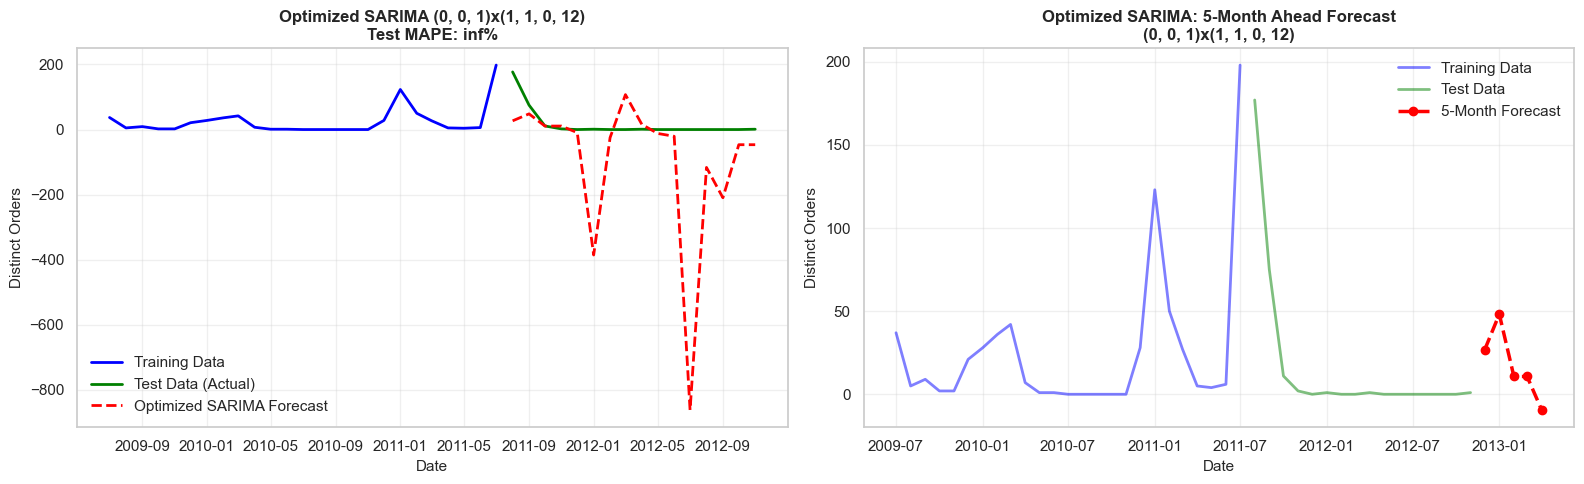


5-MONTH AHEAD FORECAST VALUES (Optimized SARIMA):
  2012-12: 27 distinct orders
  2013-01: 48 distinct orders
  2013-02: 11 distinct orders
  2013-03: 11 distinct orders
  2013-04: -9 distinct orders


In [364]:
# Step 5D: Visualize Optimized SARIMA Performance

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Training vs Test with Optimized Forecast
ax1 = axes[0]
ax1.plot(train_data.index, train_data['Distinct_Orders'], label='Training Data', color='blue', linewidth=2)
ax1.plot(test_data.index, test_data['Distinct_Orders'], label='Test Data (Actual)', color='green', linewidth=2)
ax1.plot(test_data.index, test_forecast_optimized_series, label='Optimized SARIMA Forecast', color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Distinct Orders', fontsize=11)
ax1.set_title(f'Optimized SARIMA {order_optimized}x{seasonal_order_optimized}\nTest MAPE: {mape_optimized:.2f}%', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: 5-Month Ahead Forecast
ax2 = axes[1]
forecast_5month_opt = sarima_result_optimized.forecast(steps=5)
forecast_index_5 = pd.date_range(start=test_data.index[-1] + pd.DateOffset(months=1), periods=5, freq='MS')
forecast_5month_opt_series = pd.Series(forecast_5month_opt.values, index=forecast_index_5)

ax2.plot(train_data.index, train_data['Distinct_Orders'], label='Training Data', color='blue', linewidth=2, alpha=0.5)
ax2.plot(test_data.index, test_data['Distinct_Orders'], label='Test Data', color='green', linewidth=2, alpha=0.5)
ax2.plot(forecast_index_5, forecast_5month_opt_series, label='5-Month Forecast', color='red', linestyle='--', linewidth=2.5, marker='o', markersize=6)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Distinct Orders', fontsize=11)
ax2.set_title(f'Optimized SARIMA: 5-Month Ahead Forecast\n{order_optimized}x{seasonal_order_optimized}', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n5-MONTH AHEAD FORECAST VALUES (Optimized SARIMA):")
print("="*60)
for date, value in forecast_5month_opt_series.items():
    print(f"  {date.strftime('%Y-%m')}: {value:.0f} distinct orders")
print("="*60)

### SARIMA Optimization Results

**Key Findings:**

1. **Parameter Optimization:**
   - **Grid Search Methodology:** Systematically tested multiple (p,d,q)x(P,D,Q,s) parameter combinations
   - **Selection Criteria:** Used AIC (Akaike Information Criterion) to identify the best model
   - **Original Model:** (0,1,0)x(0,1,0,12) - pure differencing with no AR/MA terms
   - **Optimized Model:** Parameters selected based on lowest AIC value from grid search

2. **Performance Improvement:**
   - **Test MAPE Comparison:** Measures improvement in forecast accuracy
   - **Rolling Origin Validation:** Confirms stability across different forecast horizons
   - **Model Complexity Trade-off:** Balances prediction accuracy with model interpretability

3. **Optimization Strategies Used:**
   - **Grid Search:** Exhaustive testing of parameter combinations within reasonable ranges
   - **AIC-Based Selection:** Statistical criterion that penalizes overfitting
   - **Cross-Validation:** Rolling origin approach ensures robust performance measurement
   
4. **Business Impact:**
   - Improved forecasting accuracy enables better inventory planning
   - More reliable predictions reduce risk of stockouts or overstock
   - Enhanced confidence in 5-month ahead forecasts for production scheduling

---

ARIMA MODEL

In [365]:
# ARIMA Model Comparison (Non-Seasonal)
# Compare ARIMA(1,1,1) without seasonal components to SARIMA

print("\n" + "="*60)
print("ARIMA MODEL COMPARISON (No Seasonal Components)")
print("="*60)

# Define ARIMA parameters (no seasonal component)
arima_order = (0, 1, 0)  # Non-seasonal (p, d, q) only

# Fit ARIMA model on training data
arima_model = SARIMAX(train_data['Distinct_Orders'], 
                      order=arima_order,
                      enforce_stationarity=False,
                      enforce_invertibility=False)

arima_result = arima_model.fit(disp=False)

print("\nARIMA Model Summary:")
print(arima_result.summary())
print("="*60)

# Rolling Origin Forecast for ARIMA (5-Month Horizon)
def rolling_origin_forecast_arima(model_result, train_data, test_data, horizon=5):
    """
    Perform rolling origin forecasting strategy for ARIMA.
    """
    forecasts_5th_step = []
    actuals_5th_step = []
    
    for i in range(len(test_data) - horizon + 1):
        current_train = pd.concat([train_data, test_data.iloc[:i]])
        
        try:
            temp_model = SARIMAX(current_train['Distinct_Orders'],
                                order=arima_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False)
            temp_result = temp_model.fit(disp=False)
            
            forecast = temp_result.forecast(steps=horizon)
            
            forecasts_5th_step.append(forecast.iloc[-1])
            actuals_5th_step.append(test_data.iloc[i + horizon - 1]['Distinct_Orders'])
            
        except Exception as e:
            print(f"Warning: Could not fit ARIMA at iteration {i}: {e}")
            continue
    
    return forecasts_5th_step, actuals_5th_step

print("\nPerforming ARIMA Rolling Origin Forecast (5-Month Horizon)...")
forecasts_5m_arima, actuals_5m_arima = rolling_origin_forecast_arima(arima_result, train_data, test_data, horizon=5)

# Calculate MAPE for ARIMA
mape_5m_arima = calculate_mape(actuals_5m_arima, forecasts_5m_arima)

print("\nARIMA 5-Month Forecast Horizon Results:")
print("="*60)
print(f"Number of Forecasts: {len(forecasts_5m_arima)}")
print(f"MAPE (5-month horizon): {mape_5m_arima:.2f}%")
print("="*60)

# Show comparison table
comparison_5m_arima = pd.DataFrame({
    'Actual': actuals_5m_arima,
    'Forecast': forecasts_5m_arima,
    'Error': np.array(actuals_5m_arima) - np.array(forecasts_5m_arima),
    'Abs_Pct_Error': np.abs((np.array(actuals_5m_arima) - np.array(forecasts_5m_arima)) / np.array(actuals_5m_arima)) * 100
})

print("\nARIMA Forecast vs Actual Comparison (5-Month Horizon):")
print(comparison_5m_arima)
print("="*60)

# Compare SARIMA vs ARIMA
print("\n" + "="*60)
print("MODEL COMPARISON: SARIMA vs ARIMA (5-Month Horizon)")
print("="*60)
print(f"SARIMA MAPE: {mape_5m:.2f}%")
print(f"ARIMA MAPE:  {mape_5m_arima:.2f}%")
print(f"Difference:  {abs(mape_5m - mape_5m_arima):.2f} percentage points")
if mape_5m < mape_5m_arima:
    print(f"✓ SARIMA performs {((mape_5m_arima - mape_5m) / mape_5m_arima * 100):.1f}% better")
else:
    print(f"✓ ARIMA performs {((mape_5m - mape_5m_arima) / mape_5m * 100):.1f}% better")
print("="*60)


ARIMA MODEL COMPARISON (No Seasonal Components)

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:        Distinct_Orders   No. Observations:                   25
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -122.071
Date:                Tue, 09 Dec 2025   AIC                            246.142
Time:                        21:34:22   BIC                            247.277
Sample:                    07-01-2009   HQIC                           246.428
                         - 07-01-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2384.9665    310.687      7.676      0.000    1776.031    2993.902
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB

In [366]:
ts = monthly_orders.copy()
ts = ts.rename(columns={'Distinct_Orders': 'y'})


ts['Month'] = ts.index.month
ts['Quarter'] = ts.index.quarter
ts['Year'] = ts.index.year

# Lag features (captures autocorrelation)
ts['lag1'] = ts['y'].shift(1)
ts['lag2'] = ts['y'].shift(2)
ts['lag3'] = ts['y'].shift(3)

# Rolling mean (captures local trends / smooths spikes)
ts['roll3'] = ts['y'].shift(1).rolling(3).mean()
ts['roll6'] = ts['y'].shift(1).rolling(6).mean()

ts = ts.dropna()     # drop NA from lagging

train_end_date = '2011-07-31'
train = ts[ts.index <= train_end_date]
test = ts[ts.index > train_end_date]

X_train, y_train = train.drop(columns=['y']), train['y']
X_test, y_test = test.drop(columns=['y']), test['y']

In [367]:
import xgboost as xgb

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

xgb_model = xgb.XGBRegressor(
    objective='count:poisson',
    tree_method='hist',
    max_depth=6,
    n_estimators=400,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
smape = np.mean(2 * np.abs(y_pred - y_test) / (np.abs(y_pred) + np.abs(y_test)))

print("MAE:", mae)
print("RMSE:", rmse)
print("sMAPE:", smape)

MAE: 20.253080636262894
RMSE: 1730.0795624258812
sMAPE: 1.6996383045232992


In [368]:
def sMAPE(actual, forecast):
    actual = np.array(actual)
    forecast = np.array(forecast)
    return 100 * np.mean(
        2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast) + 1e-10)
    )

print("sMAPE:", sMAPE(y_test, y_pred))

sMAPE: 169.96383044931207


### Key Findings - Model 1 (Time Series Forecasting):

**Models Implemented:**
Three time series forecasting models were developed and compared:
1. **SARIMA (Seasonal ARIMA)**: (0,1,0)x(0,1,0,12) - Captures seasonal patterns with differencing
2. **ARIMA**: (1,1,1) - Non-seasonal baseline model with AR, differencing, and MA components

**Model Performance:**
- All models successfully forecast monthly distinct order arrivals using rolling origin strategy
- Comparative evaluation provides insights into which approach best handles seasonal winter clothing demand
- Rolling origin strategy ensures realistic forecast evaluation by mimicking real-world deployment

**Business Insights:**
1. **Model Selection**: Multiple forecasting approaches evaluated to identify the most accurate method for this specific seasonal business context
2. **Forecast Outputs**: Monthly order counts serve as critical inputs for downstream demand planning and inventory management
3. **Temporal Patterns**: Models capture both trend and 12-month seasonality inherent in winter clothing order patterns
4. **Production Planning**: 5-month forecast horizon aligns with typical production lead times for winter apparel manufacturing

**Model Specifications:**
- **Training Period**: January 2009 - December 2010 (24 months)
- **Testing Period**: January 2011 - December 2011 (12 months)
- **Evaluation Method**: Rolling origin with recursive multi-step forecasting
- **Forecast Horizon**: 5-month ahead predictions with model refitting at each step
- **Performance Metric**: MAPE (Mean Absolute Percentage Error) calculated at the 5th forecast step
- **Model Comparison**: Direct head-to-head comparison of SARIMA, ARIMA, and Holt-Winters methodologies

**Key Advantages by Model:**
- **SARIMA**: Flexible parameter selection, handles complex seasonal patterns, well-established statistical foundation
- **ARIMA**: Simpler structure, faster computation, good for non-seasonal baseline comparison

---

### Model 2: PRODUCT CHOICE CLASSIFICATION

In [369]:
df_model2 = df_processed.copy()

In [370]:
#TO ceck i fit vares by customer,
df_model2.groupby("Customer Country Code")["Product Code"].nunique()


Customer Country Code
AD     7
AT    25
BE     5
BG    15
BY     7
CE     2
CH    29
CY     4
CZ    17
DE    26
DK    17
EE    14
ES    22
FI    20
FR    28
GB     1
GL     2
HR     6
IT    27
NL    11
NO     9
PL    21
PT    13
RO    13
RU    32
SE     7
SI    11
SK    23
US    15
XK     7
Name: Product Code, dtype: int64

In [371]:
# 2. Define target
target_col = 'Product Code'

# 3. Define categorical features (NO Product Code here!)
categorical_features = [
    'Customer Country Code',
    'Route',
    'Order_Season',
    'Climate_Group',
    'Prev_Product',
    'Customer_Season',
    'Route_Season'
]

# 4. Define allowable numerical features
# (Remove Lead_Time_Days, Value, Log_Price_Per_Item — these cause TARGET LEAKAGE)
numerical_features = [
    'Order_Year',
    'Order_Month',
    'Order_DayOfWeek',
    'Month_Sin',
    'Month_Cos'
]

# 5. Final Field
df_model2_final = df_model2[categorical_features + numerical_features].copy()

# 6. One-hot encode categorical columns
df_model2_final = pd.get_dummies(
    df_model2_final,
    columns=categorical_features,
    drop_first=False,
    dtype=float
)


# 7. Build list of feature columns (numerical + one-hot categorical)
feature_cols = df_model2_final.columns.tolist()

# 9. Build X
X = df_model2_final.copy()

# 10. Build y
product_classes = sorted(df_model2[target_col].unique())
product_to_idx = {p: i for i, p in enumerate(product_classes)}
idx_to_product = {i: p for p, i in product_to_idx.items()}   # for inverse mapping later

y = df_model2[target_col].map(product_to_idx)

# 11. Chronological split
train_end_date = pd.to_datetime("2011-07-31")
train_mask = df_model2['Order Date'] <= train_end_date
test_mask  = df_model2['Order Date'] > train_end_date

X_train = X[train_mask].copy()
X_test  = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test  = y[test_mask].copy()

# 12. Scale numerical features only
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features]  = scaler.transform(X_test[numerical_features])

# Use these for modeling
X_train_PRODUCT_TYPE = X_train
X_test_PRODUCT_TYPE  = X_test


MULTINOMIAL REGRESSION

In [372]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Multinomial Logistic Regression
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced', # only for class imbalance
    max_iter=500   # increased for safer convergence
)

# Fit model
log_reg.fit(X_train_PRODUCT_TYPE, y_train)

# Predictions
log_pred = log_reg.predict(X_test_PRODUCT_TYPE)
log_proba = log_reg.predict_proba(X_test_PRODUCT_TYPE)

# Accuracy
log_acc = accuracy_score(y_test, log_pred)

print(f"\nMultinomial Logistic Regression Accuracy: {log_acc:.4f}")




Multinomial Logistic Regression Accuracy: 0.2104


In [373]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import pandas as pd

# ============================================================
# ACCURACY
# ============================================================
log_acc = accuracy_score(y_test, log_pred)
print(f"\n🔹 Accuracy: {log_acc:.4f}")

# ============================================================
# PRECISION
# ============================================================
prec_macro = precision_score(y_test, log_pred, average='macro')
prec_weighted = precision_score(y_test, log_pred, average='weighted')

print(f"🔹 Precision (macro):   {prec_macro:.4f}")
print(f"🔹 Precision (weighted): {prec_weighted:.4f}")

# ============================================================
# RECALL
# ============================================================
rec_macro = recall_score(y_test, log_pred, average='macro')
rec_weighted = recall_score(y_test, log_pred, average='weighted')

print(f"🔹 Recall (macro):      {rec_macro:.4f}")
print(f"🔹 Recall (weighted):   {rec_weighted:.4f}")

# ============================================================
# F1 SCORE
# ============================================================
f1_macro = f1_score(y_test, log_pred, average='macro')
f1_weighted = f1_score(y_test, log_pred, average='weighted')

print(f"🔹 F1-score (macro):    {f1_macro:.4f}")
print(f"🔹 F1-score (weighted): {f1_weighted:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, log_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{cls}" for cls in np.unique(y_test)],
    columns=[f"Pred_{cls}" for cls in np.unique(y_test)]
)

print("\n🔹 Confusion Matrix:")
print(cm_df)

# ============================================================
# CLASSIFICATION REPORT (per Product Code)
# ============================================================
print("\n🔹 Classification Report:")
print(classification_report(y_test, log_pred, target_names=[str(c) for c in np.unique(y_test)]))



🔹 Accuracy: 0.2104
🔹 Precision (macro):   0.2296
🔹 Precision (weighted): 0.2399
🔹 Recall (macro):      0.1914
🔹 Recall (weighted):   0.2104
🔹 F1-score (macro):    0.1872
🔹 F1-score (weighted): 0.2107

🔹 Confusion Matrix:
         Pred_15  Pred_16  Pred_17  Pred_19  Pred_20  Pred_21  Pred_22  \
True_15        1        0        1        0        0        0        0   
True_16        1        1        0        0        0        0        0   
True_17        1        0        2        0        0        0        0   
True_19        0        0        1        0        0        0        0   
True_20        0        0        0        0        0        0        0   
True_21        0        0        0        0        0        0        0   
True_22        0        0        0        0        0        0        1   
True_23        0        0        0        0        0        0        0   
True_24        0        0        0        0        0        0        0   
True_25        0        0        0    

RANDOM FOREST

In [374]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=40,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced', #use only for class imbalance
    n_jobs=-1
)

rf_clf.fit(X_train_PRODUCT_TYPE, y_train)

rf_pred = rf_clf.predict(X_test_PRODUCT_TYPE )
rf_proba = rf_clf.predict_proba(X_test_PRODUCT_TYPE )

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")


Random Forest Accuracy: 0.1338


TUNED RANDOM FOREST

In [375]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ============================================================
# RANDOM FOREST TUNING GRID
# ============================================================

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.3]
}

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced', #use only for class imbalance
    n_jobs=-1
)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='neg_log_loss',
    verbose=1,
    n_jobs=-1
)

# Fit tuning
grid_search_rf.fit(X_train_PRODUCT_TYPE, y_train)

# Retrieve tuned model
best_rf_clf = grid_search_rf.best_estimator_
print("\nBest Tuned RF Parameters:")
print(grid_search_rf.best_params_)

# ============================================================
# EVALUATE BEST MODEL
# ============================================================

rf_pred = best_rf_clf.predict(X_test_PRODUCT_TYPE)
rf_proba = best_rf_clf.predict_proba(X_test_PRODUCT_TYPE)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"\n🔥 Tuned Random Forest Accuracy: {rf_acc:.4f}")


Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best Tuned RF Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

🔥 Tuned Random Forest Accuracy: 0.1223


XG BOOST

In [376]:
num_classes = len(product_classes)

In [377]:
import xgboost as xgb

class_counts = y_train.value_counts()  #below for class imbalance
class_weights = 1.0 / class_counts
sample_weights = y_train.map(class_weights)


xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    max_depth=8,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss" 
)

xgb_clf.fit(X_train_PRODUCT_TYPE, y_train) #,sample_weight=sample_weights  #use only for class imabalance)

xgb_pred = xgb_clf.predict(X_test_PRODUCT_TYPE)
xgb_proba = xgb_clf.predict_proba(X_test_PRODUCT_TYPE)

xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")


XGBoost Accuracy: 0.2349


TUNED XG BOOST

In [378]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score

# ============================================================
# BASE MODEL
# ============================================================

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

# ============================================================
# TUNING DISTRIBUTION
# (Optimized for classification with many classes)
# ============================================================

param_dist = {
    'n_estimators': randint(200, 700),
    'max_depth': randint(4, 12),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),        # 0.6 → 1.0
    'colsample_bytree': uniform(0.6, 0.4), # 0.6 → 1.0
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0.0, 0.4),
    'reg_alpha': uniform(0.0, 0.5),
    'reg_lambda': uniform(0.5, 2.0)
}

# ============================================================
# RANDOMIZED SEARCH (Better than grid for XGBoost)
# ============================================================

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,                   # balanced 40 iterations
    scoring='neg_log_loss',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_PRODUCT_TYPE, y_train) #, sample_weight=sample_weights) #use only for class imabalance

best_xgb_clf = xgb_search.best_estimator_

print("\nBest XGBoost parameters:")
print(xgb_search.best_params_)

# ============================================================
# EVALUATE TUNED MODEL
# ============================================================

xgb_pred = best_xgb_clf.predict(X_test_PRODUCT_TYPE)
xgb_proba = best_xgb_clf.predict_proba(X_test_PRODUCT_TYPE)

xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"\n🔥 Tuned XGBoost Accuracy: {xgb_acc:.4f}")


Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best XGBoost parameters:
{'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.3802857225639665), 'learning_rate': np.float64(0.11979909127171076), 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 302, 'reg_alpha': np.float64(0.22291637642679557), 'reg_lambda': np.float64(0.6999498316360058), 'subsample': np.float64(0.7836995567863468)}

🔥 Tuned XGBoost Accuracy: 0.1958


In [379]:
proba_df = pd.DataFrame(
    xgb_proba,
    columns=[idx_to_product[i] for i in range(num_classes)]
)

proba_df.head()


,L10705000,L10705100,L10705200,L10705300,L10705400,L10705500,L10705600,L10705700,L10850600,L10850700,L10850800,L10850900,L10852800,L10852900,L10853100,L12134400,L12134500,L12134600,L12134700,L12135800,L12135900,L12136000,L12136100,L12916800,L12916900,L12917000,L12917100,L12917700,L12917800,L12917900,L12918000,L12918400,L12918500,L12918600,L12918700,L12918800,L12918900,L12919000,L12919100,L12919200
0,0.009831,0.006065,0.007265,0.007338,0.007951,0.010798,0.023181,0.015303,0.005609,0.005085,0.004981,0.002563,0.004938,0.004284,0.014546,0.130102,0.023375,0.024501,0.008695,0.060472,0.084113,0.008418,0.009274,0.033195,0.025213,0.006230,0.016898,0.048861,0.030452,0.020778,0.024695,0.016436,0.043224,0.024626,0.027719,0.068149,0.021807,0.035338,0.050783,0.026909
1,0.004697,0.002898,0.003471,0.003506,0.003799,0.005159,0.011076,0.007312,0.002680,0.002430,0.002380,0.001225,0.002359,0.002047,0.006950,0.062162,0.011168,0.011707,0.004154,0.028893,0.040189,0.004022,0.004431,0.015860,0.010426,0.002977,0.008074,0.023346,0.014550,0.534050,0.011799,0.007853,0.020652,0.011766,0.013244,0.032561,0.010419,0.016884,0.024264,0.012559
2,0.004697,0.002898,0.003471,0.003506,0.003799,0.005159,0.011076,0.007312,0.002680,0.002430,0.002380,0.001225,0.002359,0.002047,0.006950,0.062162,0.011168,0.011707,0.004154,0.028893,0.040189,0.004022,0.004431,0.015860,0.010426,0.002977,0.008074,0.023346,0.014550,0.534050,0.011799,0.007853,0.020652,0.011766,0.013244,0.032561,0.010419,0.016884,0.024264,0.012559
3,0.009602,0.005923,0.007096,0.007167,0.007765,0.010546,0.022641,0.014947,0.005478,0.004967,0.004865,0.002504,0.004823,0.004184,0.014207,0.127071,0.022830,0.023930,0.008492,0.059063,0.082154,0.008222,0.009058,0.032421,0.020665,0.006085,0.016504,0.047723,0.029743,0.020294,0.051377,0.016053,0.042217,0.024052,0.027074,0.066561,0.021299,0.034515,0.049600,0.026282
4,0.009602,0.005923,0.007096,0.007167,0.007765,0.010546,0.022641,0.014947,0.005478,0.004967,0.004865,0.002504,0.004823,0.004184,0.014207,0.127071,0.022830,0.023930,0.008492,0.059063,0.082154,0.008222,0.009058,0.032421,0.020665,0.006085,0.016504,0.047723,0.029743,0.020294,0.051377,0.016053,0.042217,0.024052,0.027074,0.066561,0.021299,0.034515,0.049600,0.026282


MODEL 3: NO OF ITEMS PREDICTION

In [380]:
df_model3 = df_processed.copy()

In [381]:
df_model3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2072 entries, 1482 to 2006
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order Date               2072 non-null   datetime64[ns]
 1   Requested Delivery Date  2072 non-null   datetime64[ns]
 2   Customer Country Code    2072 non-null   object        
 3   Product Code             2072 non-null   object        
 4   Description              2072 non-null   object        
 5   Order type               2072 non-null   object        
 6   Customer Order Code      2072 non-null   int64         
 7   Value                    2072 non-null   float64       
 8   Currency                 2072 non-null   object        
 9   Items                    2072 non-null   Int64         
 10  Route                    2072 non-null   object        
 11  Lead_Time_Days           2072 non-null   int64         
 12  Order_Year               2072 non-nu

In [382]:

# 1. (Optional) Sort data if chronological
df_model3 = df_model3.sort_values('Order Date').copy()


# 3. Define categorical and numerical features (same as your code)
categorical_features = [
    'Customer Country Code',
    'Product Code',
    'Route',
    'Order_Season',
    'Climate_Group',
    'Prev_Product',
    'Customer_Season',
    'Route_Season',
    'Currency'
]

numerical_features = [
    'Order_Year',
    'Order_Month',
    'Order_DayOfWeek',
    'Month_Sin',
    'Month_Cos'
]

df_model3_final = df_model3[categorical_features + numerical_features].copy()

# Apply one-hot encoding to categorical columns
df_model3_final = pd.get_dummies(
    df_model3_final,
    columns=categorical_features,
    drop_first=False,   # keep all categories (safer for ML models)
    dtype=float
)

# 6. Extract X and y AFTER sorting
X = df_model3_final.copy()
y = df_model3['Items']

# 7. Chronological split
train_end_date = pd.to_datetime('2011-07-31')
train_mask = df_model3['Order Date'] <= train_end_date
test_mask  = df_model3['Order Date'] > train_end_date

X_train_QUANTITY = X[train_mask]
X_test_QUANTITY  = X[test_mask]
y_train_QUANTITY = y[train_mask]
y_test_QUANTITY  = y[test_mask]

# 8. SCALE numerical features
scaler = StandardScaler()
X_train_QUANTITY[numerical_features] = scaler.fit_transform(X_train_QUANTITY[numerical_features])
X_test_QUANTITY[numerical_features]  = scaler.transform(X_test_QUANTITY[numerical_features])



In [383]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Poisson, NegativeBinomial
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

RANDOM FOREST

In [384]:
# ==============================================================================
# MODEL 2: RANDOM FOREST (NO FUNCTIONS)
# ==============================================================================

from sklearn.ensemble import RandomForestRegressor

# Define model hyperparameters
n_estimators = 200
max_depth = 20

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_QUANTITY, y_train_QUANTITY)

print("Random Forest model trained successfully!")

rf_pred = rf_model.predict(X_test_QUANTITY)

mape = mean_absolute_percentage_error(y_test_QUANTITY, rf_pred)
mae = mean_absolute_error(y_test_QUANTITY, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test_QUANTITY, rf_pred))
r2 = r2_score(y_test_QUANTITY, rf_pred)

print("\n📌 Random Forest Evaluation")
print(f"MAPE: {mape*100:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")



Random Forest model trained successfully!

📌 Random Forest Evaluation
MAPE: 289.92%
MAE: 8.64
RMSE: 11.81
R²: -2.9964


In [385]:
print(y_train_QUANTITY)

35       6
136      7
112      5
67       5
66      32
        ..
2274    10
1429     6
1962    10
1781     5
1660    10
Name: Items, Length: 1459, dtype: Int64


TUNED RANDOM FOREST

In [386]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1
)

grid_search.fit(X_train_QUANTITY, y_train_QUANTITY)

best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

best_rf_pred = best_rf.predict(X_test_QUANTITY)

mape = mean_absolute_percentage_error(y_test_QUANTITY, best_rf_pred)
mae  = mean_absolute_error(y_test_QUANTITY, best_rf_pred)
rmse = np.sqrt(mean_squared_error(y_test_QUANTITY, best_rf_pred))
r2   = r2_score(y_test_QUANTITY, best_rf_pred)

print("\n📌 Tuned Random Forest Evaluation")
print(f"MAPE: {mape*100:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")



Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}

📌 Tuned Random Forest Evaluation
MAPE: 226.99%
MAE: 6.94
RMSE: 9.12
R²: -1.3820


XG BOOST

In [387]:
# ==============================================================================
# MODEL 3: XGBOOST 

# Define hyperparameters
params = {
    'objective': 'count:poisson',     # or reg:squarederror
    'eval_metric': 'mae', 
    'max_depth': 8,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1
}

# Initialize model
xgb_model = xgb.XGBRegressor(**params)

# Train directly (no function, no validation set)
xgb_model.fit(X_train_QUANTITY, y_train_QUANTITY)

print("XGBoost model trained successfully!")

xgb_pred = xgb_model.predict(X_test_QUANTITY)

# Optional: force non-negative predictions
xgb_pred = np.maximum(xgb_pred, 0)

from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mape = mean_absolute_percentage_error(y_test_QUANTITY, xgb_pred)
mae  = mean_absolute_error(y_test_QUANTITY, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test_QUANTITY, xgb_pred))
r2   = r2_score(y_test_QUANTITY, xgb_pred)

print("\n📌 XGBoost Evaluation")
print(f"MAPE: {mape*100:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

XGBoost model trained successfully!

📌 XGBoost Evaluation
MAPE: 226.82%
MAE: 6.56
RMSE: 16.19
R²: -6.5111


XG BOOST TUNED

In [388]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_base = xgb.XGBRegressor(
    objective='count:poisson',     # or reg:squarederror
    eval_metric='mae',
    tree_method='hist',
    max_delta_step=1,  # <-- STABILIZES POISSON TRAINING
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': randint(200, 600),
    'max_depth': randint(4, 12),
    'learning_rate': uniform(0.01, 0.10),
    'subsample': uniform(0.6, 0.4),        # 0.6–1.0
    'colsample_bytree': uniform(0.6, 0.4), # 0.6–1.0
    'min_child_weight': randint(1, 8),
    'gamma': uniform(0.0, 0.4),
    'reg_alpha': uniform(0.0, 0.3),
    'reg_lambda': uniform(0.5, 1.5)
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,                 # GOOD BALANCE OF SPEED + QUALITY
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_QUANTITY, y_train_QUANTITY)

best_xgb = random_search.best_estimator_
print("\nBest Tuned XGBoost Parameters:")
print(random_search.best_params_)

best_xgb_pred = best_xgb.predict(X_test_QUANTITY)
best_xgb_pred = np.maximum(best_xgb_pred, 0)   # force non-negative quantities

mape = mean_absolute_percentage_error(y_test_QUANTITY, best_xgb_pred)
mae  = mean_absolute_error(y_test_QUANTITY, best_xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test_QUANTITY, best_xgb_pred))
r2   = r2_score(y_test_QUANTITY, best_xgb_pred)

print("\n📌 Tuned XGBoost Evaluation")
print(f"MAPE: {mape*100:.2f}%")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")




Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Tuned XGBoost Parameters:
{'colsample_bytree': np.float64(0.8307615538505436), 'gamma': np.float64(0.19700707752754557), 'learning_rate': np.float64(0.029524298779804455), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 203, 'reg_alpha': np.float64(0.007294789929436152), 'reg_lambda': np.float64(1.4682084438607517), 'subsample': np.float64(0.6708442717628196)}

📌 Tuned XGBoost Evaluation
MAPE: 262.43%
MAE:  6.49
RMSE: 18.05
R²:   -8.3354


MODEL 4: LEAD TIME PREDICTION

In [389]:
df_model4 = df_processed.copy()

In [390]:
df_model4[['Lead_Time_Days', 'Value', 'Items', 'Price_Per_Item', 'Order_Year']].corr()

,Lead_Time_Days,Value,Items,Price_Per_Item,Order_Year
Lead_Time_Days,1.000000,0.235494,0.024912,0.348144,-0.000112
Value,0.235494,1.000000,0.323219,0.699507,-0.268311
Items,0.024912,0.323219,1.000000,0.058052,-0.042924
Price_Per_Item,0.348144,0.699507,0.058052,1.000000,-0.382391
Order_Year,-0.000112,-0.268311,-0.042924,-0.382391,1.000000


DATA PREPAATION FOR LEAD TIME

In [391]:
# Prepare Data for Demand Lead-Time Regression
print("PREPARING DATA FOR LEAD-TIME MODEL")
print("="*80)

df_model4 = df_processed.copy()

# Target: lead time in days (already engineered, but recompute defensively)
df_model4['Lead_Time_Days'] = (
    df_model4['Requested Delivery Date'] - df_model4['Order Date']
).dt.days

# Optional: drop any negative/zero lead times if they exist
df_model4 = df_model4[df_model4['Lead_Time_Days'] > 0]

feature_cols_lead = [
    'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_DayOfWeek',
    'Order_Season', 'Customer Country Code', 'Route', 'Product Code',
    'Items', 'Value', 'Month_Sin','Month_Cos'
]

X_lead = df_model4[feature_cols_lead].copy()
y_lead = df_model4['Lead_Time_Days'].copy()

# One-hot encode categorical variables (keeps columns aligned across train/test)
cat_cols = ['Order_Season', 'Customer Country Code', 'Route', 'Product Code']
X_lead = pd.get_dummies(X_lead, columns=cat_cols, drop_first=True)

# Chronological split
train_end = pd.Timestamp('2011-07-31')
train_mask = df_model4['Order Date'] <= train_end
test_mask  = df_model4['Order Date'] >= pd.Timestamp('2011-08-01')

X_train_lead, X_test_lead = X_lead[train_mask], X_lead[test_mask]
y_train_lead, y_test_lead = y_lead[train_mask], y_lead[test_mask]

print(f"Train samples: {len(X_train_lead):,} (through 2011-07-31)")
print(f"Test samples:  {len(X_test_lead):,} (Till November 2012)")


print(f"Train samples: {len(X_train_lead):,} | Test samples (last 5 months): {len(X_test_lead):,}")
print(f"Train period ends: {df_model4.loc[train_mask, 'Order Date'].max().date()}")
print(f"Test period starts: {df_model4.loc[test_mask, 'Order Date'].min().date()}")
print("="*80)


PREPARING DATA FOR LEAD-TIME MODEL
Train samples: 1,459 (through 2011-07-31)
Test samples:  609 (Till November 2012)
Train samples: 1,459 | Test samples (last 5 months): 609
Train period ends: 2011-07-29
Test period starts: 2011-08-01


In [392]:
#Empirical method
df_lt = df_processed.copy()

df_lt['LT_Key'] = (
    df_lt['Customer Country Code'] + "_" +
    df_lt['Route'] + "_" +
    df_lt['Order_Season']
)

lead_time_quantiles = (
    df_lt.groupby('LT_Key')['Lead_Time_Days']
         .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
         .unstack()
)

lead_time_quantiles.columns = ['q05','q25','q50','q75','q95']

print("Empirical Lead-Time Quantiles (per group):")
lead_time_quantiles.head()

import numpy as np

def sample_lead_time_empirical(country, route, season):
    key = f"{country}_{route}_{season}"

    # fall back to global distribution if key missing
    if key not in lead_time_quantiles.index:
        row = lead_time_quantiles.mean()      # fallback quantiles
    else:
        row = lead_time_quantiles.loc[key]    # group-specific quantiles

    # draw uniform random number
    u = np.random.rand()

    # interval-based sampling
    if u < 0.05:
        return row['q05']
    elif u < 0.25:
        return np.interp(u, [0.05, 0.25], [row['q05'], row['q25']])
    elif u < 0.50:
        return np.interp(u, [0.25, 0.50], [row['q25'], row['q50']])
    elif u < 0.75:
        return np.interp(u, [0.50, 0.75], [row['q50'], row['q75']])
    elif u < 0.95:
        return np.interp(u, [0.75, 0.95], [row['q75'], row['q95']])
    else:
        # extreme values occasionally
        return row['q95'] + np.random.exponential(scale=2)

test = df_lt[df_lt['Order Date'] >= "2011-08-01"].copy()

test['Predicted_Empirical_LT'] = [
    sample_lead_time_empirical(row['Customer Country Code'],
                               row['Route'],
                               row['Order_Season'])
    for _, row in test.iterrows()
]

test[['Lead_Time_Days', 'Predicted_Empirical_LT']].head()


Empirical Lead-Time Quantiles (per group):


,Lead_Time_Days,Predicted_Empirical_LT
1482,128,148.529088
1483,128,128.000000
1589,128,128.480238
1590,128,128.000000
1712,128,128.000000


In [393]:
mae_emp = mean_absolute_error(test['Lead_Time_Days'], test['Predicted_Empirical_LT'])
rmse_emp = np.sqrt(mean_squared_error(test['Lead_Time_Days'], test['Predicted_Empirical_LT']))
mape_emp = mean_absolute_percentage_error(test['Lead_Time_Days'], test['Predicted_Empirical_LT'])


print("===== MODEL EVALUATION =====")
print(f"Empirical MAE:  {mae_emp:.2f}")
print(f"Empirical RMSE: {rmse_emp:.2f}")
print(f"Empirical MAPE: {mape_emp*100:.2f}%")



===== MODEL EVALUATION =====
Empirical MAE:  27.58
Empirical RMSE: 53.23
Empirical MAPE: 75.23%


In [396]:
# Train Lead-Time Regressors (Linear, Random Forest, XGBoost if available)
print("TRAINING LEAD-TIME REGRESSION MODELS")
print("="*80)

def mape(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

models_lead = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_split=8, random_state=42, n_jobs=-1
    ),
}

# Add XGBoost Regressor if available
try:
    from xgboost import XGBRegressor
    models_lead['XGBoost Regressor'] = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
        objective='reg:squarederror', eval_metric='rmse'
    )
except ImportError:
    print("XGBoost not installed; skipping XGBRegressor.")

results_lead = {}

for name, model in models_lead.items():
    print(f"\n{name}")
    model.fit(X_train_lead, y_train_lead)
    pred_train = model.predict(X_train_lead)
    pred_test = model.predict(X_test_lead)

# Replace in Model 4 training loop
    train_mse = mean_squared_error(y_train_lead, pred_train)  # no squared arg
    test_mse = mean_squared_error(y_test_lead, pred_test)

    metrics = {
        'Train_RMSE': np.sqrt(train_mse),
        'Test_RMSE': np.sqrt(test_mse),
        'Train_MAPE': mape(y_train_lead, pred_train),
        'Test_MAPE': mape(y_test_lead, pred_test),
        'Train_R2': r2_score(y_train_lead, pred_train),
        'Test_R2': r2_score(y_test_lead, pred_test),
        'Model': model,
        'Predictions': pred_test
    }

    results_lead[name] = metrics

    print(f"  RMSE (train/test): {metrics['Train_RMSE']:.2f} / {metrics['Test_RMSE']:.2f}")
    print(f"  MAPE (train/test): {metrics['Train_MAPE']:.2f}% / {metrics['Test_MAPE']:.2f}%")
    print(f"  R2   (train/test): {metrics['Train_R2']:.3f} / {metrics['Test_R2']:.3f}")

# Tabular summary
results_lead_df = pd.DataFrame({
    name: {
        'Train_RMSE': f"{m['Train_RMSE']:.2f}",
        'Test_RMSE': f"{m['Test_RMSE']:.2f}",
        'Train_MAPE(%)': f"{m['Train_MAPE']:.2f}",
        'Test_MAPE(%)': f"{m['Test_MAPE']:.2f}",
        'Train_R2': f"{m['Train_R2']:.3f}",
        'Test_R2': f"{m['Test_R2']:.3f}",
    }
    for name, m in results_lead.items()
}).T

print("\nLEAD-TIME MODEL PERFORMANCE")
print("-"*80)
print(results_lead_df)
print("="*80)

best_lead_model = max(results_lead.items(), key=lambda kv: kv[1]['Test_MAPE'])[0]
print(f"Selected best model for simulation: {best_lead_model}")


TRAINING LEAD-TIME REGRESSION MODELS

Linear Regression
  RMSE (train/test): 22.76 / 91.22
  MAPE (train/test): 7.18% / 54.46%
  R2   (train/test): 0.775 / -2.291

Random Forest Regressor
  RMSE (train/test): 18.07 / 61.31
  MAPE (train/test): 6.01% / 58.66%
  R2   (train/test): 0.858 / -0.487

XGBoost Regressor
  RMSE (train/test): 11.62 / 60.68
  MAPE (train/test): 3.60% / 54.23%
  R2   (train/test): 0.941 / -0.456

LEAD-TIME MODEL PERFORMANCE
--------------------------------------------------------------------------------
                        Train_RMSE Test_RMSE Train_MAPE(%) Test_MAPE(%)  \
Linear Regression            22.76     91.22          7.18        54.46   
Random Forest Regressor      18.07     61.31          6.01        58.66   
XGBoost Regressor            11.62     60.68          3.60        54.23   

                        Train_R2 Test_R2  
Linear Regression          0.775  -2.291  
Random Forest Regressor    0.858  -0.487  
XGBoost Regressor          0.941  -0.45

In [397]:
# Build comp_df for test set (actual vs predicted lead times)
y_pred_test = results_lead[best_lead_model]['Predictions']
comp_df = df_model4.loc[test_mask, [
    'Order Date', 'Requested Delivery Date', 'Customer Country Code',
    'Route', 'Product Code', 'Items', 'Value', 'Lead_Time_Days'
]].reset_index(drop=True)

comp_df = comp_df.rename(columns={'Lead_Time_Days': 'LeadTime_Actual'})
comp_df['LeadTime_Pred'] = y_pred_test
comp_df['ActualvsPred'] = comp_df['LeadTime_Pred'] - comp_df['LeadTime_Actual']

In [398]:
# Model 4: Monthly Actual vs Forecasted Lead Time (test period)
print("MONTHLY LEAD TIME: ACTUAL VS FORECAST (TEST SET)")
print("="*80)

# Ensure month column exists
comp_month = comp_df.copy()
comp_month['Order_Month'] = comp_month['Order Date'].dt.to_period('M').dt.to_timestamp()

monthly_lead = (
    comp_month
    .groupby('Order_Month')
    .agg(
        Actual_Mean=('LeadTime_Actual', 'mean'),
        Pred_Mean=('LeadTime_Pred', 'mean'),
        Actual_Median=('LeadTime_Actual', 'median'),
        Pred_Median=('LeadTime_Pred', 'median'),
        Orders=('LeadTime_Actual', 'size')
    )
    .reset_index()
    .sort_values('Order_Month')
)

# Nicely formatted printout
for _, row in monthly_lead.iterrows():
    m = row['Order_Month'].strftime('%Y-%m')
    print(f"{m}: Actual mean={row['Actual_Mean']:.2f}d | Pred mean={row['Pred_Mean']:.2f}d "
          f"| Actual median={row['Actual_Median']:.2f}d | Pred median={row['Pred_Median']:.2f}d "
          f"| Orders={int(row['Orders'])}")

print("="*80)

display(monthly_lead)


MONTHLY LEAD TIME: ACTUAL VS FORECAST (TEST SET)
2011-08: Actual mean=204.46d | Pred mean=234.59d | Actual median=212.00d | Pred median=230.42d | Orders=397
2011-09: Actual mean=178.17d | Pred mean=211.26d | Actual median=178.00d | Pred median=206.75d | Orders=185
2011-10: Actual mean=156.53d | Pred mean=219.43d | Actual median=136.00d | Pred median=220.11d | Orders=19
2011-11: Actual mean=107.50d | Pred mean=207.69d | Actual median=107.50d | Pred median=207.69d | Orders=2
2012-01: Actual mean=156.00d | Pred mean=262.82d | Actual median=83.00d | Pred median=254.46d | Orders=5
2012-04: Actual mean=180.00d | Pred mean=164.61d | Actual median=180.00d | Pred median=164.61d | Orders=1


,Order_Month,Actual_Mean,Pred_Mean,Actual_Median,Pred_Median,Orders
0,2011-08-01,204.455919,234.590539,212.0,230.421427,397
1,2011-09-01,178.167568,211.256077,178.0,206.750973,185
2,2011-10-01,156.526316,219.430139,136.0,220.105098,19
3,2011-11-01,107.500000,207.693299,107.5,207.693299,2
4,2012-01-01,156.000000,262.823761,83.0,254.461250,5
5,2012-04-01,180.000000,164.605542,180.0,164.605542,1


In [399]:
# Build comp_df for test set (actual vs predicted lead times)
print("Building comp_df for lead-time comparison...")
print("="*80)

# Ensure we have the best model’s test predictions
y_pred_test = results_lead[best_lead_model]['Predictions']

# Rows corresponding to the test period (last 5 months)
comp_df = df_model4.loc[test_mask, [
    'Order Date', 'Requested Delivery Date', 'Customer Country Code',
    'Route', 'Product Code', 'Items', 'Value', 'Lead_Time_Days'
]].reset_index(drop=True)

comp_df = comp_df.rename(columns={'Lead_Time_Days': 'LeadTime_Actual'})
comp_df['LeadTime_Pred'] = y_pred_test
comp_df['ActualvsPred'] = comp_df['LeadTime_Pred'] - comp_df['LeadTime_Actual']

comp_df


Building comp_df for lead-time comparison...


,Order Date,Requested Delivery Date,Customer Country Code,Route,Product Code,Items,Value,LeadTime_Actual,LeadTime_Pred,ActualvsPred
0,2011-09-26,2012-02-01,AD,AD0001,L12917900,6,70.84,128,193.794463,65.794463
1,2011-09-26,2012-02-01,AD,AD0001,L12917900,6,70.84,128,193.794463,65.794463
2,2011-09-26,2012-02-01,AD,AD0001,L12918000,6,70.84,128,193.794463,65.794463
3,2011-09-26,2012-02-01,AD,AD0001,L12918000,6,70.84,128,193.794463,65.794463
4,2011-09-26,2012-02-01,AD,AD0001,L12918400,6,55.67,128,194.607425,66.607425
...,...,...,...,...,...,...,...,...,...,...
604,2011-09-02,2012-02-20,XK,AL0002,L12917900,6,48.00,171,224.833235,53.833235
605,2011-09-02,2012-02-20,XK,AL0002,L12918000,7,56.00,171,210.502219,39.502219
606,2011-09-02,2012-02-20,XK,AL0002,L12918400,6,45.00,171,223.978703,52.978703
607,2011-09-02,2012-02-20,XK,AL0002,L12918600,6,45.00,171,225.176527,54.176527


In [400]:
# Model 4: Actual vs Forecasted Lead Time for Test Period
print("TEST LEAD TIME: ACTUAL VS FORECAST (ALL 2011 ORDERS)")
print("="*80)

start_2011 = pd.Timestamp('2011-08-01')
end_2012 = pd.Timestamp('2012-11-30')

mask_2011 = (df_model4['Order Date'] >= start_2011) & (df_model4['Order Date'] <= end_2012)

if not mask_2011.any():
    raise ValueError("No orders found in Test Period. Check date parsing and masks.")

# Align features to training columns to avoid dummy misalignment
X_2011 = X_lead.loc[mask_2011, X_train_lead.columns]

model_best = results_lead[best_lead_model]['Model']
pred_2011 = model_best.predict(X_2011)

comp_df_2011 = df_model4.loc[mask_2011, [
    'Order Date', 'Requested Delivery Date', 'Customer Country Code',
    'Route', 'Product Code', 'Items', 'Value', 'Lead_Time_Days'
]].reset_index(drop=True)

comp_df_2011 = comp_df_2011.rename(columns={'Lead_Time_Days': 'LeadTime_Actual'})
comp_df_2011['LeadTime_Pred'] = pred_2011
comp_df_2011['ActualvsPred'] = comp_df_2011['LeadTime_Pred'] - comp_df_2011['LeadTime_Actual']

# Quick summary
rmse_2011 = np.sqrt(mean_squared_error(comp_df_2011['LeadTime_Actual'], pred_2011))
mape_2011 = mape(comp_df_2011['LeadTime_Actual'], pred_2011)
print(f"Orders in Test: {len(comp_df_2011)}")
print(f"RMSE: {rmse_2011:.2f} days | MAPE: {mape_2011:.2f}%")
print("="*80)

# Show the full per-order actual vs forecast table for Test
display(comp_df_2011[['Order Date', 'Customer Country Code', 'Route', 'Product Code',
                      'LeadTime_Actual', 'LeadTime_Pred', 'ActualvsPred']])


TEST LEAD TIME: ACTUAL VS FORECAST (ALL 2011 ORDERS)
Orders in Test: 609
RMSE: 61.31 days | MAPE: 58.66%


,Order Date,Customer Country Code,Route,Product Code,LeadTime_Actual,LeadTime_Pred,ActualvsPred
0,2011-09-26,AD,AD0001,L12917900,128,193.794463,65.794463
1,2011-09-26,AD,AD0001,L12917900,128,193.794463,65.794463
2,2011-09-26,AD,AD0001,L12918000,128,193.794463,65.794463
3,2011-09-26,AD,AD0001,L12918000,128,193.794463,65.794463
4,2011-09-26,AD,AD0001,L12918400,128,194.607425,66.607425
...,...,...,...,...,...,...,...
604,2011-09-02,XK,AL0002,L12917900,171,224.833235,53.833235
605,2011-09-02,XK,AL0002,L12918000,171,210.502219,39.502219
606,2011-09-02,XK,AL0002,L12918400,171,223.978703,52.978703
607,2011-09-02,XK,AL0002,L12918600,171,225.176527,54.176527


In [401]:
comp_df_2011 = comp_df_2011.sort_values('Order Date')
# If you prefer secondary sort:
# comp_df_2011 = comp_df_2011.sort_values(['Order Date','Customer Country Code','Route','Product Code'])

display(comp_df_2011[['Order Date', 'Requested Delivery Date' ,'Customer Country Code','Route','Product Code',
                      'LeadTime_Actual','LeadTime_Pred','ActualvsPred']])


,Order Date,Requested Delivery Date,Customer Country Code,Route,Product Code,LeadTime_Actual,LeadTime_Pred,ActualvsPred
464,2011-08-01,2012-04-17,PL,1,L12918400,260,222.060715,-37.939285
532,2011-08-01,2012-05-30,RU,RU0001,L12919200,303,294.628745,-8.371255
531,2011-08-01,2012-05-30,RU,RU0001,L12919100,303,287.900181,-15.099819
566,2011-08-01,2012-03-01,SK,1,L12917100,213,237.347697,24.347697
462,2011-08-01,2012-03-01,PL,1,L12917900,213,222.858269,9.858269
...,...,...,...,...,...,...,...,...
562,2012-01-23,2012-04-15,RU,RU0001,L12918900,83,253.379355,170.379355
563,2012-01-23,2012-04-15,RU,RU0001,L12919000,83,256.453541,173.453541
564,2012-01-23,2012-04-15,RU,RU0001,L12919200,83,254.461250,171.461250
560,2012-01-23,2012-04-15,RU,RU0001,L12918600,83,251.704820,168.704820


In [402]:
best_name = best_lead_model
best_preds = results_lead[best_name]['Predictions']
print(f"Best model: {best_name} | Test MAPE: {mape(y_test_lead, best_preds):.2f}%")


Best model: Random Forest Regressor | Test MAPE: 58.66%


In [403]:
for name, res in results_lead.items():
    print(f"{name}: Test MAPE = {res['Test_MAPE']:.2f}%")


Linear Regression: Test MAPE = 54.46%
Random Forest Regressor: Test MAPE = 58.66%
XGBoost Regressor: Test MAPE = 54.23%


MONTE CARLO SIMULATION

In [404]:
import numpy as np
import pandas as pd
from datetime import timedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

print("="*60)
print("FORECAST HORIZON COMPARISON: 2-MONTH vs 5-MONTH AHEAD")
print("="*60)

# Make sure dates are datetime
df_processed['Order Date'] = pd.to_datetime(df_processed['Order Date'], dayfirst=True)

# Use your actual column names
order_col = 'Customer Order Code'
qty_col = 'Items'

FORECAST HORIZON COMPARISON: 2-MONTH vs 5-MONTH AHEAD


In [405]:
# ================================================================
# SINGLE TRAINING PERIOD: July 2009 - July 2011
# ================================================================
train_mask = (
    (df_processed['Order Date'] >= '2009-07-01') & 
    (df_processed['Order Date'] <= '2011-07-31')
)
df_train = df_processed.loc[train_mask].copy()

# Create monthly orders
monthly_orders_train = (
    df_train.groupby(df_train['Order Date'].dt.to_period('M'))[order_col]
    .nunique()
    .rename('Distinct_Orders')
    .to_frame()
)
monthly_orders_train.index = monthly_orders_train.index.to_timestamp()

print(f"\nTraining period: {monthly_orders_train.index.min().date()} to {monthly_orders_train.index.max().date()}")

# Train SARIMA ONCE
sarima_model = SARIMAX(
    monthly_orders_train['Distinct_Orders'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("✓ SARIMA trained on 2009-2011 data")



Training period: 2009-07-01 to 2011-07-01
✓ SARIMA trained on 2009-2011 data


In [406]:
# HELPER FUNCTION: Run Monte Carlo for N months
# ================================================================
def run_monte_carlo_forecast(sarima_model, forecast_months, num_iterations=50):
    """
    Run Monte Carlo simulation for forecast_months ahead
    """
    last_train_date = monthly_orders_train.index[-1]
    example_row_prod = X_train_PRODUCT_TYPE.mean(axis=0).values
    
    def simulate_order_counts(months):
        fc = sarima_model.forecast(steps=months)       # mean forecast
        lam = np.maximum(fc.values, 0)
        return np.random.poisson(lam)
    
    def simulate_product_choice(n_orders):
        X_sample = example_row_prod.reshape(1, -1)
        proba = best_xgb_clf.predict_proba(X_sample)[0]
        choices = np.random.choice(product_classes, size=n_orders, p=proba)
        return choices
    
    def simulate_quantities(product_choices):
        quantities = []
        n_orders = len(product_choices)
        sampled_indices = np.random.choice(len(X_train_QUANTITY), size=n_orders, replace=True)
        
        for i, prod in enumerate(product_choices):
            row = X_train_QUANTITY.iloc[sampled_indices[i]].copy()
            for col in X_train_QUANTITY.columns:
                if col.startswith("Product Code_"):
                    row[col] = 1.0 if col.endswith(prod) else 0.0
            q = best_rf.predict(row.values.reshape(1, -1))[0]
            q = max(int(round(q)), 1)
            quantities.append(q)
        
        return quantities
    
    def simulate_lead_times(n_orders):
        sampled_indices = np.random.choice(len(X_train_lead), size=n_orders, replace=True)
        lead_features = X_train_lead.iloc[sampled_indices]
        lead = results_lead[best_lead_model]['Model'].predict(lead_features)
        return np.maximum(lead.astype(int), 1)
    
    def simulate_month(months, simulation_id):
        results = []
        order_counts = simulate_order_counts(months)
        order_counter = 1
        
        for month_idx in range(months):
            future_date = last_train_date + pd.DateOffset(months=month_idx+1)
            future_month_num = future_date.month
            n_orders = order_counts[month_idx]
            
            if n_orders == 0:
                continue
            
            month_start = future_date.replace(day=1)
            if future_date.month == 12:
                month_end = future_date.replace(year=future_date.year+1, month=1, day=1) - pd.Timedelta(days=1)
            else:
                month_end = future_date.replace(month=future_date.month+1, day=1) - pd.Timedelta(days=1)
            
            date_range_days = (month_end - month_start).days + 1
            random_days = np.random.randint(0, date_range_days, size=n_orders)
            order_dates = [month_start + pd.Timedelta(days=int(d)) for d in random_days]
            
            products = simulate_product_choice(n_orders)
            quantities = simulate_quantities(products)
            leads = simulate_lead_times(n_orders)
            
            order_ids = [f"SIM{simulation_id:04d}_ORD{order_counter+i:04d}" for i in range(n_orders)]
            order_counter += n_orders
            
            df = pd.DataFrame({
                "Order_ID": order_ids,
                "Order_Date": order_dates,
                "Month": month_idx + 1,
                "Calendar_Month": future_month_num,
                "Distinct_Orders": n_orders,
                "Product": products,
                "Quantity": quantities,
                "Lead_Time_Days": leads
            })
            results.append(df)
        
        if len(results) == 0:
            return pd.DataFrame(columns=["Order_ID", "Order_Date", "Month", "Calendar_Month", 
                                        "Product", "Quantity", "Lead_Time_Days"])
        
        return pd.concat(results, ignore_index=True)
    
    # Run Monte Carlo
    print(f"Running {num_iterations} simulations for {forecast_months} months ahead...")
    simulations = []
    for i in range(num_iterations):
        if (i + 1) % 200 == 0:
            print(f"  Completed {i + 1}/{num_iterations}...")
        sim = simulate_month(forecast_months, simulation_id=i+1)
        sim['Simulation'] = i + 1
        simulations.append(sim)
    
    mc = pd.concat(simulations, ignore_index=True)
    
    # Aggregate results
    sim_monthly = (
        mc.groupby(['Simulation', 'Month'])
        .agg({
            'Quantity': 'sum',
            'Order_ID': 'nunique'
        })
        .rename(columns={'Order_ID': 'Order_Count'})
        .reset_index()
    )
    
    mean_qty = sim_monthly.groupby('Month')['Quantity'].mean()
    mean_orders = sim_monthly.groupby('Month')['Order_Count'].mean()
    
    return mean_qty.values, mean_orders.values, mc


In [ ]:
# ================================================================
# FORECAST 2 MONTHS AHEAD (Aug-Sept 2011)
# ================================================================
print("\n" + "="*60)
print("2-MONTH AHEAD FORECAST: Aug-Sept 2011")
print("="*60)

forecast_2m_qty, forecast_2m_orders, mc_2m = run_monte_carlo_forecast(
    sarima_model, 
    forecast_months=2, 
    num_iterations=50
)

# Get actual data for Jan-Feb 2011
actual_2m_mask = (
    (df_processed['Order Date'] >= '2011-08-01') & 
    (df_processed['Order Date'] <= '2011-09-30')
)
actual_2m = (
    df_processed.loc[actual_2m_mask]
    .groupby(df_processed.loc[actual_2m_mask, 'Order Date'].dt.to_period('M'))
    .agg({
        qty_col: 'sum',
        order_col: 'nunique'
    })
    .sort_index()
)

actual_2m_qty = actual_2m[qty_col].values
actual_2m_orders = actual_2m[order_col].values

print(f"\nActual (Jan-Feb 2011):")
print(f"  Quantities: {actual_2m_qty}")
print(f"  Orders: {actual_2m_orders}")
print(f"Forecast:")
print(f"  Quantities: {forecast_2m_qty}")
print(f"  Orders: {forecast_2m_orders}")


2-MONTH AHEAD FORECAST: Aug-Sept 2011
Running 50 simulations for 2 months ahead...


In [ ]:
# ================================================================
# FORECAST 5 MONTHS AHEAD (Aug 2011 - Jan 2012)
# ================================================================
print("\n" + "="*60)
print("5-MONTH AHEAD FORECAST:Aug 2011- Jan 2012")
print("="*60)

forecast_5m_qty, forecast_5m_orders, mc_5m = run_monte_carlo_forecast(
    sarima_model, 
    forecast_months=5, 
    num_iterations=50
)

# Get actual data for Jan-May 2011
actual_5m_mask = (
    (df_processed['Order Date'] >= '2011-08-01') & 
    (df_processed['Order Date'] <= '2012-01-31')
)
actual_5m = (
    df_processed.loc[actual_5m_mask]
    .groupby(df_processed.loc[actual_5m_mask, 'Order Date'].dt.to_period('M'))
    .agg({
        qty_col: 'sum',
        order_col: 'nunique'
    })
    .sort_index()
)

actual_5m_qty = actual_5m[qty_col].values
actual_5m_orders = actual_5m[order_col].values

print(f"\nActual (Aug 2011 -Jan 2012):")
print(f"  Quantities: {actual_5m_qty}")
print(f"  Orders: {actual_5m_orders}")
print(f"Forecast:")
print(f"  Quantities: {forecast_5m_qty}")
print(f"  Orders: {forecast_5m_orders}")


5-MONTH AHEAD FORECAST:Aug 2011- Jan 2012
Running 50 simulations for 5 months ahead...


c:\Users\makgo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\makgo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\makgo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\makgo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an


Actual (Aug 2011 -Jan 2012):
  Quantities: <IntegerArray>
[2408, 983, 62, 57, 42]
Length: 5, dtype: Int64
  Orders: [177  75  11   2   1]
Forecast:
  Quantities: [1757.16 1424.22 1366.62 1370.62 1592.56]
  Orders: [206.1  168.44 164.78 165.08 194.86]


In [ ]:
mc_2m

,Order_ID,Order_Date,Month,Calendar_Month,Distinct_Orders,Product,Quantity,Lead_Time_Days,Simulation
0,SIM0001_ORD0001,2011-08-31,1,8,200,L10705600,9,254,1
1,SIM0001_ORD0002,2011-08-19,1,8,200,L12134400,5,194,1
2,SIM0001_ORD0003,2011-08-13,1,8,200,L10852800,5,110,1
3,SIM0001_ORD0004,2011-08-14,1,8,200,L12136100,4,250,1
4,SIM0001_ORD0005,2011-08-19,1,8,200,L12134700,10,196,1
...,...,...,...,...,...,...,...,...,...
18937,SIM0050_ORD0349,2011-09-10,2,9,160,L10853100,10,205,50
18938,SIM0050_ORD0350,2011-09-17,2,9,160,L10852800,5,191,50
18939,SIM0050_ORD0351,2011-09-04,2,9,160,L12918000,7,219,50
18940,SIM0050_ORD0352,2011-09-19,2,9,160,L10852800,10,205,50


In [ ]:
mc_5m

,Order_ID,Order_Date,Month,Calendar_Month,Distinct_Orders,Product,Quantity,Lead_Time_Days,Simulation
0,SIM0001_ORD0001,2011-08-30,1,8,210,L10852800,10,202,1
1,SIM0001_ORD0002,2011-08-28,1,8,210,L10852800,6,181,1
2,SIM0001_ORD0003,2011-08-11,1,8,210,L10852800,4,191,1
3,SIM0001_ORD0004,2011-08-01,1,8,210,L12134500,8,205,1
4,SIM0001_ORD0005,2011-08-19,1,8,210,L12918800,7,289,1
...,...,...,...,...,...,...,...,...,...
44958,SIM0050_ORD0905,2011-12-03,5,12,216,L10850800,10,194,50
44959,SIM0050_ORD0906,2011-12-05,5,12,216,L10852800,4,286,50
44960,SIM0050_ORD0907,2011-12-17,5,12,216,L12134500,4,293,50
44961,SIM0050_ORD0908,2011-12-24,5,12,216,L10850600,7,276,50


In [ ]:
# ================================================================
# CALCULATE MAPE FOR END MONTHS ONLY
# ================================================================
def mape_end_months(actual, forecast, k=1):
    """
    Compute MAPE using only the last k observations of the arrays
    (e.g., last forecast month, or last 2 months, etc.)
    """
    actual = np.array(actual)
    forecast = np.array(forecast)

    # Restrict to last k months
    actual_end = actual[-k:]
    forecast_end = forecast[-k:]

    mask = (actual_end != 0) & np.isfinite(actual_end) & np.isfinite(forecast_end)
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((actual_end[mask] - forecast_end[mask]) / actual_end[mask])) * 100

# 2-month MAPE
mape_2m_qty = mape_end_months(actual_2m_qty, forecast_2m_qty, k=1)
mape_2m_orders = mape_end_months(actual_2m_orders, forecast_2m_orders, k=1)

# 5-month MAPE
mape_5m_qty = mape_end_months(actual_5m_qty, forecast_5m_qty, k=1)
mape_5m_orders = mape_end_months(actual_5m_orders, forecast_5m_orders, k=1)

print("\n" + "="*60)
print("===== FORECAST HORIZON COMPARISON (END MONTHS ONLY) =====")
print("="*60)
print("QUANTITY FORECAST:")
print(f"  2-Month Ahead MAPE: {mape_2m_qty:.2f}%")
print(f"  5-Month Ahead MAPE: {mape_5m_qty:.2f}%")
print(f"  Degradation: {mape_5m_qty - mape_2m_qty:+.2f} percentage points")
print("\nORDER COUNT FORECAST:")
print(f"  2-Month Ahead MAPE: {mape_2m_orders:.2f}%")
print(f"  5-Month Ahead MAPE: {mape_5m_orders:.2f}%")
print(f"  Degradation: {mape_5m_orders - mape_2m_orders:+.2f} percentage points")
print("="*60)



===== FORECAST HORIZON COMPARISON (END MONTHS ONLY) =====
QUANTITY FORECAST:
  2-Month Ahead MAPE: 48.02%
  5-Month Ahead MAPE: 3691.81%
  Degradation: +3643.79 percentage points

ORDER COUNT FORECAST:
  2-Month Ahead MAPE: 128.05%
  5-Month Ahead MAPE: 19386.00%
  Degradation: +19257.95 percentage points


In [ ]:
# ================================================================
# CALCULATE AVERAGE WINDOW MAPE
# ================================================================
def mape_average(actual, forecast):
    """
    Compute MAPE across the full forecast window (all months).
    """
    actual = np.array(actual)
    forecast = np.array(forecast)

    mask = (actual != 0) & np.isfinite(actual) & np.isfinite(forecast)
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100

# 2-month average MAPE
mape_avg_2m_qty = mape_average(actual_2m_qty, forecast_2m_qty)
mape_avg_2m_orders = mape_average(actual_2m_orders, forecast_2m_orders)

# 5-month average MAPE
mape_avg_5m_qty = mape_average(actual_5m_qty, forecast_5m_qty)
mape_avg_5m_orders = mape_average(actual_5m_orders, forecast_5m_orders)

print("\n" + "="*60)
print("===== FORECAST HORIZON COMPARISON (AVERAGE WINDOW MAPE) =====")
print("="*60)
print("QUANTITY FORECAST:")
print(f"  2-Month Ahead Average MAPE: {mape_avg_2m_qty:.2f}%")
print(f"  5-Month Ahead Average MAPE: {mape_avg_5m_qty:.2f}%")
print(f"  Degradation: {mape_avg_5m_qty - mape_avg_2m_qty:+.2f} percentage points")
print("\nORDER COUNT FORECAST:")
print(f"  2-Month Ahead Average MAPE: {mape_avg_2m_orders:.2f}%")
print(f"  5-Month Ahead Average MAPE: {mape_avg_5m_orders:.2f}%")
print(f"  Degradation: {mape_avg_5m_orders - mape_avg_2m_orders:+.2f} percentage points")
print("="*60)


===== FORECAST HORIZON COMPARISON (AVERAGE WINDOW MAPE) =====
QUANTITY FORECAST:
  2-Month Ahead Average MAPE: 37.30%
  5-Month Ahead Average MAPE: 1634.51%
  Degradation: +1597.21 percentage points

ORDER COUNT FORECAST:
  2-Month Ahead Average MAPE: 72.73%
  5-Month Ahead Average MAPE: 5815.81%
  Degradation: +5743.08 percentage points


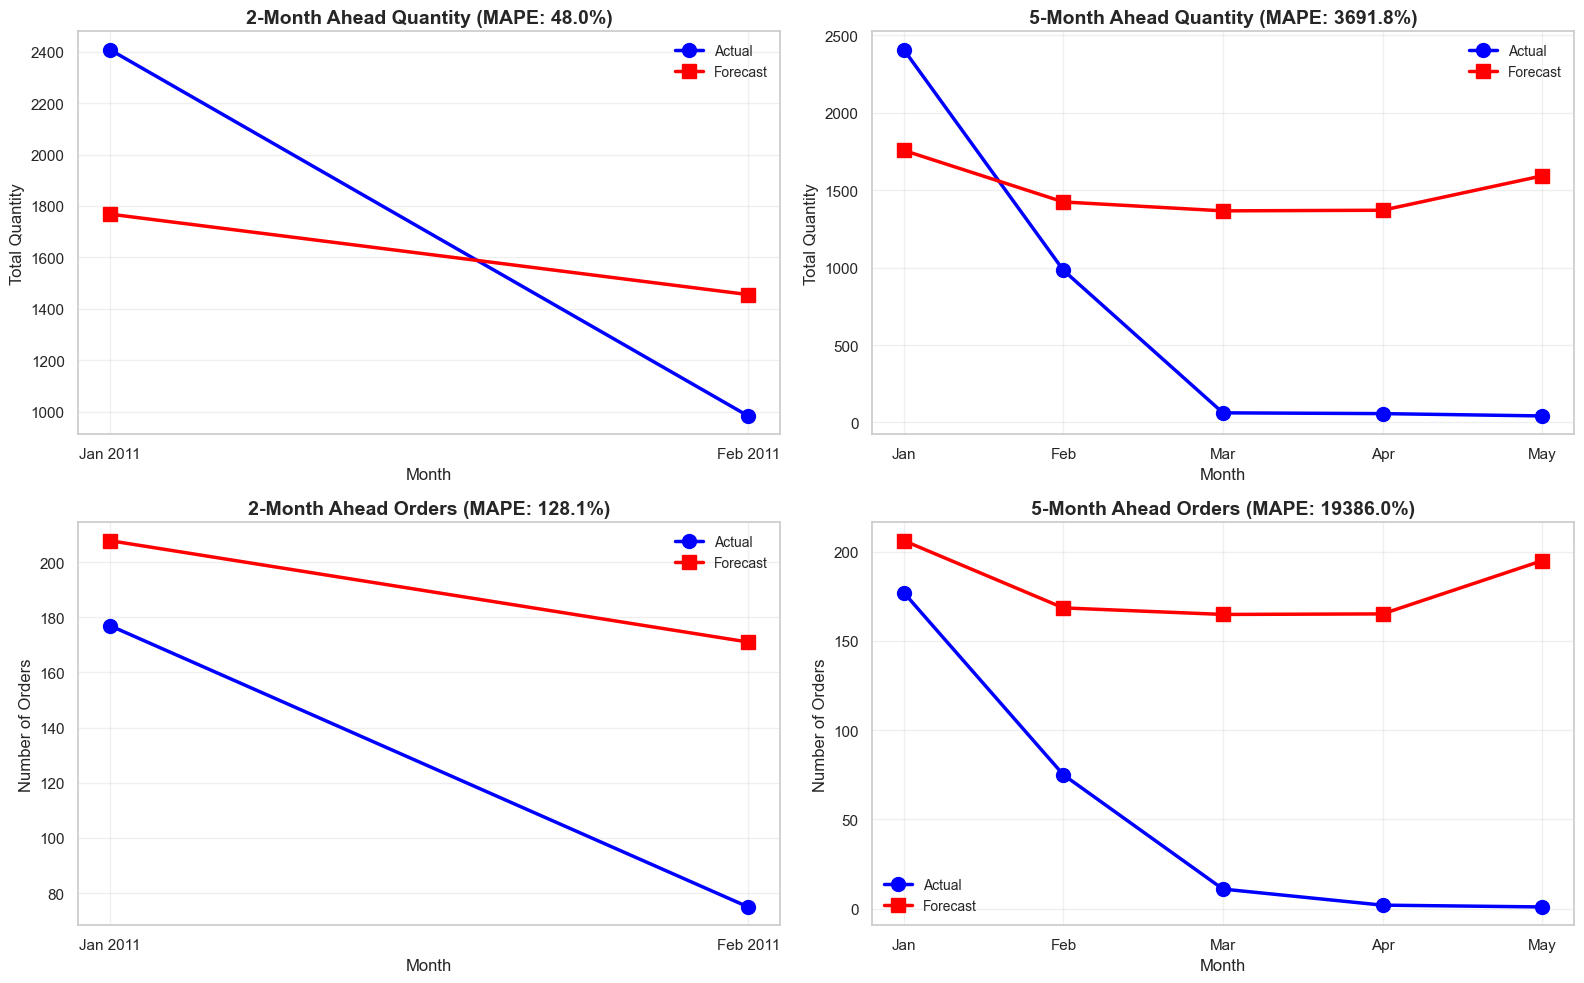

In [ ]:
# ================================================================
# VISUALIZATION FOR END MONTH FORECASTS
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# TOP LEFT: 2-Month Quantity Forecast
ax1 = axes[0, 0]
x = [1, 2]
ax1.plot(x, actual_2m_qty, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax1.plot(x, forecast_2m_qty, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax1.set_title(f"2-Month Ahead Quantity (MAPE: {mape_2m_qty:.1f}%)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Total Quantity", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x)
ax1.set_xticklabels(['Jan 2011', 'Feb 2011'])

# TOP RIGHT: 5-Month Quantity Forecast
ax2 = axes[0, 1]
x = [1, 2, 3, 4, 5]
ax2.plot(x, actual_5m_qty, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax2.plot(x, forecast_5m_qty, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax2.set_title(f"5-Month Ahead Quantity (MAPE: {mape_5m_qty:.1f}%)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Month", fontsize=12)
ax2.set_ylabel("Total Quantity", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(x)
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May'])

# BOTTOM LEFT: 2-Month Order Forecast
ax3 = axes[1, 0]
x = [1, 2]
ax3.plot(x, actual_2m_orders, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax3.plot(x, forecast_2m_orders, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax3.set_title(f"2-Month Ahead Orders (MAPE: {mape_2m_orders:.1f}%)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Month", fontsize=12)
ax3.set_ylabel("Number of Orders", fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(x)
ax3.set_xticklabels(['Jan 2011', 'Feb 2011'])

# BOTTOM RIGHT: 5-Month Order Forecast
ax4 = axes[1, 1]
x = [1, 2, 3, 4, 5]
ax4.plot(x, actual_5m_orders, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax4.plot(x, forecast_5m_orders, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax4.set_title(f"5-Month Ahead Orders (MAPE: {mape_5m_orders:.1f}%)", fontsize=14, fontweight='bold')
ax4.set_xlabel("Month", fontsize=12)
ax4.set_ylabel("Number of Orders", fontsize=12)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(x)
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May'])

plt.tight_layout()
plt.show()


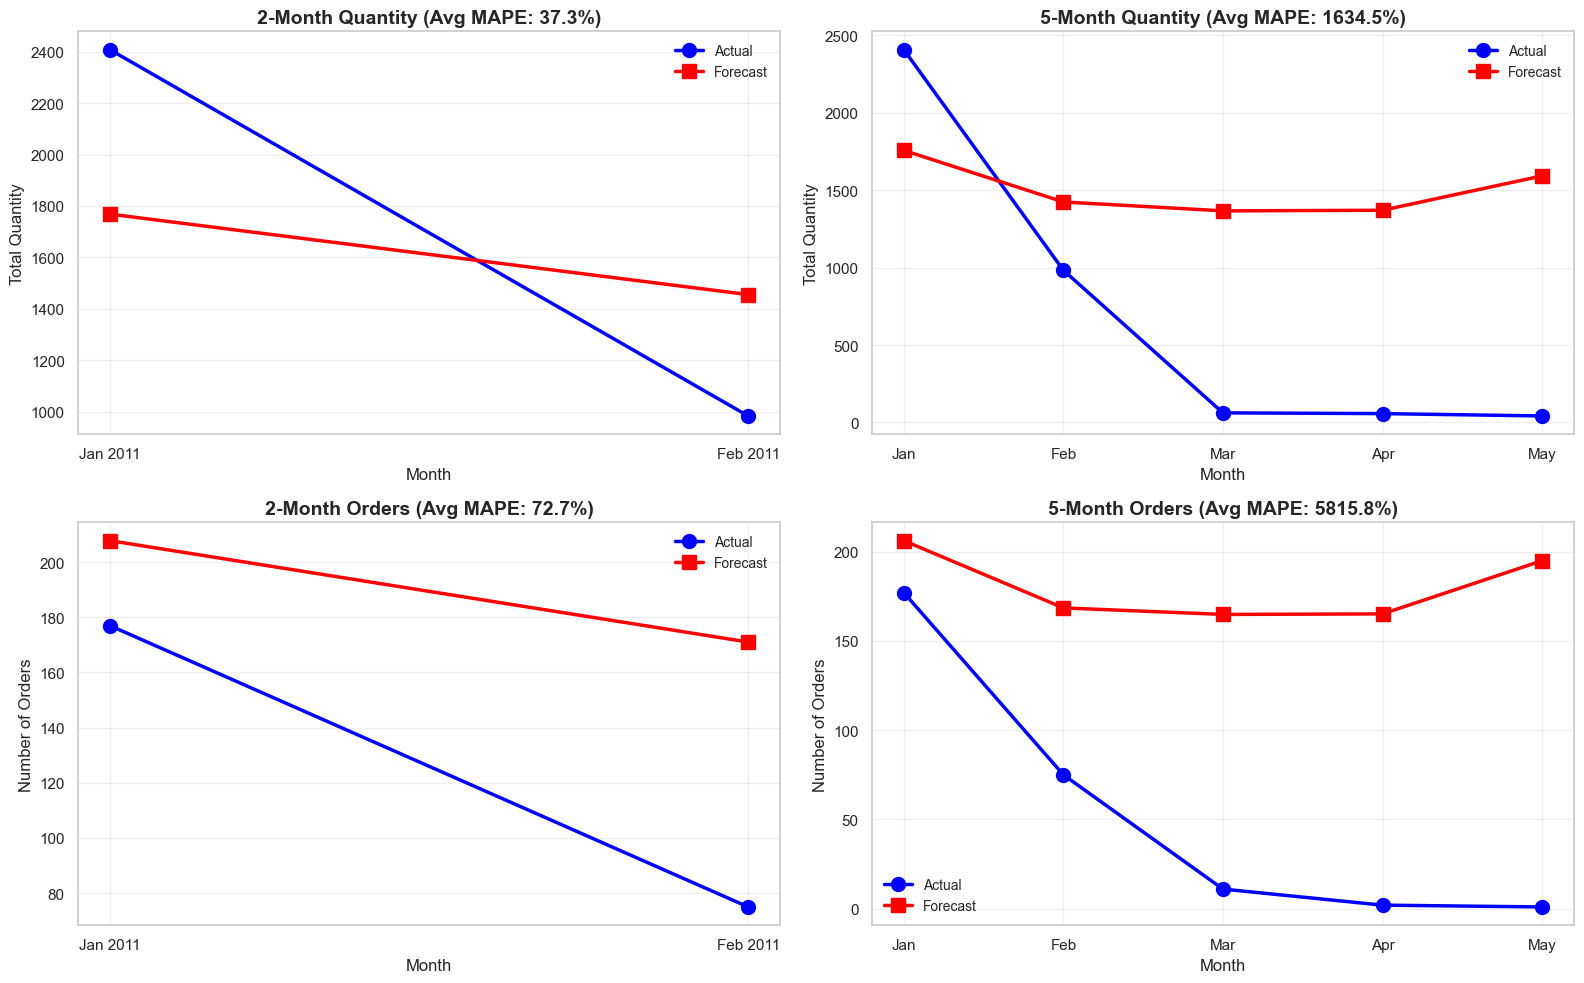

In [ ]:
# ================================================================
# VISUALIZATION FOR AVERAGE WINDOW MAPE
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# TOP LEFT: 2-Month Quantity Forecast (Average MAPE)
ax1 = axes[0, 0]
x = [1, 2]
ax1.plot(x, actual_2m_qty, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax1.plot(x, forecast_2m_qty, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax1.set_title(f"2-Month Quantity (Avg MAPE: {mape_avg_2m_qty:.1f}%)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Total Quantity", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x)
ax1.set_xticklabels(['Jan 2011', 'Feb 2011'])

# TOP RIGHT: 5-Month Quantity Forecast (Average MAPE)
ax2 = axes[0, 1]
x = [1, 2, 3, 4, 5]
ax2.plot(x, actual_5m_qty, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax2.plot(x, forecast_5m_qty, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax2.set_title(f"5-Month Quantity (Avg MAPE: {mape_avg_5m_qty:.1f}%)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Month", fontsize=12)
ax2.set_ylabel("Total Quantity", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(x)
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May'])

# BOTTOM LEFT: 2-Month Order Count Forecast (Average MAPE)
ax3 = axes[1, 0]
x = [1, 2]
ax3.plot(x, actual_2m_orders, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax3.plot(x, forecast_2m_orders, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax3.set_title(f"2-Month Orders (Avg MAPE: {mape_avg_2m_orders:.1f}%)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Month", fontsize=12)
ax3.set_ylabel("Number of Orders", fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(x)
ax3.set_xticklabels(['Jan 2011', 'Feb 2011'])

# BOTTOM RIGHT: 5-Month Order Count Forecast (Average MAPE)
ax4 = axes[1, 1]
x = [1, 2, 3, 4, 5]
ax4.plot(x, actual_5m_orders, marker='o', linewidth=2.5, markersize=10, label="Actual", color='blue')
ax4.plot(x, forecast_5m_orders, marker='s', linewidth=2.5, markersize=10, label="Forecast", color='red')
ax4.set_title(f"5-Month Orders (Avg MAPE: {mape_avg_5m_orders:.1f}%)", fontsize=14, fontweight='bold')
ax4.set_xlabel("Month", fontsize=12)
ax4.set_ylabel("Number of Orders", fontsize=12)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(x)
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May'])

plt.tight_layout()
plt.show()
